In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import rcParams
import matplotlib.ticker as mticker
import datetime

In [34]:
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'legend.title_fontsize': 13
})

In [35]:



# ▼ 初期化（上書き）
peak_info_list = []
scenarios_to_compare = [1, 2, 4, 5, 6]
folder_path = "EnergyManagement_Output_15"
data_path = "TEEA_EV15.csv"
df = pd.read_csv(data_path)



In [36]:


# ▼ すべての対象 name（除外済・重複なし）
target_names = df['name'].unique()

# ▼ すべての name についてピーク情報抽出のみ実行
for name in target_names:
    for scenario in scenarios_to_compare:
        file_path = os.path.join(folder_path, f"{name}_{scenario}.csv")
        if not os.path.exists(file_path):
            print(f"⚠️ ファイルなし: {file_path}")
            continue

        ts = pd.read_csv(file_path, index_col=0, parse_dates=True)
        ts.index = pd.to_datetime(ts.index, format='%Y-%m-%d %H:%M:%S', errors='raise')

        if ts.index.isnull().any():
            print(f"⚠️ {file_path} に日時変換できないインデックスがあります。除去します。")
            ts = ts[~ts.index.isnull()]

        ts['Total_Power'] = ts['Demand_Power'] - ts['RE_Power'] + ts['EV_Charge']
        top_peak = ts['Total_Power'].nlargest(1)

        if top_peak.empty:
            continue

        peak_time = top_peak.index[0]
        peak_value = top_peak.values[0]

        peak_info = {
            "name": name,
            "scenario": scenario,
            "peak_time": peak_time,
            "peak_power_kW": peak_value
        }
        peak_info_list.append(peak_info)

In [37]:
peak_df_ = pd.DataFrame(peak_info_list)

In [39]:
# df = pd.read_csv(data_path)
# df = df[
#    ~df['name'].isin(excluded_name)
# ]
# df = df[df["name"].isin(matching_peak_names)]
# df = df[df["DemandClass"] == 400]

In [40]:
df["DemandClass"]

0        600
1        600
2        600
3        600
4        600
        ... 
25063      0
25064      0
25065      0
25066      0
25067      0
Name: DemandClass, Length: 25032, dtype: int64

36
⚠️ PV容量が減少したケースはありません

🔍 SolarCapacity変化が最小の name: B11002784

🔺 Top 3 Peaks for B11002784 - Scenario 1
  1位 Peak @ 2014-08-20 14:00:00 → Total_Power: 237.00 kW | Demand: 237.00 kW | RE: 0.00 kW | EV: 0.00 kW
  2位 Peak @ 2014-08-20 15:00:00 → Total_Power: 236.00 kW | Demand: 236.00 kW | RE: 0.00 kW | EV: 0.00 kW
  3位 Peak @ 2014-08-21 15:00:00 → Total_Power: 234.00 kW | Demand: 234.00 kW | RE: 0.00 kW | EV: 0.00 kW

🔺 Top 3 Peaks for B11002784 - Scenario 2
  1位 Peak @ 2014-08-20 15:00:00 → Total_Power: 226.49 kW | Demand: 236.00 kW | RE: 9.51 kW | EV: 0.00 kW
  2位 Peak @ 2014-08-21 15:00:00 → Total_Power: 219.05 kW | Demand: 234.00 kW | RE: 14.95 kW | EV: 0.00 kW
  3位 Peak @ 2014-08-20 14:00:00 → Total_Power: 215.26 kW | Demand: 237.00 kW | RE: 21.74 kW | EV: 0.00 kW

🔺 Top 3 Peaks for B11002784 - Scenario 4
  1位 Peak @ 2014-08-20 15:00:00 → Total_Power: 232.05 kW | Demand: 236.00 kW | RE: 9.51 kW | EV: 5.56 kW
  2位 Peak @ 2014-08-21 15:00:00 → Total_Power: 222.37 kW | Demand: 234.00

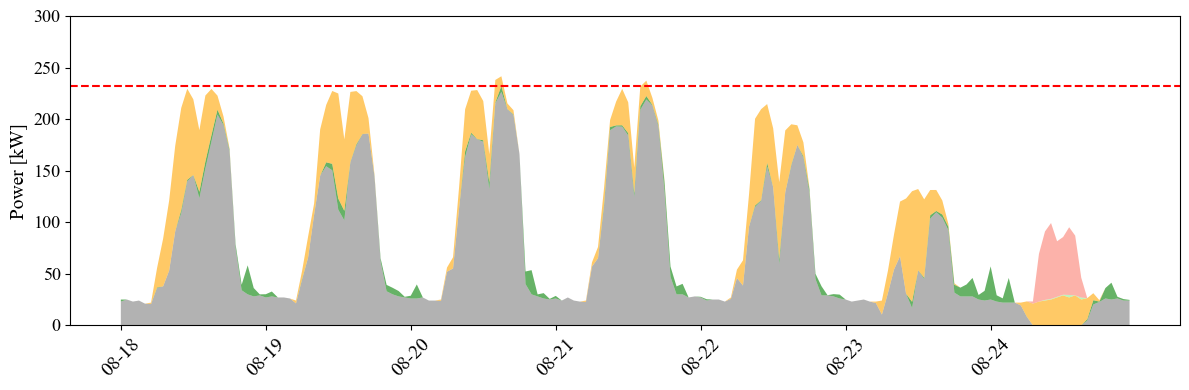

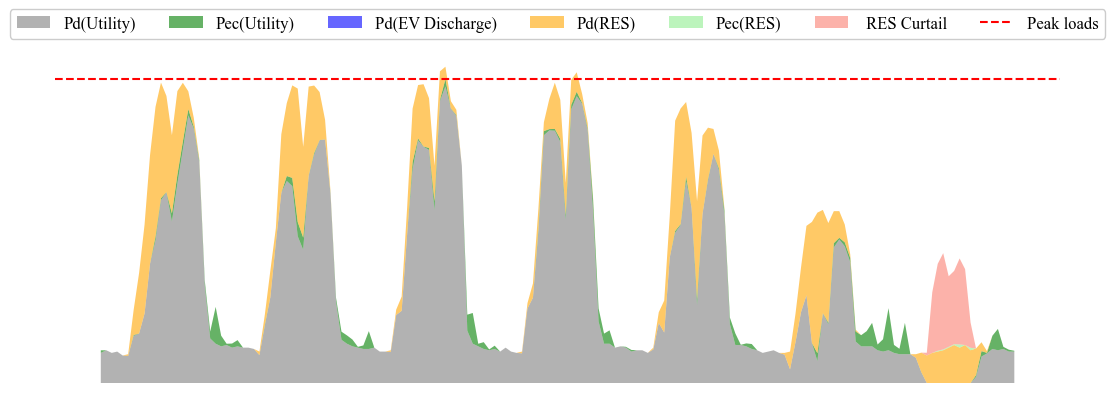

5 3520.3804250609123


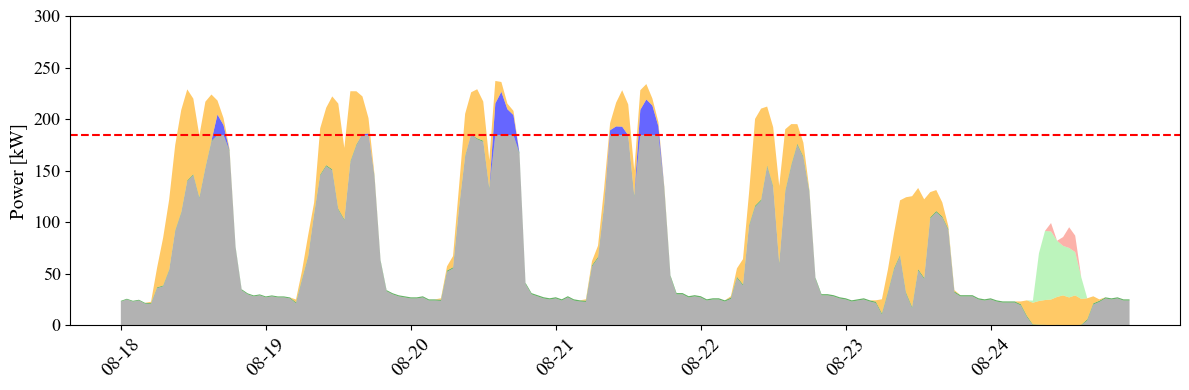

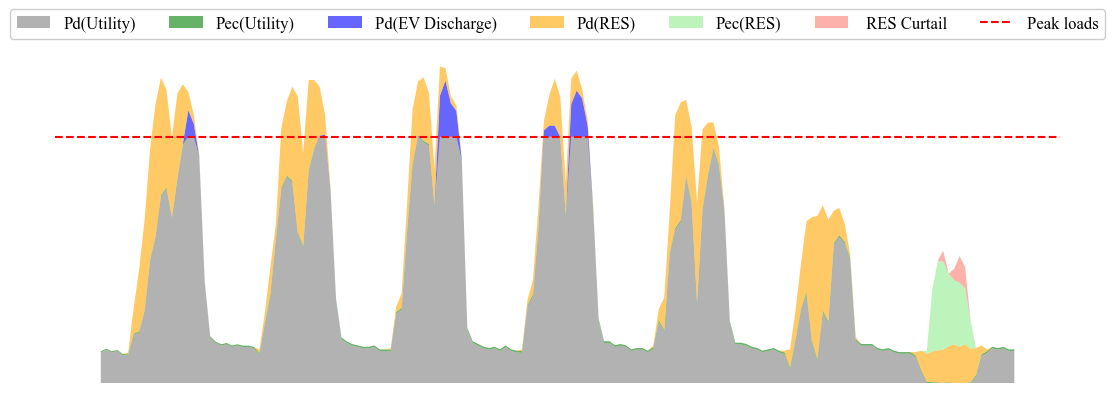

6 5346.5079359910005


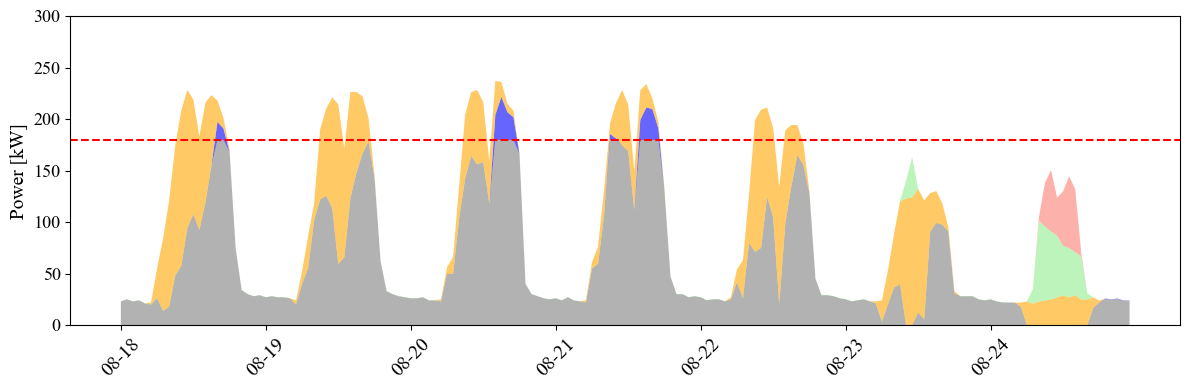

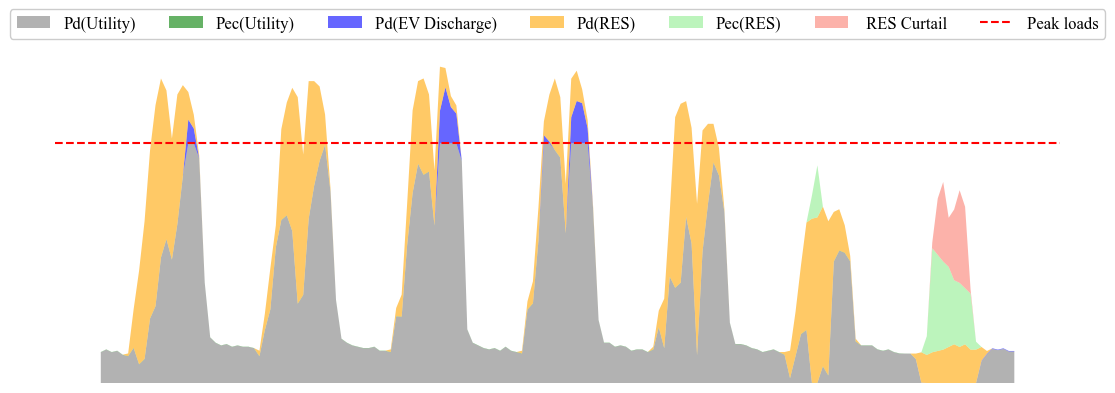

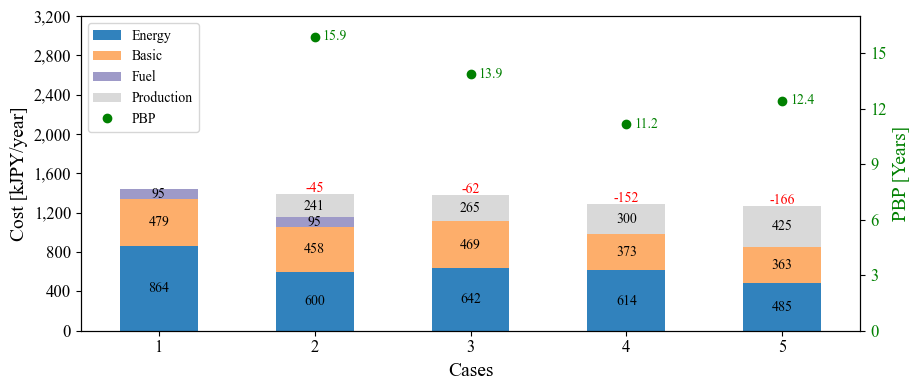

IMG/B11002784_GHG_CPBP.png


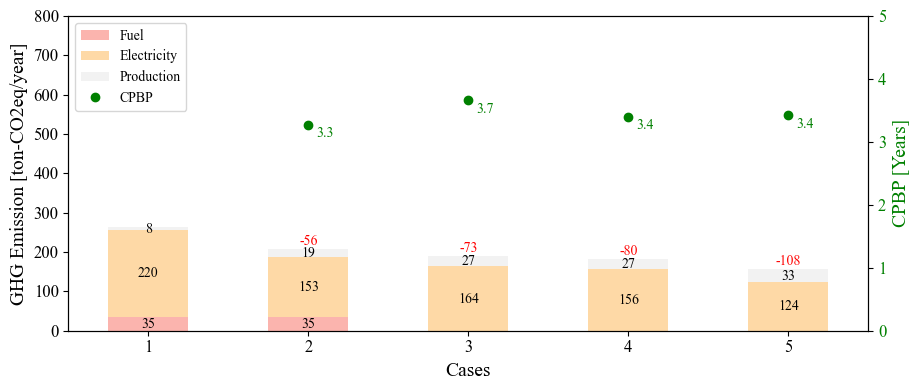

C:\Users\kiuch\AppData\Local\Temp\ipykernel_26552\3374870920.py:372: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  daily_avg = ts.resample('H').mean()


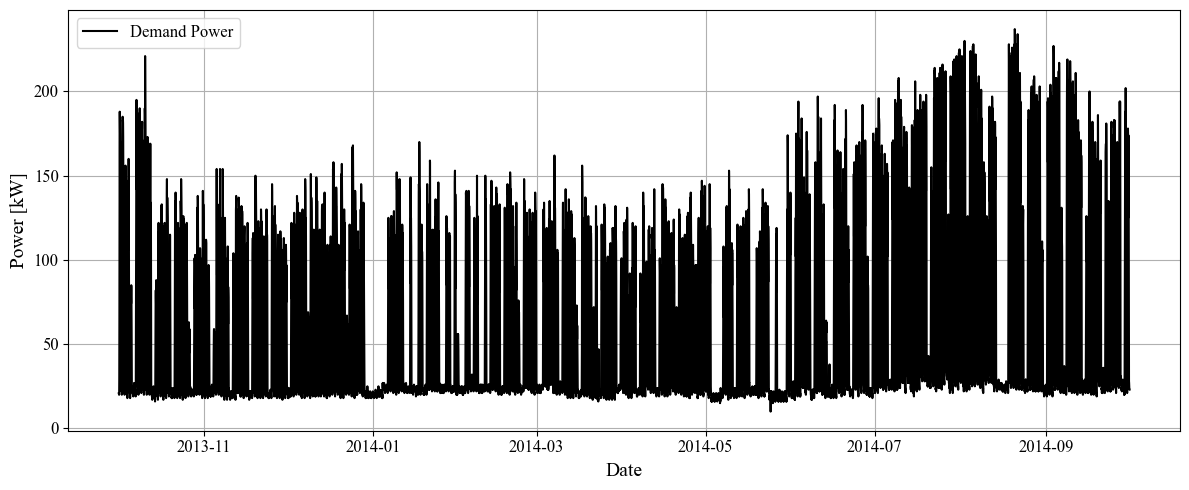

IMG/B11002784_3_typical_week_demand.png


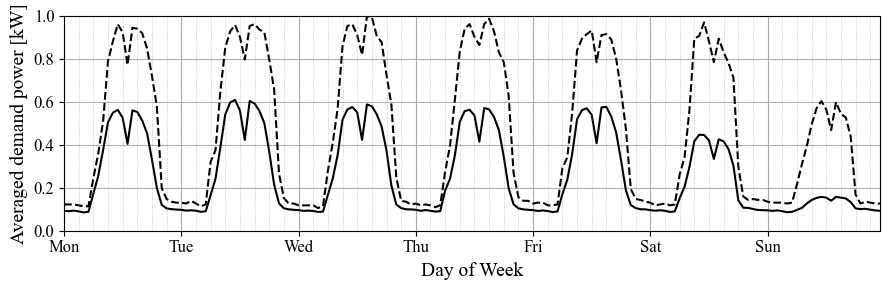

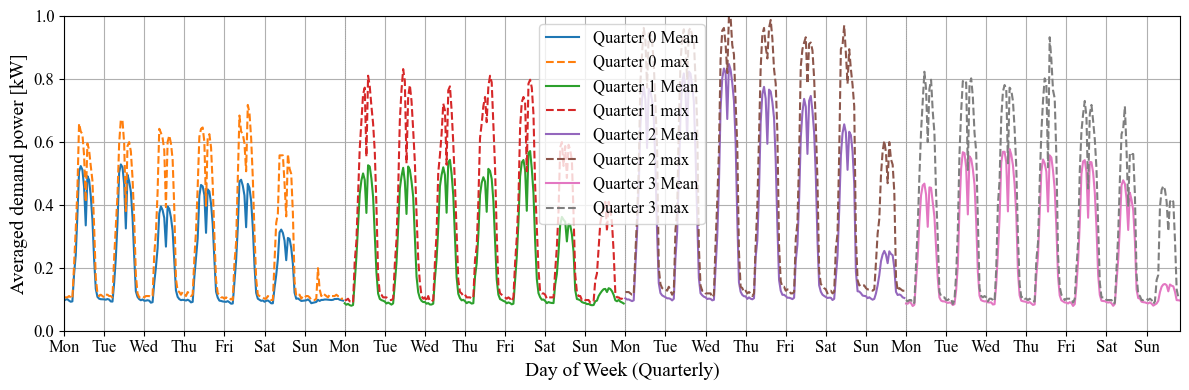

   AnnualCost    PBP  TotalGHG  CPBP  SolarCapacity  EnergyCost  ContractCost  \
1     1438.05   0.00    255.87  0.00           0.00      864.49        478.93   
2     1393.08  15.88    188.32  3.27         135.87      599.59        457.69   
4     1375.97  13.86    163.68  3.66         135.87      641.88        468.92   
5     1285.99  11.15    156.44  3.40         135.87      613.50        372.82   
6     1272.35  12.43    123.61  3.42         206.35      484.73        362.85   

    SSR   SCR  Cost_trvl  Prod_cost  OM_cost  Annual_Prod_cost  GHG_trvl  \
1  0.00  0.00      94.63       0.00     0.00              0.00  35424.54   
2  0.31  0.88      94.63    3464.67    67.93            241.17  35424.54   
4  0.29  0.88       0.00    3689.67    69.43            265.17      0.00   
5  0.33  0.98       0.00    3959.67    76.93            299.67      0.00   
6  0.47  0.94       0.00    5756.90   112.17            424.77      0.00   

   GHG_Comsumption  GHG_Annual_Production  GHG_prod_ev  

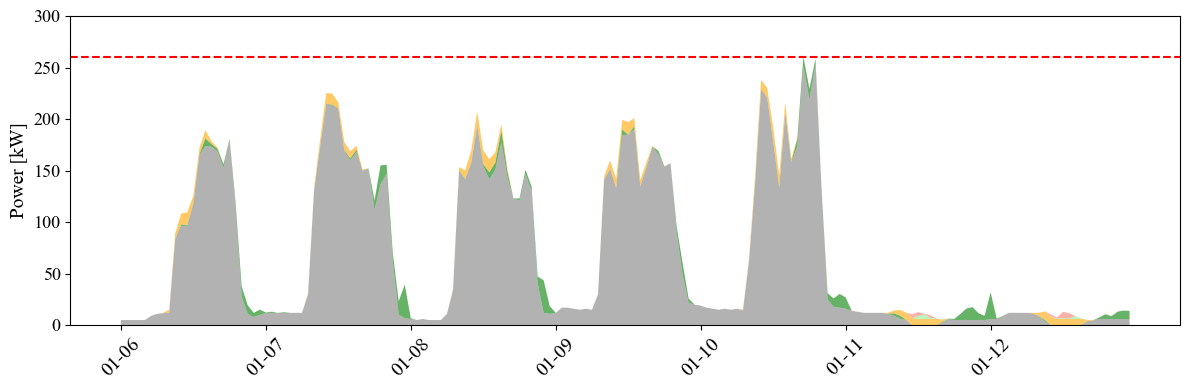

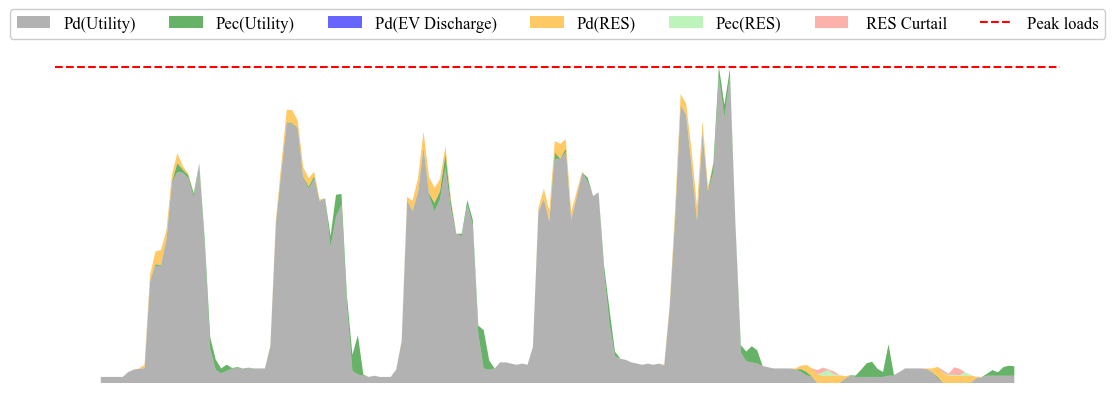

5 466.58181886004485


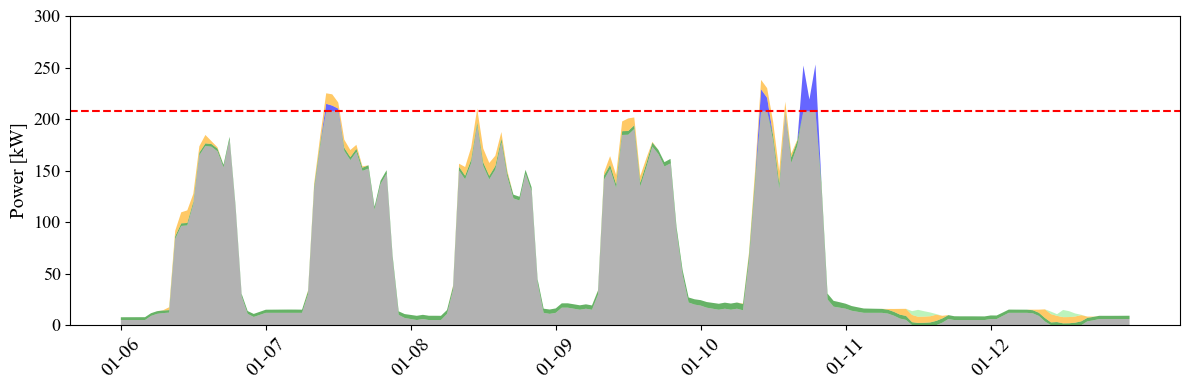

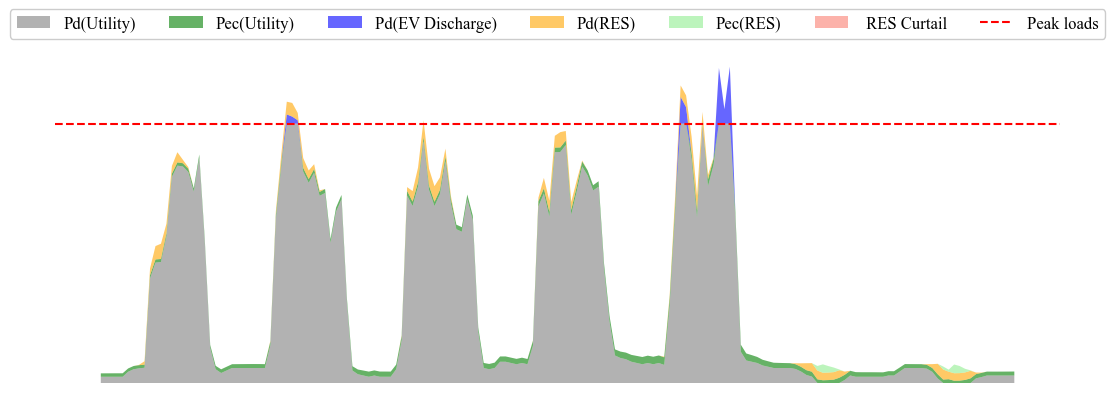

6 2457.8863734569236


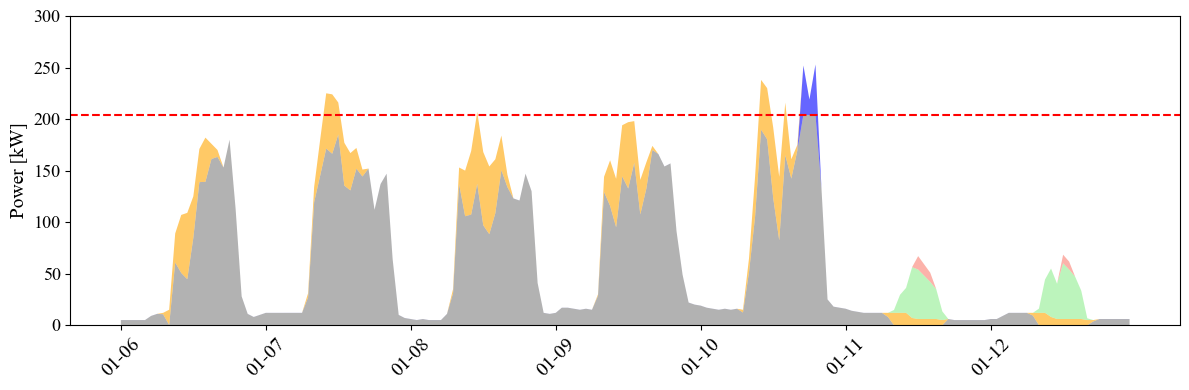

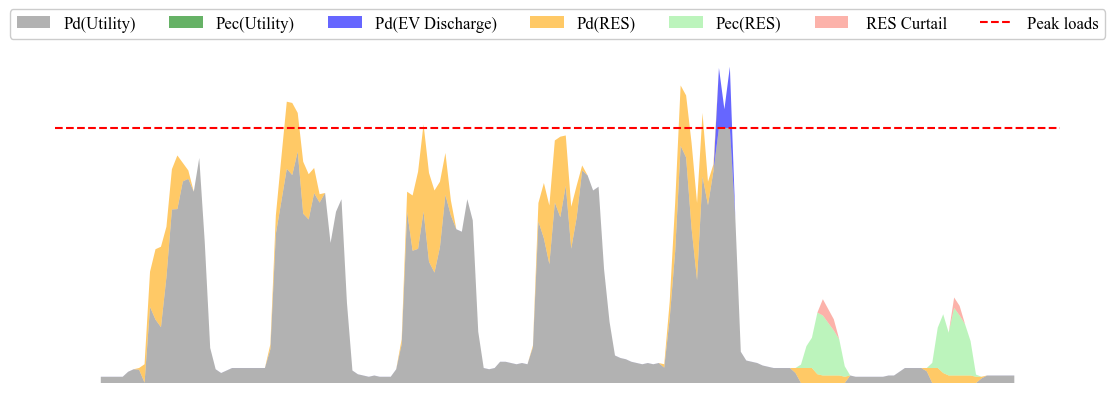

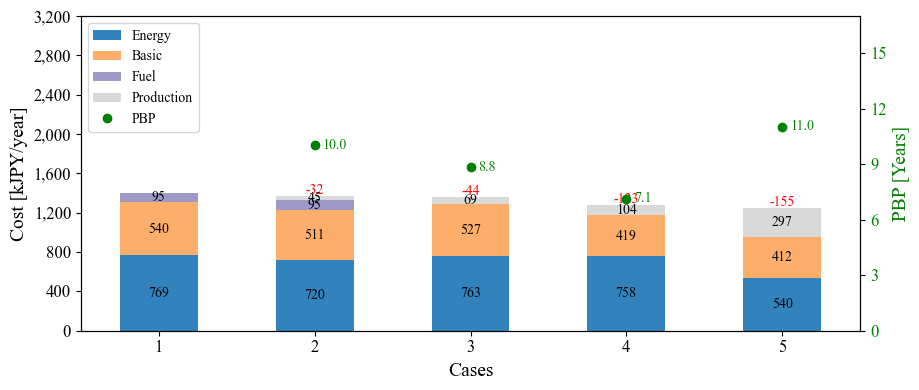

IMG/B11005002_GHG_CPBP.png


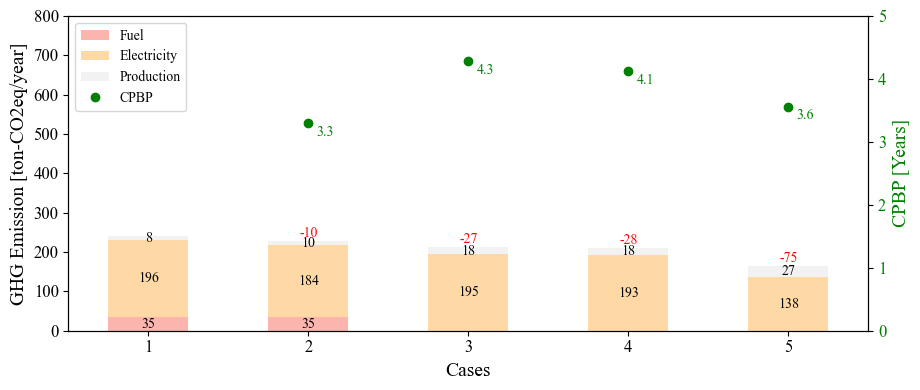

C:\Users\kiuch\AppData\Local\Temp\ipykernel_26552\3374870920.py:372: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  daily_avg = ts.resample('H').mean()


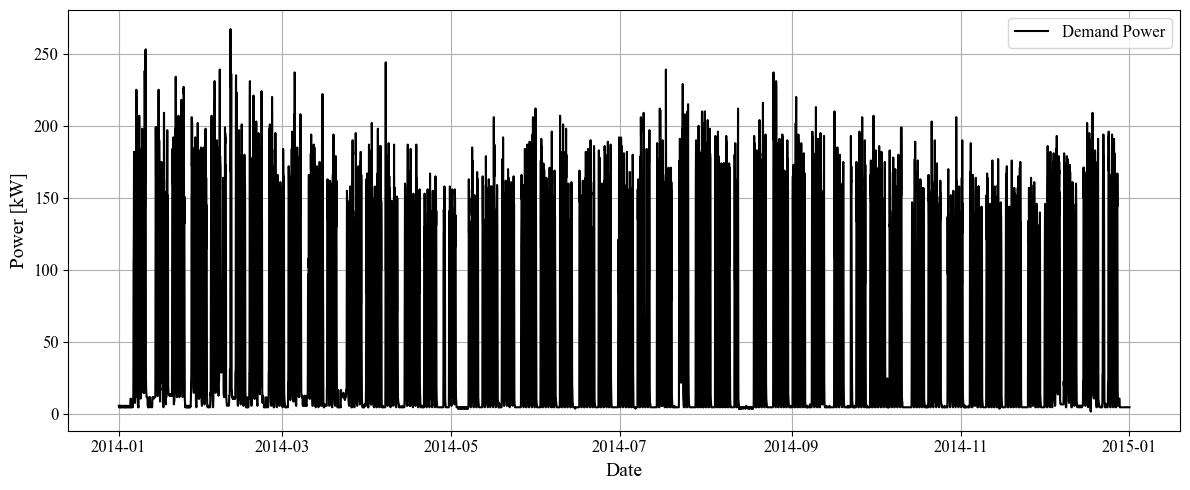

IMG/B11005002_3_typical_week_demand.png


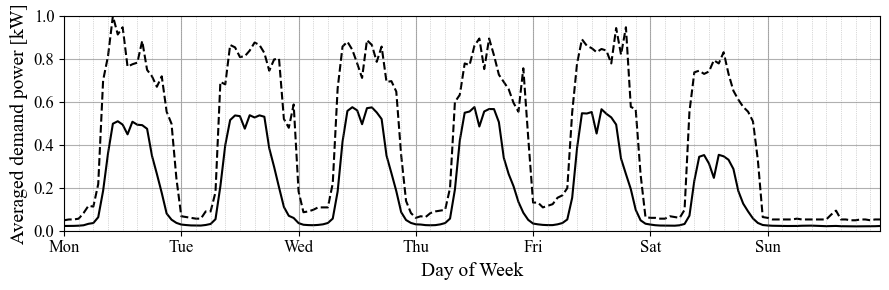

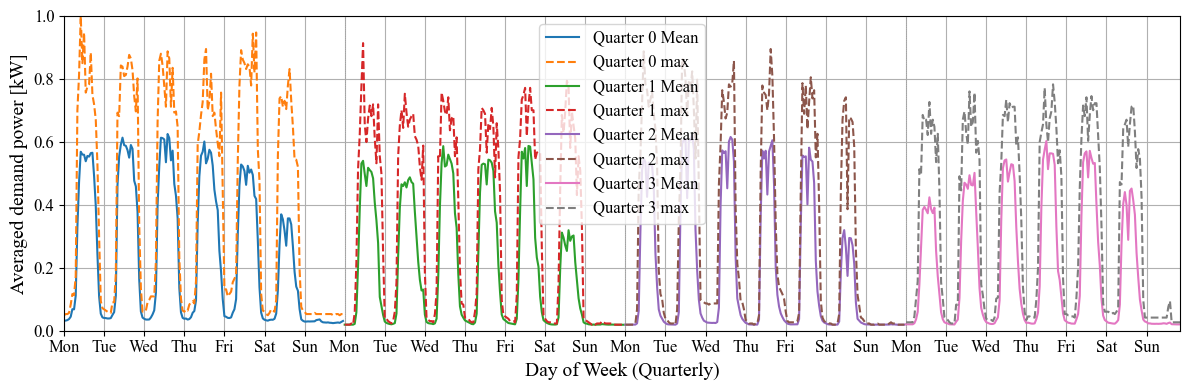

   AnnualCost    PBP  TotalGHG  CPBP  SolarCapacity  EnergyCost  ContractCost  \
1     1403.63   0.00    231.63  0.00           0.00      769.44        539.55   
2     1371.32  10.02    219.09  3.30          25.45      720.24        511.26   
4     1359.14   8.85    194.65  4.28          25.45      763.33        526.63   
5     1280.58   7.14    193.22  4.12          25.45      757.71        419.19   
6     1248.64  11.02    137.67  3.56         134.09      539.89        412.24   

    SSR   SCR  Cost_trvl  Prod_cost  OM_cost  Annual_Prod_cost  GHG_trvl  \
1  0.00  0.00      94.63       0.00     0.00              0.00  35424.54   
2  0.06  0.87      94.63     649.09    12.73             45.18  35424.54   
4  0.06  0.90       0.00     874.09    14.23             69.18      0.00   
5  0.07  1.00       0.00    1144.09    21.73            103.68      0.00   
6  0.34  0.94       0.00    3914.32    76.05            296.51      0.00   

   GHG_Comsumption  GHG_Annual_Production  GHG_prod_ev  

In [41]:




# ▼ 設定
data_path = "TEEA_EV15.csv"
folder_path = "EnergyManagement_Output_15"
scenarios_to_compare = [1, 2, 4, 5, 6]
cost_columns = ['EnergyCost', 'ContractCost', 'Cost_trvl', 'Annual_Prod_cost']
GHG_columns = ["GHG_trvl","GHG_Comsumption","GHG_Annual_Production"]
peak_info_list = []
# ▼ 除外対象の name
# excluded_name = ["B11001679","B11004418","B11002265","B11004367","B11004358","B11005314","B11004359",
#                  "B11002553","B11001292","B11005277","B11002461","B11005275","B11005269","B11005064",
#                  "B11000702","B11001296","B11001891","B11006131","B11005283","B11005279","B11005272",
#                  "B11001112","B11005002","B11001304","B11001364","B11002214","B11001587","B11003795",
#                  "B11001444","B11004731","B11002731","B11004245","B11000374","B11001569","B11003499",
#                  "B11005226","B11002460","B11001875","B11001872","B11002456","B11001156","B11006117",
#                  "B11005493","B11001876","B11002464","B11000021","B11005012","B11004544","B11001118",
#                  "B11000575","B11006387","B11001493","B11001525","B11001487","B11001053","B11000602",
#                  "B11005305","B11000230","B11005403","B11005472","B11005409","B11005491","B11000601"]

excluded_name = ["B11005403","B11005493","B11005472","B11006117","B11003964","B11005064","B11004367",
                 "B11005045","B11002460","B11002456","B11002731","B11003442","B11001549","B11002591",
                 "B11001898","B11001746","B11000716","B11005988","B11002642","B11004608","B11003707"]
excluded_name = ["B11002642","B11004608","B11003707","B11005064","B11005472","B11005045"]
#B11002460
#B11001898
#B11005279


# ▼ データ読み込み
df = pd.read_csv(data_path)
print(sum(df['name'].isin(excluded_name)))
df = df[
   ~df['name'].isin(excluded_name)
]
df['CPBP_months'] = df['CPBP'] * 12


# =========================
# 関数定義
# =========================

def get_name_metrics(name):
    """指定された name の各シナリオにおける指標値を取得"""
    metrics = {
        s: df[(df['Scinario'] == s) & (df['name'] == name)].iloc[0][[
            'AnnualCost', 'PBP', 'GHG_Total', 'CPBP', 'SolarCapacity',
            'EnergyCost', 'ContractCost', 'SSR[-]', 'SCR[-]', 
            'Cost_trvl', 'Prod_cost', 'OM_cost', 'Annual_Prod_cost',"GHG_trvl","GHG_Comsumption","GHG_Annual_Production","GHG_prod_ev"
        ]] for s in scenarios_to_compare
    }
    df_metrics = pd.DataFrame(metrics).T.rename(columns={
        'GHG_Total': 'TotalGHG',
        'SSR[-]': 'SSR',
        'SCR[-]': 'SCR'
    })
    return df_metrics.apply(pd.to_numeric, errors='coerce').round(2)

def process_name(name):
    """全シナリオでピーク検出、シナリオ6から週データ抽出、シナリオ4と6でグラフ化"""
    graph_scenarios = [4, 5, 6]
    scenario_data = {}  # 各シナリオの時系列データ保存
    peak_info_dict = {}  # 各シナリオの最上位ピーク情報
    peak_week_data = None
    peak_time_scenario6 = None
    demand_peak_scenario6 = None

    # --- 第1パス：全シナリオでピーク抽出 ---
    for scenario in scenarios_to_compare:
        file_path = os.path.join(folder_path, f"{name}_{scenario}.csv")
        if not os.path.exists(file_path):
            print(f"⚠️ ファイルなし: {file_path}")
            continue

        ts = pd.read_csv(file_path, index_col=0, parse_dates=True)
        ts.index = pd.to_datetime(ts.index, format='%Y-%m-%d %H:%M:%S', errors='raise')

        if ts.index.isnull().any():
            print(f"⚠️ {file_path} に日時変換できないインデックスがあります。除去します。")
            ts = ts[~ts.index.isnull()]

        ts['Total_Power'] = ts['Demand_Power'] - ts['RE_Power'] + ts['EV_Charge']
        scenario_data[scenario] = ts  # 保存しておく

        top_peaks = ts['Total_Power'].nlargest(3)

        print(f"\n🔺 Top 3 Peaks for {name} - Scenario {scenario}")
        for i, (peak_time, peak_value) in enumerate(top_peaks.items(), 1):
            peak_row = ts.loc[peak_time]
            print(f"  {i}位 Peak @ {peak_time} → Total_Power: {peak_value:.2f} kW | "
                  f"Demand: {peak_row['Demand_Power']:.2f} kW | "
                  f"RE: {peak_row['RE_Power']:.2f} kW | "
                  f"EV: {peak_row['EV_Charge']:.2f} kW")

            if i == 1:
                # 最上位ピークのみ保存
                peak_info = {
                    "name": name,
                    "scenario": scenario,
                    "peak_time": peak_time,
                    "peak_power_kW": peak_value
                }
                peak_info_list.append(peak_info)
                peak_info_dict[scenario] = peak_info

                # シナリオ6なら週データも保存
                if scenario == 6:
                    peak_time_scenario6 = peak_time
                    demand_peak_scenario6 = peak_row['Demand_Power']
                    week_start = peak_time - pd.Timedelta(
                        days=peak_time.weekday(),
                        hours=peak_time.hour,
                        minutes=peak_time.minute,
                        seconds=peak_time.second
                    )
                    #week_start = datetime.datetime(peak_time.year,4,1,0,0,0)
                    week_end = week_start + pd.Timedelta(weeks=1)

                    peak_week_data = ts[(ts.index >= week_start) & (ts.index < week_end)]
                if scenario == 4:
                    peak_time_scenario4 = peak_time
                    demand_peak_scenario4 = peak_row['Demand_Power']

    # --- 第2パス：グラフ化（4と6のみ、ピーク週は6から） ---
    if peak_week_data is None:
        print("⚠️ シナリオ6のピーク週データが見つかりません。グラフ化をスキップします。")
        return

    for scenario in graph_scenarios:
        if scenario not in scenario_data:
            continue  # データなければスキップ

        ts = scenario_data[scenario]
        peak_week_data = ts[(ts.index >= week_start) & (ts.index < week_end)].copy()
        peak_week_data.loc[:, 'EV_Discharge'] = peak_week_data['EV_Charge'].apply(lambda x: -x if x < 0 else 0)
        peak_week_data.loc[:, 'EV_Charge_Positive'] = peak_week_data['EV_Charge'].apply(lambda x: x if x > 0 else 0)
        peak_week_data.loc[:, 'Demand_from_RES'] = peak_week_data.apply(lambda row: min(row['Demand_Power'], row['RE_Power']), axis=1)
        peak_week_data.loc[:, 'Demand_from_EV_Discharge'] = peak_week_data.apply(lambda row: min(row['Demand_Power'] - row['Demand_from_RES'], row['EV_Discharge']), axis=1)
        peak_week_data.loc[:, 'Demand_from_Utility'] = peak_week_data['Demand_Power'] - peak_week_data['Demand_from_RES'] - peak_week_data['Demand_from_EV_Discharge']
        peak_week_data.loc[:, 'EV_Charge_from_RES'] = peak_week_data.apply(lambda row: min(row['RE_Power'] - row['Demand_from_RES'], row['EV_Charge_Positive']), axis=1)
        peak_week_data.loc[:, 'EV_Charge_from_Utility'] = peak_week_data['EV_Charge_Positive'] - peak_week_data['EV_Charge_from_RES']
        peak_week_data.loc[:, 'RE_Curtail'] = peak_week_data['RE_Power'] - peak_week_data['Demand_from_RES']-peak_week_data['EV_Charge_from_RES']

        # print("EV_Discharge:\n", peak_week_data['EV_Discharge'].head())  # EV_Discharge の最初の5行
        # print("Demand_Power:\n", peak_week_data['Demand_Power'].head())  # Demand_Power の最初の5行
        # print("RE_Power:\n", peak_week_data['RE_Power'].head())  # Demand_Power の最初の5行

        # print("Demand_from_RES:\n", peak_week_data['Demand_from_RES'].head(), "\n")
        # print("Demand_from_EV_Discharge:\n", peak_week_data['Demand_from_EV_Discharge'].head(), "\n")
        # print("Demand_from_Utility:\n", peak_week_data['Demand_from_Utility'].head(), "\n")
        # print("EV_Charge_from_RES:\n", peak_week_data['EV_Charge_from_RES'].head(), "\n")
        # print("EV_Charge_from_Utility:\n", peak_week_data['EV_Charge_from_Utility'].head(), "\n")

        #print(peak_week_data.loc[peak_week_data.index>=datetime.datetime(2014,1,13,18),["net_demand","EV_Charge_Positive","EV_Discharge","RE_Power","Demand_Power"]])
        fig, ax1 = plt.subplots(figsize=(12, 4))

        print(scenario,peak_week_data['RE_Power'].sum())
        # EV Charge, RES Power, EV Dischargeの積み上げグラフ
        ax1.stackplot(peak_week_data.index, 
                    peak_week_data['Demand_from_Utility'],
                    peak_week_data['EV_Charge_from_Utility'],
                    peak_week_data['Demand_from_EV_Discharge'], 
                    peak_week_data['Demand_from_RES'],
                    peak_week_data['EV_Charge_from_RES'],
                    peak_week_data[ 'RE_Curtail'],
                    
                    labels=['Demand(Utility)','EV Charge(Utility)','Demand(EV Discharge)', 'Demand(RES)','EV Charge(RES)',' RES Curtail',], 
                    colors=['gray', 'green','blue', 'orange','lightgreen','salmon'], 
                    alpha=0.6)

        ax1.axhline(peak_info_dict[scenario]["peak_power_kW"], color='red', linestyle='--', label='Peak Power')
        
        # 文字サイズの調整
        #ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=7, frameon=True, facecolor='white', framealpha=1, fontsize=12)
        ax1.set_ylabel("Power [kW]", fontsize=14)
        #ax1.set_xlabel("Time", fontsize=14)
        
        # X軸、Y軸の目盛りサイズの変更
        ax1.tick_params(axis='both', labelsize=13)
        xticks = peak_week_data.index[::24]  # 1日ごとのデータを取得（24時間毎）
        xticklabels = [dt.strftime('%m-%d') for dt in xticks]

        ax1.set_xticks(xticks)  # X軸の目盛り位置
        ax1.set_xticklabels(xticklabels, rotation=45, fontsize=14)  # 月日形式のラベル、回転角度とフォントサイズの調整

    #
        
        
        
        ax1.set_ylim(0, round(demand_peak_scenario4 * 1.2, -2))
        plt.xticks(rotation=45)
        plt.tight_layout()

        # グラフの保存
        plt.savefig(f"IMG/{name}-{scenario}.png")
        plt.show()

        fig, ax1 = plt.subplots(figsize=(12, 4))

        # データと積み上げグラフ（最小限のプロット）
        ax1.stackplot(peak_week_data.index, 
                    peak_week_data['Demand_from_Utility'],
                    peak_week_data['EV_Charge_from_Utility'],
                    peak_week_data['Demand_from_EV_Discharge'], 
                    peak_week_data['Demand_from_RES'],
                    peak_week_data['EV_Charge_from_RES'],
                    peak_week_data[ 'RE_Curtail'],
                    
                    labels=['Pd(Utility)','Pec(Utility)','Pd(EV Discharge)', 'Pd(RES)','Pec(RES)',' RES Curtail',], 
                    colors=['gray', 'green','blue', 'orange','lightgreen','salmon'], 
                    alpha=0.6)
        ax1.axhline(peak_info_dict[scenario]["peak_power_kW"], color='red', linestyle='--', label='Peak loads')
        # 凡例の設定
        ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=7, frameon=True, facecolor='white', framealpha=1, fontsize=12)
        
        # 軸は不要なので非表示にする
        ax1.set_axis_off()

        # 画像として保存
        plt.tight_layout()
        plt.savefig(f"IMG/legend.png", bbox_inches='tight')
        plt.show()


def plot_cost_and_pbp(name,df_metrics, title=""):
    """積み上げコスト棒グラフ + PBPの2軸プロット"""
    df = df_metrics.reset_index(drop=True)
    
    df['PBP'] = df['PBP'].replace(0, np.nan)
    df['TotalCost'] = df[cost_columns].sum(axis=1)
    base_cost = df.loc[0, 'TotalCost']
    new_labels = ['Energy', 'Basic', 'Fuel', 'Production']

    fig, ax1 = plt.subplots(figsize=(9.3, 4))
    df[cost_columns].plot(kind='bar', stacked=True, ax=ax1, colormap='tab20c')
    ax1.set_xticklabels(range(1,6), rotation=0)
    #ax1.set_ylim(0, round(base_cost*2,-2))
    ax1.set_ylim(0, 3200)
    
    ax1.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
    ax1.set_yticks(range(0,3300,400))
    ax1.set_ylabel('Cost [kJPY/year]')
    ax1.set_xlabel('Cases')

    for i in range(len(df)):
        bottom = 0
        for col in cost_columns:
            height = df.loc[i, col]
            if height > 0:
                ax1.text(i, bottom + height / 2, f"{height:.0f}", ha='center', va='center', fontsize=10)
                bottom += height

    for i, total in enumerate(df['TotalCost']):
        if i<1:continue
        diff = total - base_cost
        sign = "+" if diff > 0 else ""
        ax1.text(i, total + 20, f"{sign}{diff:.0f}", color="red",ha='center', fontsize=10)

    ax2 = ax1.twinx()
    ax2.plot(df.index, df['PBP'], color='green', marker='o', linestyle='', label='PBP')
    ax2.set_ylim(0, 17)
    ax2.set_yticks(range(0,17,3))  # 7日 * 4四半期
    ax2.set_ylabel('PBP [Years]', color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    for i, val in enumerate(df['PBP']):
        if not np.isnan(val):
            ax2.text(i + 0.05, val-0.2, f"{val:.1f}", ha='left', color='green', fontsize=10)

    # 凡例統合
    handles, labels = [], []
    for ax in [ax1, ax2]:
        h, l = ax.get_legend_handles_labels()
        handles += h
        labels += l

    # cost_columns に新しいラベルを設定
    cost_labels = new_labels
    
    # 新しいラベルを使って凡例を設定
    ax1.legend(handles, new_labels + ['PBP'], loc='upper left', fontsize=10)
    #ax1.set_title(title)
    plt.tight_layout()
    plt.savefig(f"IMG/{name}_TAC_PBP.png", bbox_inches='tight')

    plt.show()

def plot_ghg_and_cpBP(name,df_metrics, title=""):
    """GHG積み上げ + CPBP折れ線グラフ（月単位表示）"""
    df = df_metrics.reset_index(drop=True).copy()
    
    # AGHG単位調整：kg → t
    for col in GHG_columns:
        df[col] = df[col] / 1000  # kg → tCO2e 換算

    df['CPBP'] = df['CPBP'].replace(0, np.nan)  # ゼロは非表示に
    df['CPBP_months'] = df['CPBP'] * 12         # 年 → 月に変換

    df['TotalGHG'] = df[GHG_columns].sum(axis=1)
    base_ghg = df.loc[0, 'TotalGHG']

    new_labels = ['Fuel', 'Electricity', 'Production']

    fig, ax1 = plt.subplots(figsize=(9.3, 4))

    # GHG 積み上げ棒グラフ
    df[GHG_columns].plot(kind='bar', stacked=True, ax=ax1, colormap='Pastel1')
    ax1.set_xticklabels(range(1,6),rotation=0)

    #ax1.set_ylim(0, round(base_ghg * 1.7, -2))
    ax1.set_ylim(0, 800)
    ax1.set_ylabel('GHG Emission [ton-CO2eq/year]')
    ax1.set_xlabel('Cases')

    # ▼ 各要素に数値表示（棒の中）
    for i in range(len(df)):
        bottom = 0
        for col in GHG_columns:
            height = df.loc[i, col]
            if height > 0:
                ax1.text(i, bottom + height / 2, f"{height:.0f}", ha='center', va='center', fontsize=10)
                bottom += height

    # ▼ ベースケースとの差（赤字）
    for i, total in enumerate(df['TotalGHG']):
        if i == 0:
            continue
        diff = total - base_ghg
        sign = "+" if diff > 0 else ""
        ax1.text(i, total + 10, f"{sign}{diff:.0f}", color="red", ha='center', fontsize=10)

    # CPBP 折れ線（月単位）
    ax2 = ax1.twinx()
    ax2.plot(df.index, df['CPBP'], color='green', marker='o', linestyle='', label='CPBP (years)')
    ax2.set_ylim(0, 5)
    ax2.set_ylabel('CPBP [Years]', color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    # CPBP 数値（点の上に表示）
    for i, val in enumerate(df['CPBP']):
        if not np.isnan(val):
            ax2.text(i + 0.05, val-0.2, f"{val:.1f}", ha='left', color='green', fontsize=10)

    # 凡例とタイトル
    handles, labels = [], []
    for ax in [ax1, ax2]:
        h, l = ax.get_legend_handles_labels()
        handles += h
        labels += l
    ax1.legend(handles, new_labels + ['CPBP'], loc='upper left', fontsize=10)
    #ax1.set_title(title + " - GHG and CPBP (months)")

    plt.tight_layout()
    print(f"IMG/{name}_GHG_CPBP.png")
    
    plt.savefig(f"IMG/{name}_GHG_CPBP.png", bbox_inches='tight')
    plt.show()

def plot_annual_demand_re(name, scenario):
    """年間のDemand_PowerとRE_Powerのプロファイルをプロット"""
    file_path = os.path.join(folder_path, f"{name}_{scenario}.csv")
    if not os.path.exists(file_path):
        print(f"⚠️ {file_path} が見つかりません。")
        return

    # ▼ データ読み込み
    ts = pd.read_csv(file_path, index_col=0, parse_dates=True)

    # ここで必ず日時型に変換する（念のため）
    ts.index = pd.to_datetime(ts.index, format='%Y-%m-%d %H:%M:%S', errors='raise')


    # 以降 resample 可能
    daily_avg = ts.resample('H').mean()

    # ▼ プロット
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(daily_avg.index, daily_avg['Demand_Power'], label='Demand Power', color='black')
    #ax.plot(daily_avg.index, daily_avg['RE_Power'], label='RE Power', color='green')
    #ax.plot(daily_avg.index, daily_avg['EV_Charge'], label='EV Power', color='orange')
    

    #ax.set_title(f"{name} - Scenario {scenario}：年間プロファイル")
    ax.set_ylabel("Power [kW]")
    ax.set_xlabel("Date")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.savefig(f"IMG/{name}_{scenario}_annual_profile.png", bbox_inches='tight')
    plt.show()

def plot_typical_week_profile(name, scenario):
    """典型的な1週間（168時間）のDemand_Power平均プロファイルをプロット"""
    file_path = os.path.join(folder_path, f"{name}_{scenario}.csv")
    if not os.path.exists(file_path):
        print(f"⚠️ {file_path} が見つかりません。")
        return

    # ▼ データ読み込み
    ts = pd.read_csv(file_path, index_col=0, parse_dates=True)
    ts.index = pd.to_datetime(ts.index, format='%Y-%m-%d %H:%M:%S', errors='raise')

    # ▼ 曜日と時刻の列を追加
    ts['Weekday'] = ts.index.weekday  # 月:0〜日:6
    ts['Hour'] = ts.index.hour        # 0〜23
    ts["Demand_Power"] = ts["Demand_Power"]/ts["Demand_Power"].max()

    # ▼ Groupby → 平均
    # ▼ Groupbyでmean, max, minを算出
    agg_df = ts.groupby(['Weekday', 'Hour'])['Demand_Power'].agg(['mean', 'max', 'min']).reset_index()
    agg_df['WeekHour'] = agg_df['Weekday'] * 24 + agg_df['Hour']
    agg_df = agg_df.sort_values('WeekHour')

    # ▼ プロット
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(agg_df['WeekHour'], agg_df['mean'], label='Mean', color='black')
    ax.plot(agg_df['WeekHour'], agg_df['max'], color='black', linestyle='--')
    #ax.plot(agg_df['WeekHour'], agg_df['min'],color='black', linestyle='--')

    for h in range(0, 168, 3):
        ax.axvline(h, color='gray', linestyle=':', linewidth=0.5, alpha=0.6)

    #ax.set_xticks([i * 24 for i in range(8)])
    xticks = [i * 24 for i in range(7)]  # 月曜日から日曜日まで
    xticklabels = [ts.index[i * 24].strftime('%m-%d') for i in range(7)]  # MM-DDの形式で表示
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
    ax.set_xlim(0, 167)
    ax.set_ylim(0, 1)
    ax.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
    ax.set_xlabel("Day of Week")
    ax.set_ylabel("Averaged demand power [kW]")
    ax.grid(True)
    plt.tight_layout()
    print(f"IMG/{name}_{scenario}_typical_week_demand.png")
    plt.savefig(f"IMG/{name}_{scenario}_typical_week_demand.png", bbox_inches='tight')
    plt.show()
def plot_quarterly_week_profile(name, scenario):
    """四半期ごとの1週間（168時間）のDemand_Power平均プロファイルをプロット"""
    file_path = os.path.join(folder_path, f"{name}_{scenario}.csv")
    if not os.path.exists(file_path):
        print(f"⚠️ {file_path} が見つかりません。")
        return

    # ▼ データ読み込み
    ts = pd.read_csv(file_path, index_col=0, parse_dates=True)
    ts.index = pd.to_datetime(ts.index, format='%Y-%m-%d %H:%M:%S', errors='raise')

    # ▼ 曜日、時刻、四半期列を追加
    ts['Weekday'] = ts.index.weekday  # 月:0〜日:6
    ts['Hour'] = ts.index.hour        # 0〜23
    ts['Quarter'] = (ts.index.month - 1) // 3   # 四半期（1〜4）
    ts["Demand_Power"] = ts["Demand_Power"] / ts["Demand_Power"].max()  # 正規化

    # ▼ Groupby → 平均を四半期ごとに集約
    agg_df = ts.groupby(['Quarter', 'Weekday', 'Hour'])['Demand_Power'].agg(['mean', 'max', 'min']).reset_index()
    agg_df['QuarterWeekHour'] = agg_df['Quarter'] * 168 + agg_df['Weekday'] * 24 + agg_df['Hour']
    agg_df = agg_df.sort_values('QuarterWeekHour')

    # ▼ プロット
    fig, ax = plt.subplots(figsize=(12, 4))
    for quarter in agg_df['Quarter'].unique():
        quarter_data = agg_df[agg_df['Quarter'] == quarter]
        ax.plot(quarter_data['QuarterWeekHour'], quarter_data['mean'], label=f'Quarter {quarter} Mean')
        ax.plot(quarter_data['QuarterWeekHour'], quarter_data['max'], ls="--", label=f'Quarter {quarter} max')

    # 直線を引いて曜日ごとの区切りを視覚化
    for h in range(0, 168 * 4, 168):
        ax.axvline(h, color='gray', linestyle=':', linewidth=0.5, alpha=0.6)

    # x軸の設定（四半期ごとの曜日区切り）
    ax.set_xticks([i * 24 for i in range(7 * 4)])  # 7日 * 4四半期
    ax.set_xlim(0, 167 * 4)
    ax.set_ylim(0, 1)
    ax.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'] * 4)
    ax.set_xlabel("Day of Week (Quarterly)")
    ax.set_ylabel("Averaged demand power [kW]")
    ax.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.savefig(f"IMG/{name}_{scenario}_quarterly_week_demand.png", bbox_inches='tight')
    plt.show()

# =========================
# 準備：条件に合致するデータ抽出
# =========================

# Scenario 4と6でピーク時間が一致するnameのみ抽出
peak_pivot = peak_df_[peak_df_["scenario"].isin([4, 6])].pivot(index="name", columns="scenario", values="peak_time")
matching_peak_names = peak_pivot[peak_pivot[4] == peak_pivot[6]].index.tolist()

# 条件に合致するnameとDemandClass=300をフィルター
df = df[df["name"].isin(matching_peak_names)]
df = df[df["DemandClass"] == 400]

# =========================
# SolarCapacity変化が最小のnameを特定
# =========================

df_5_6 = df[df['Scinario'].isin([5, 6])]
delta_df = df_5_6.pivot_table(index='name', columns='Scinario', values='SolarCapacity')
delta_df['delta'] = (delta_df[6] - delta_df[5]) / delta_df[5]

if delta_df['delta'].min() > 0:
    print("⚠️ PV容量が減少したケースはありません")

min_change_name = delta_df['delta'].idxmin()
min_change_df = get_name_metrics(min_change_name)

print(f"\n🔍 SolarCapacity変化が最小の name: {min_change_name}")
process_name(min_change_name)
plot_cost_and_pbp(min_change_name, min_change_df, title=f"{min_change_name} TAC and PBP")
plot_ghg_and_cpBP(min_change_name, min_change_df, title=f"{min_change_name} AGHG and CPBP")

plot_annual_demand_re(min_change_name, 3)
plot_typical_week_profile(min_change_name, 3)
plot_quarterly_week_profile(min_change_name, 3)
print(min_change_df)

# =========================
# SolarCapacity変化が最大のname
# =========================

max_change_name = delta_df['delta'].idxmax()
print(f"\n💰 SolarCapacity変化が最大の name: {max_change_name}")

max_df = get_name_metrics(max_change_name)
process_name(max_change_name)
plot_cost_and_pbp(max_change_name, max_df, title=f"{max_change_name} TAC and PBP")
plot_ghg_and_cpBP(max_change_name, max_df, title=f"{max_change_name} AGHG and CPBP")
plot_annual_demand_re(max_change_name, 3)
plot_typical_week_profile(max_change_name, 3)
plot_quarterly_week_profile(max_change_name, 3)


print(max_df)


36
⚠️ PV容量が減少したケースはありません

🔍 SolarCapacity変化が最小の name: B11002784

🔺 Top 3 Peaks for B11002784 - Scenario 1
  1位 Peak @ 2014-08-20 14:00:00 → Total_Power: 237.00 kW | Demand: 237.00 kW | RE: 0.00 kW | EV: 0.00 kW
  2位 Peak @ 2014-08-20 15:00:00 → Total_Power: 236.00 kW | Demand: 236.00 kW | RE: 0.00 kW | EV: 0.00 kW
  3位 Peak @ 2014-08-21 15:00:00 → Total_Power: 234.00 kW | Demand: 234.00 kW | RE: 0.00 kW | EV: 0.00 kW

🔺 Top 3 Peaks for B11002784 - Scenario 2
  1位 Peak @ 2014-08-20 15:00:00 → Total_Power: 226.49 kW | Demand: 236.00 kW | RE: 9.51 kW | EV: 0.00 kW
  2位 Peak @ 2014-08-21 15:00:00 → Total_Power: 219.05 kW | Demand: 234.00 kW | RE: 14.95 kW | EV: 0.00 kW
  3位 Peak @ 2014-08-20 14:00:00 → Total_Power: 215.26 kW | Demand: 237.00 kW | RE: 21.74 kW | EV: 0.00 kW

🔺 Top 3 Peaks for B11002784 - Scenario 4
  1位 Peak @ 2014-08-20 15:00:00 → Total_Power: 232.05 kW | Demand: 236.00 kW | RE: 9.51 kW | EV: 5.56 kW
  2位 Peak @ 2014-08-21 15:00:00 → Total_Power: 222.37 kW | Demand: 234.00

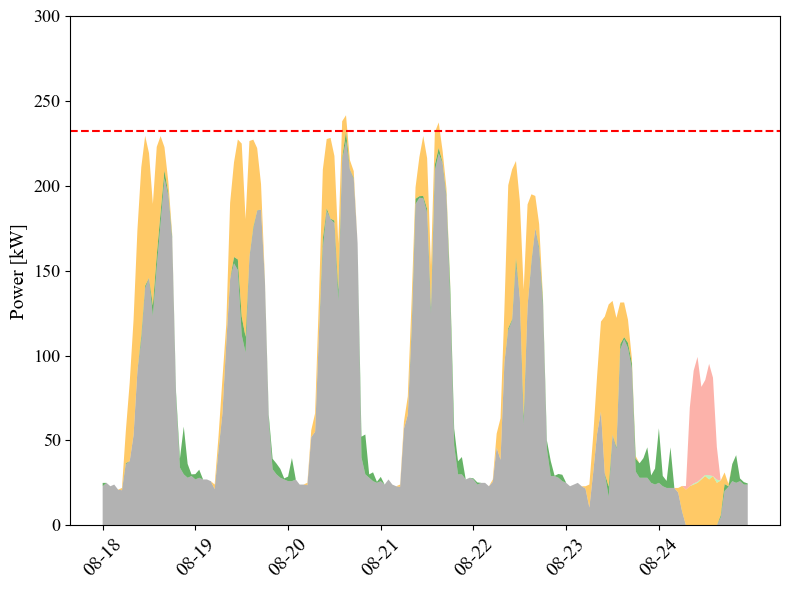

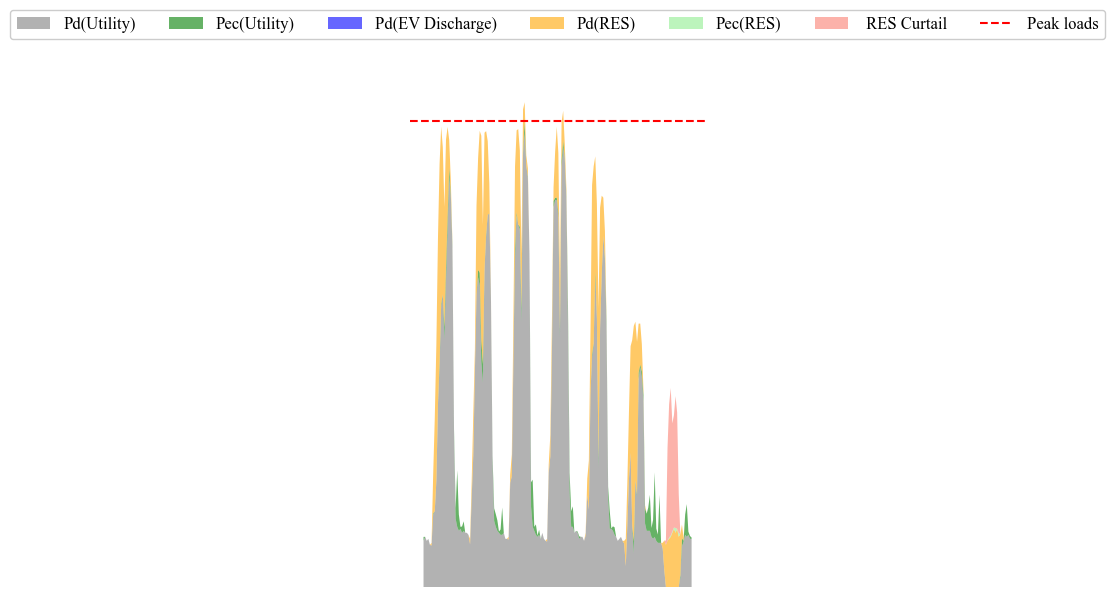

5 3520.3804250609123


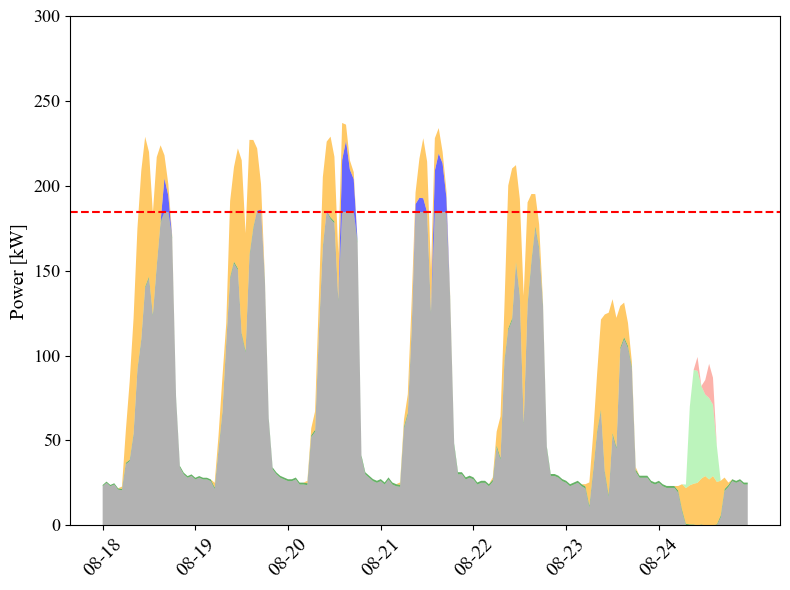

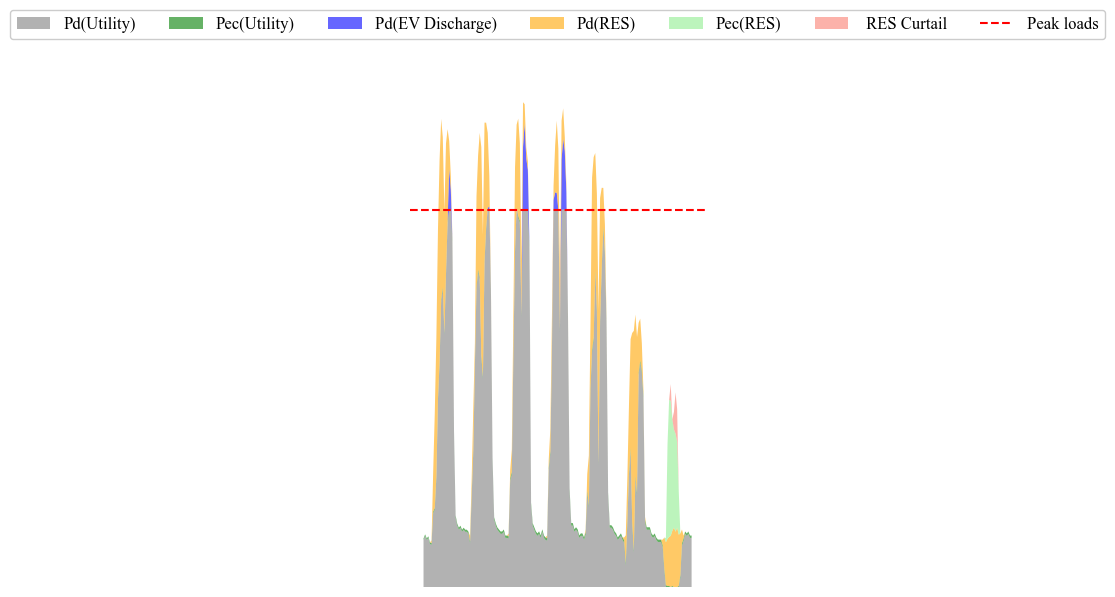

6 5346.5079359910005


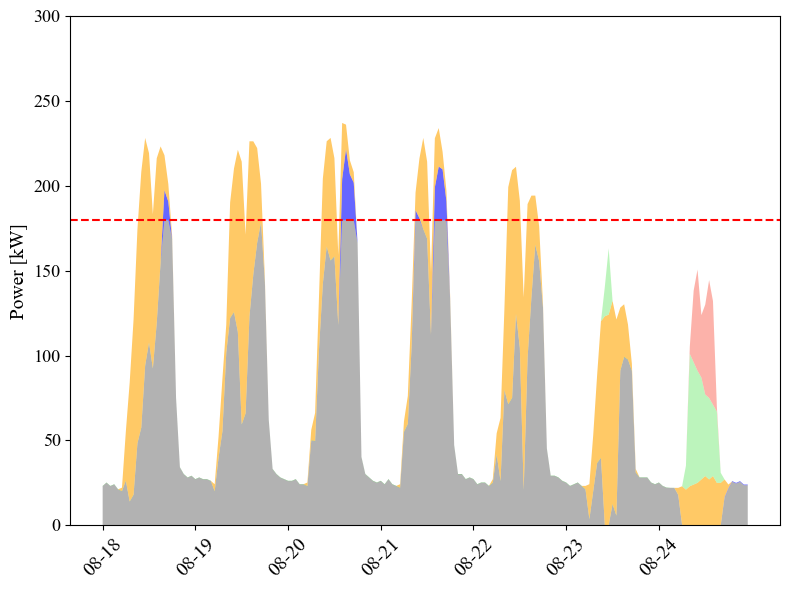

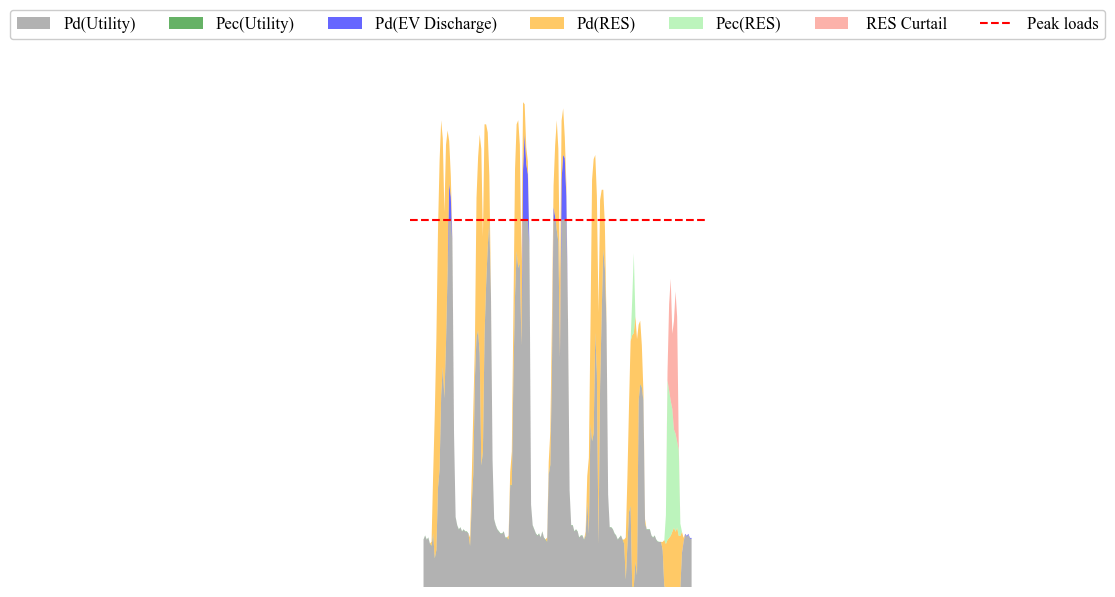

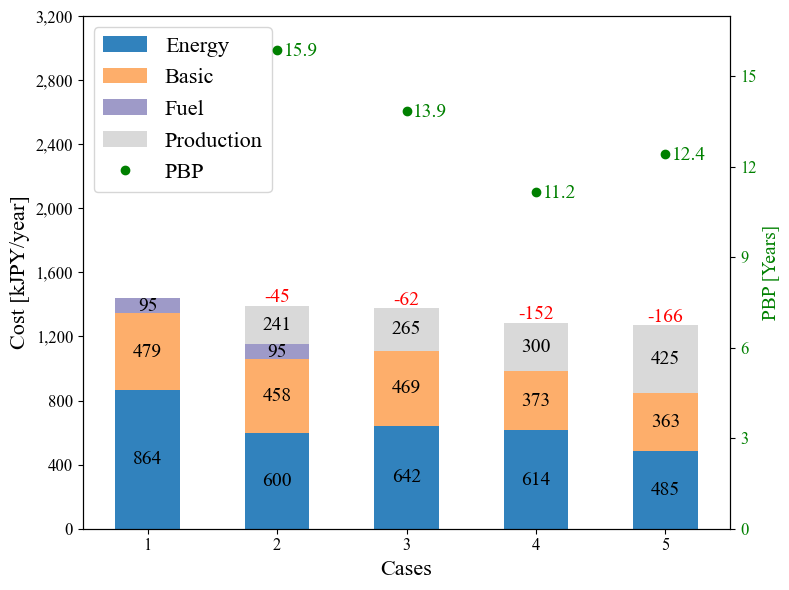

IMG2/B11002784_GHG_CPBP.png


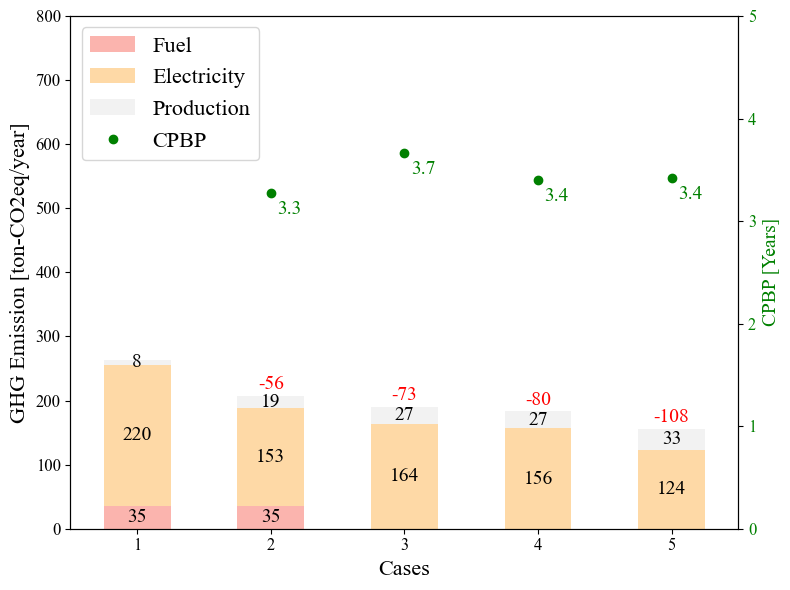

C:\Users\kiuch\AppData\Local\Temp\ipykernel_26552\1435798864.py:372: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  daily_avg = ts.resample('H').mean()


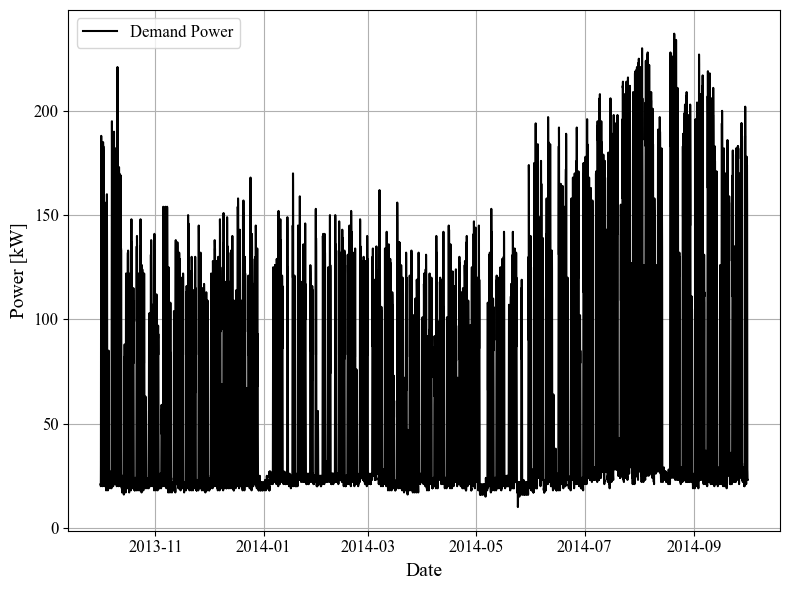

IMG2/B11002784_3_typical_week_demand.png


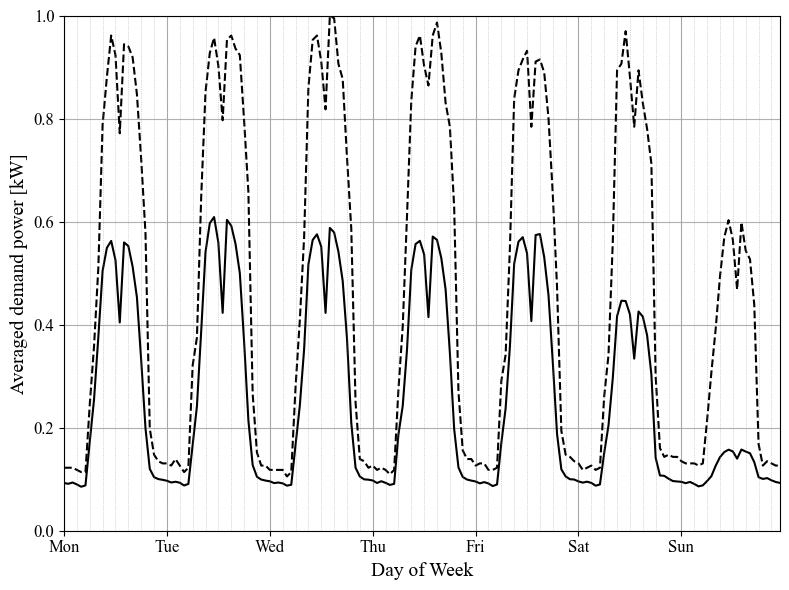

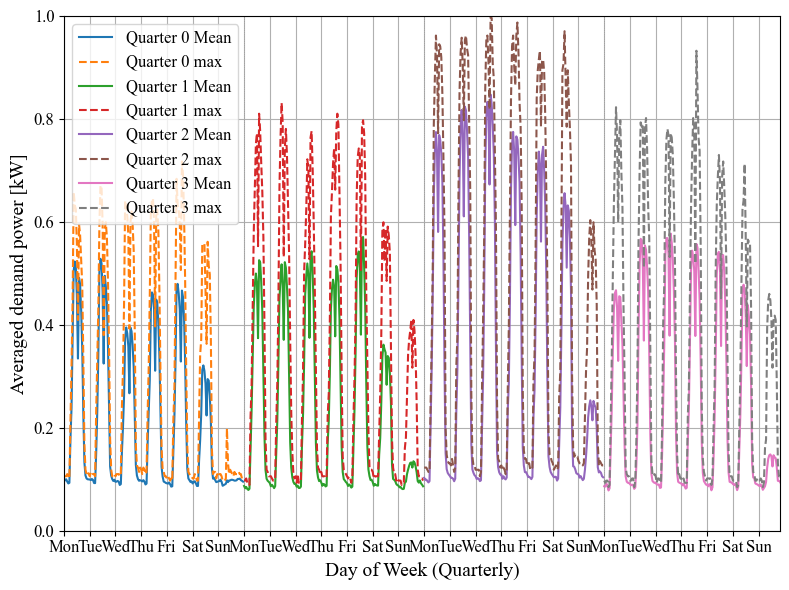

   AnnualCost    PBP  TotalGHG  CPBP  SolarCapacity  EnergyCost  ContractCost  \
1     1438.05   0.00    255.87  0.00           0.00      864.49        478.93   
2     1393.08  15.88    188.32  3.27         135.87      599.59        457.69   
4     1375.97  13.86    163.68  3.66         135.87      641.88        468.92   
5     1285.99  11.15    156.44  3.40         135.87      613.50        372.82   
6     1272.35  12.43    123.61  3.42         206.35      484.73        362.85   

    SSR   SCR  Cost_trvl  Prod_cost  OM_cost  Annual_Prod_cost  GHG_trvl  \
1  0.00  0.00      94.63       0.00     0.00              0.00  35424.54   
2  0.31  0.88      94.63    3464.67    67.93            241.17  35424.54   
4  0.29  0.88       0.00    3689.67    69.43            265.17      0.00   
5  0.33  0.98       0.00    3959.67    76.93            299.67      0.00   
6  0.47  0.94       0.00    5756.90   112.17            424.77      0.00   

   GHG_Comsumption  GHG_Annual_Production  GHG_prod_ev  

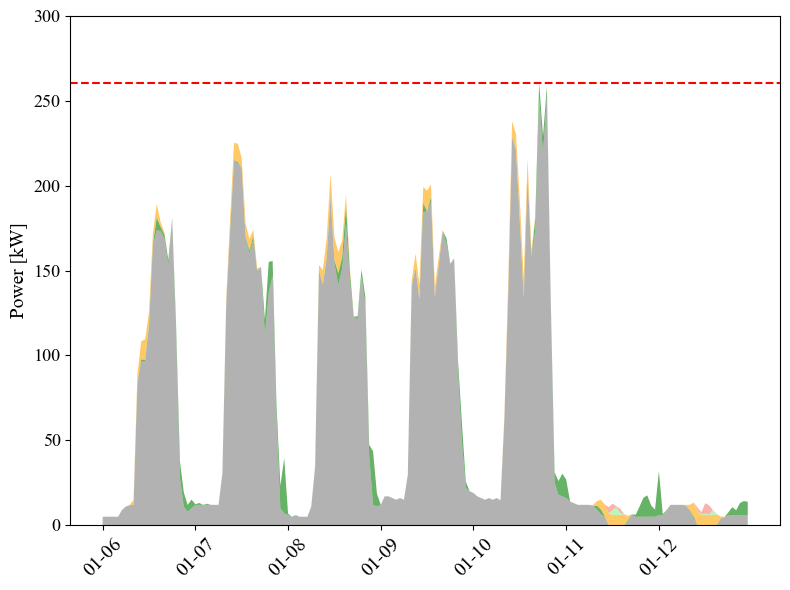

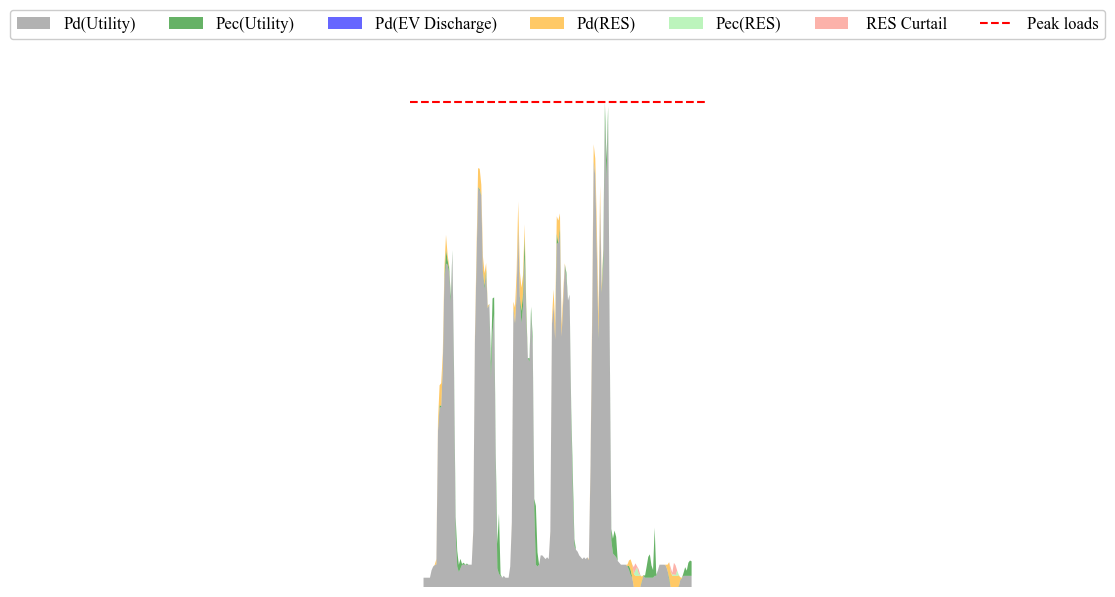

5 466.58181886004485


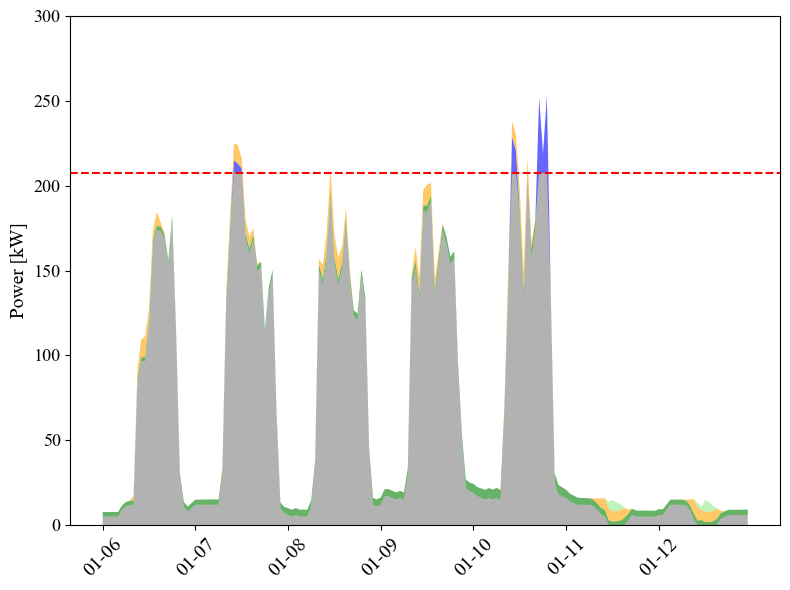

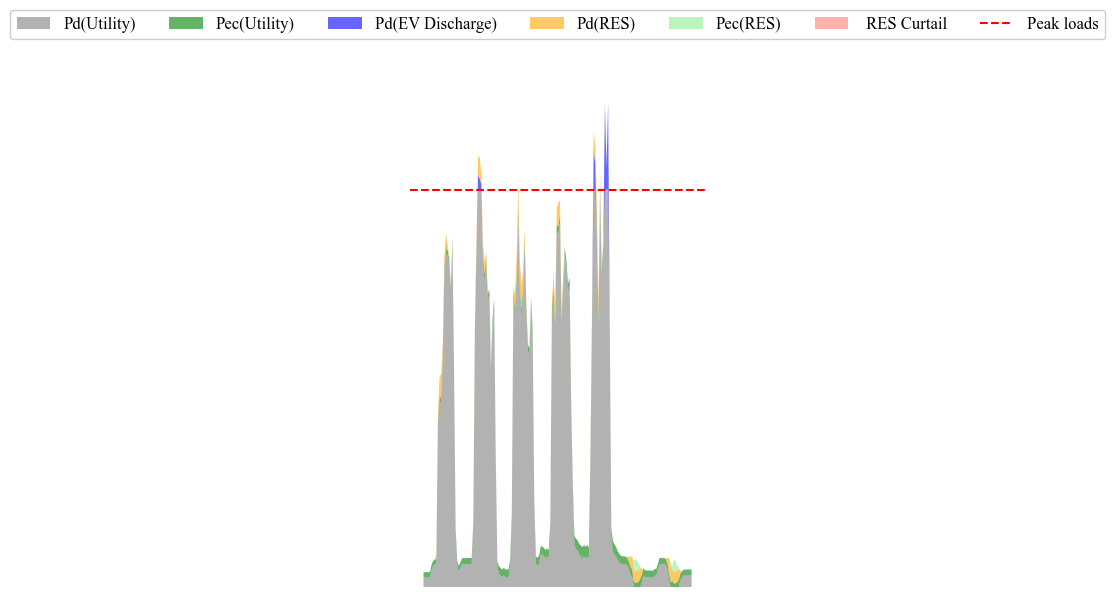

6 2457.8863734569236


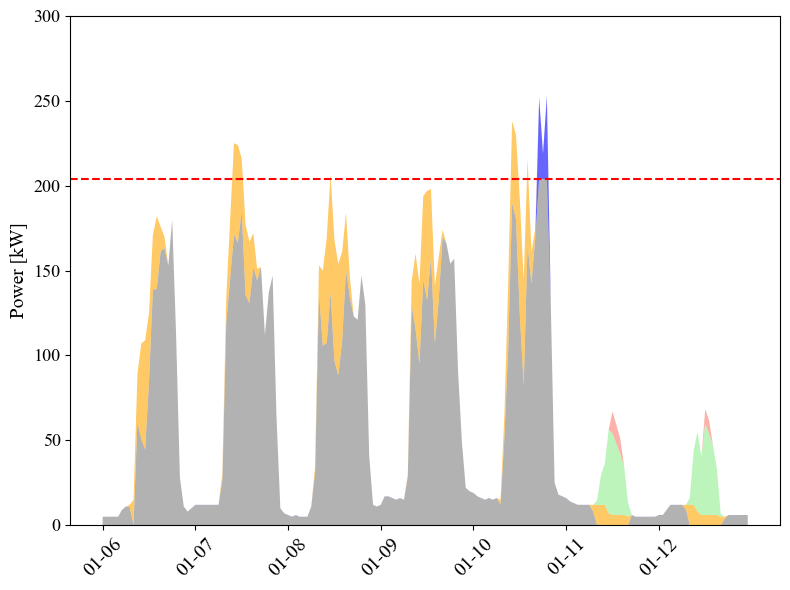

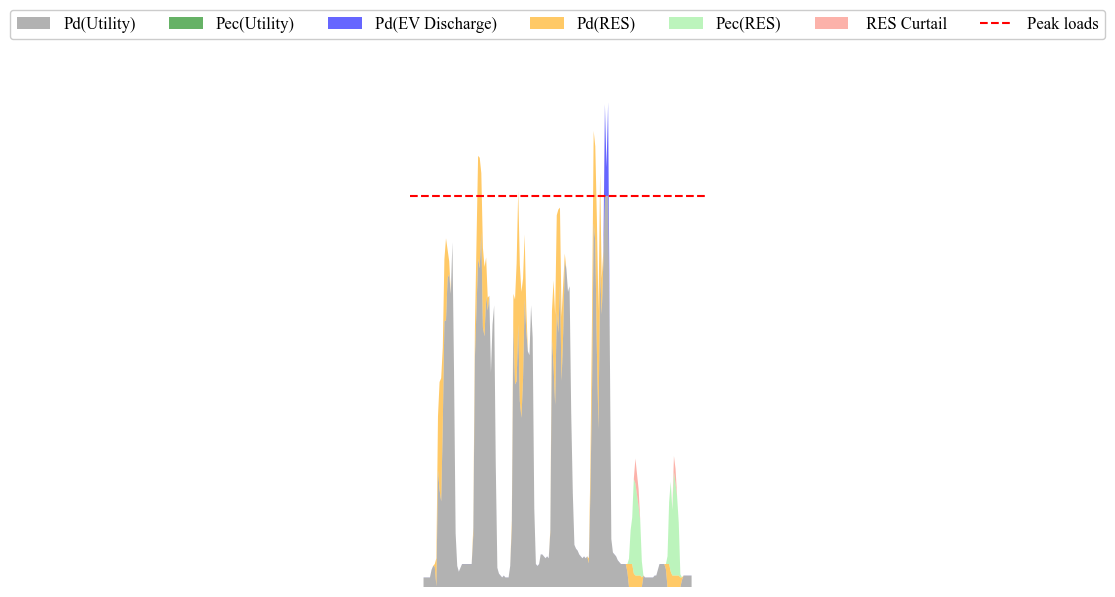

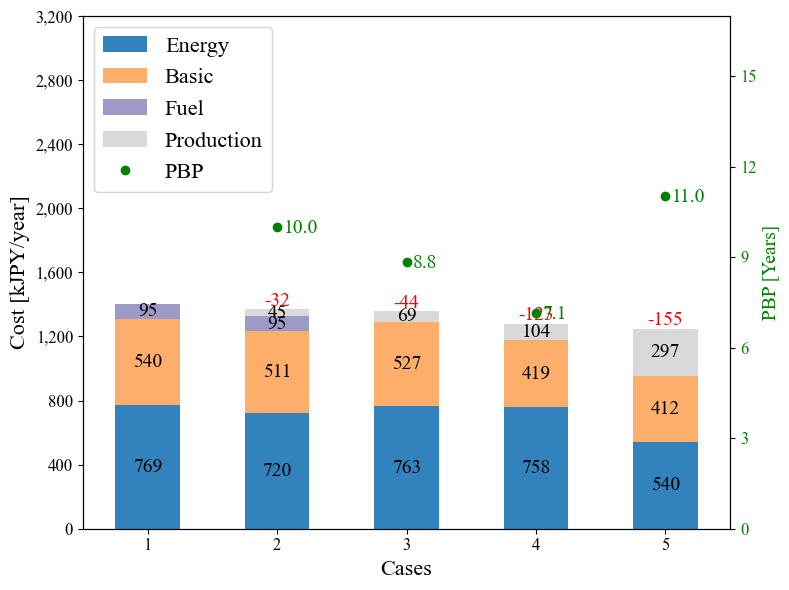

IMG2/B11005002_GHG_CPBP.png


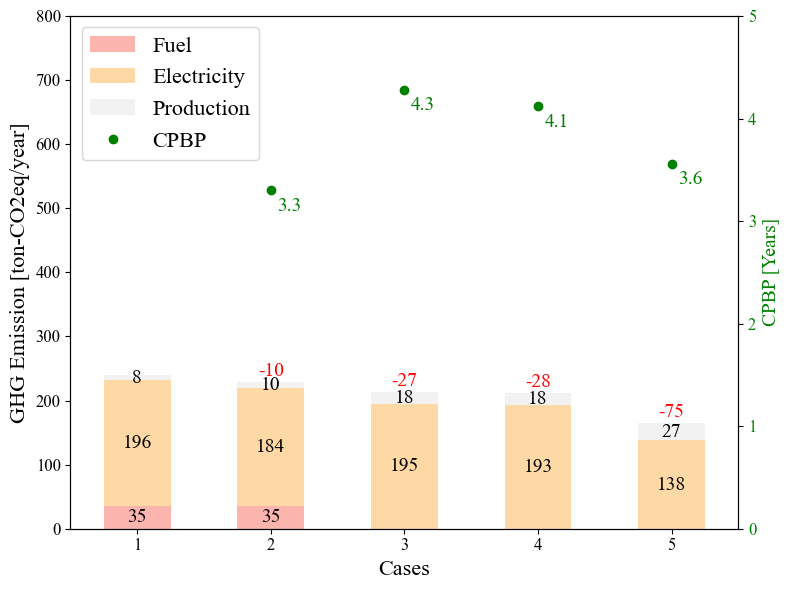

C:\Users\kiuch\AppData\Local\Temp\ipykernel_26552\1435798864.py:372: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  daily_avg = ts.resample('H').mean()


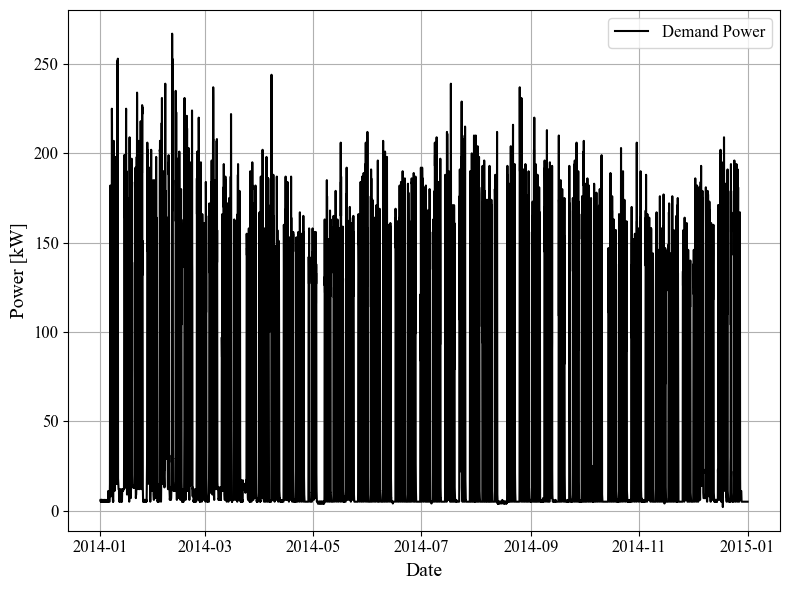

IMG2/B11005002_3_typical_week_demand.png


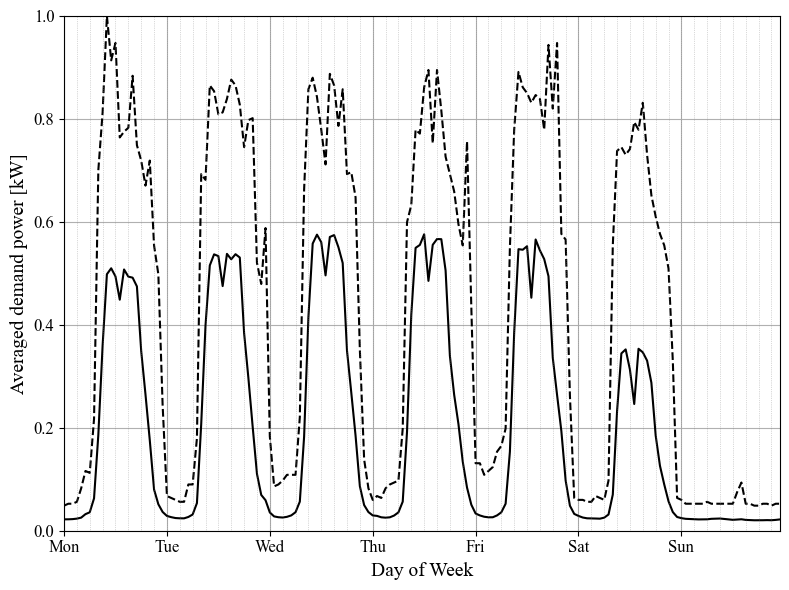

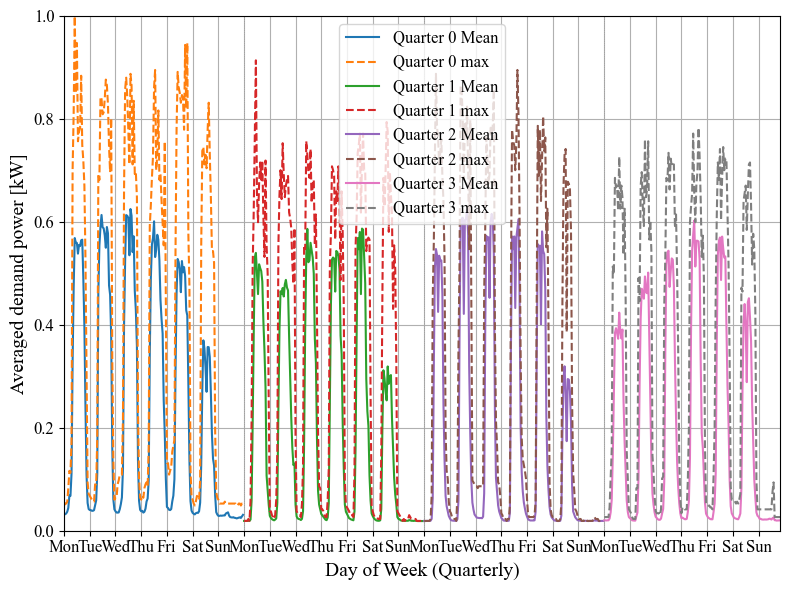

   AnnualCost    PBP  TotalGHG  CPBP  SolarCapacity  EnergyCost  ContractCost  \
1     1403.63   0.00    231.63  0.00           0.00      769.44        539.55   
2     1371.32  10.02    219.09  3.30          25.45      720.24        511.26   
4     1359.14   8.85    194.65  4.28          25.45      763.33        526.63   
5     1280.58   7.14    193.22  4.12          25.45      757.71        419.19   
6     1248.64  11.02    137.67  3.56         134.09      539.89        412.24   

    SSR   SCR  Cost_trvl  Prod_cost  OM_cost  Annual_Prod_cost  GHG_trvl  \
1  0.00  0.00      94.63       0.00     0.00              0.00  35424.54   
2  0.06  0.87      94.63     649.09    12.73             45.18  35424.54   
4  0.06  0.90       0.00     874.09    14.23             69.18      0.00   
5  0.07  1.00       0.00    1144.09    21.73            103.68      0.00   
6  0.34  0.94       0.00    3914.32    76.05            296.51      0.00   

   GHG_Comsumption  GHG_Annual_Production  GHG_prod_ev  

In [44]:




# ▼ 設定
data_path = "TEEA_EV15.csv"
folder_path = "EnergyManagement_Output_15"
scenarios_to_compare = [1, 2, 4, 5, 6]
cost_columns = ['EnergyCost', 'ContractCost', 'Cost_trvl', 'Annual_Prod_cost']
GHG_columns = ["GHG_trvl","GHG_Comsumption","GHG_Annual_Production"]
peak_info_list = []
# ▼ 除外対象の name
# excluded_name = ["B11001679","B11004418","B11002265","B11004367","B11004358","B11005314","B11004359",
#                  "B11002553","B11001292","B11005277","B11002461","B11005275","B11005269","B11005064",
#                  "B11000702","B11001296","B11001891","B11006131","B11005283","B11005279","B11005272",
#                  "B11001112","B11005002","B11001304","B11001364","B11002214","B11001587","B11003795",
#                  "B11001444","B11004731","B11002731","B11004245","B11000374","B11001569","B11003499",
#                  "B11005226","B11002460","B11001875","B11001872","B11002456","B11001156","B11006117",
#                  "B11005493","B11001876","B11002464","B11000021","B11005012","B11004544","B11001118",
#                  "B11000575","B11006387","B11001493","B11001525","B11001487","B11001053","B11000602",
#                  "B11005305","B11000230","B11005403","B11005472","B11005409","B11005491","B11000601"]

excluded_name = ["B11005403","B11005493","B11005472","B11006117","B11003964","B11005064","B11004367",
                 "B11005045","B11002460","B11002456","B11002731","B11003442","B11001549","B11002591",
                 "B11001898","B11001746","B11000716","B11005988","B11002642","B11004608","B11003707"]
excluded_name = ["B11002642","B11004608","B11003707","B11005064","B11005472","B11005045"]
#B11002460
#B11001898
#B11005279


# ▼ データ読み込み
df = pd.read_csv(data_path)
print(sum(df['name'].isin(excluded_name)))
df = df[
   ~df['name'].isin(excluded_name)
]
df['CPBP_months'] = df['CPBP'] * 12


# =========================
# 関数定義
# =========================

def get_name_metrics(name):
    """指定された name の各シナリオにおける指標値を取得"""
    metrics = {
        s: df[(df['Scinario'] == s) & (df['name'] == name)].iloc[0][[
            'AnnualCost', 'PBP', 'GHG_Total', 'CPBP', 'SolarCapacity',
            'EnergyCost', 'ContractCost', 'SSR[-]', 'SCR[-]', 
            'Cost_trvl', 'Prod_cost', 'OM_cost', 'Annual_Prod_cost',"GHG_trvl","GHG_Comsumption","GHG_Annual_Production","GHG_prod_ev"
        ]] for s in scenarios_to_compare
    }
    df_metrics = pd.DataFrame(metrics).T.rename(columns={
        'GHG_Total': 'TotalGHG',
        'SSR[-]': 'SSR',
        'SCR[-]': 'SCR'
    })
    return df_metrics.apply(pd.to_numeric, errors='coerce').round(2)

def process_name(name):
    """全シナリオでピーク検出、シナリオ6から週データ抽出、シナリオ4と6でグラフ化"""
    graph_scenarios = [4, 5, 6]
    scenario_data = {}  # 各シナリオの時系列データ保存
    peak_info_dict = {}  # 各シナリオの最上位ピーク情報
    peak_week_data = None
    peak_time_scenario6 = None
    demand_peak_scenario6 = None

    # --- 第1パス：全シナリオでピーク抽出 ---
    for scenario in scenarios_to_compare:
        file_path = os.path.join(folder_path, f"{name}_{scenario}.csv")
        if not os.path.exists(file_path):
            print(f"⚠️ ファイルなし: {file_path}")
            continue

        ts = pd.read_csv(file_path, index_col=0, parse_dates=True)
        ts.index = pd.to_datetime(ts.index, format='%Y-%m-%d %H:%M:%S', errors='raise')

        if ts.index.isnull().any():
            print(f"⚠️ {file_path} に日時変換できないインデックスがあります。除去します。")
            ts = ts[~ts.index.isnull()]

        ts['Total_Power'] = ts['Demand_Power'] - ts['RE_Power'] + ts['EV_Charge']
        scenario_data[scenario] = ts  # 保存しておく

        top_peaks = ts['Total_Power'].nlargest(3)

        print(f"\n🔺 Top 3 Peaks for {name} - Scenario {scenario}")
        for i, (peak_time, peak_value) in enumerate(top_peaks.items(), 1):
            peak_row = ts.loc[peak_time]
            print(f"  {i}位 Peak @ {peak_time} → Total_Power: {peak_value:.2f} kW | "
                  f"Demand: {peak_row['Demand_Power']:.2f} kW | "
                  f"RE: {peak_row['RE_Power']:.2f} kW | "
                  f"EV: {peak_row['EV_Charge']:.2f} kW")

            if i == 1:
                # 最上位ピークのみ保存
                peak_info = {
                    "name": name,
                    "scenario": scenario,
                    "peak_time": peak_time,
                    "peak_power_kW": peak_value
                }
                peak_info_list.append(peak_info)
                peak_info_dict[scenario] = peak_info

                # シナリオ6なら週データも保存
                if scenario == 6:
                    peak_time_scenario6 = peak_time
                    demand_peak_scenario6 = peak_row['Demand_Power']
                    week_start = peak_time - pd.Timedelta(
                        days=peak_time.weekday(),
                        hours=peak_time.hour,
                        minutes=peak_time.minute,
                        seconds=peak_time.second
                    )
                    #week_start = datetime.datetime(peak_time.year,4,1,0,0,0)
                    week_end = week_start + pd.Timedelta(weeks=1)

                    peak_week_data = ts[(ts.index >= week_start) & (ts.index < week_end)]
                if scenario == 4:
                    peak_time_scenario4 = peak_time
                    demand_peak_scenario4 = peak_row['Demand_Power']

    # --- 第2パス：グラフ化（4と6のみ、ピーク週は6から） ---
    if peak_week_data is None:
        print("⚠️ シナリオ6のピーク週データが見つかりません。グラフ化をスキップします。")
        return

    for scenario in graph_scenarios:
        if scenario not in scenario_data:
            continue  # データなければスキップ

        ts = scenario_data[scenario]
        peak_week_data = ts[(ts.index >= week_start) & (ts.index < week_end)].copy()
        peak_week_data.loc[:, 'EV_Discharge'] = peak_week_data['EV_Charge'].apply(lambda x: -x if x < 0 else 0)
        peak_week_data.loc[:, 'EV_Charge_Positive'] = peak_week_data['EV_Charge'].apply(lambda x: x if x > 0 else 0)
        peak_week_data.loc[:, 'Demand_from_RES'] = peak_week_data.apply(lambda row: min(row['Demand_Power'], row['RE_Power']), axis=1)
        peak_week_data.loc[:, 'Demand_from_EV_Discharge'] = peak_week_data.apply(lambda row: min(row['Demand_Power'] - row['Demand_from_RES'], row['EV_Discharge']), axis=1)
        peak_week_data.loc[:, 'Demand_from_Utility'] = peak_week_data['Demand_Power'] - peak_week_data['Demand_from_RES'] - peak_week_data['Demand_from_EV_Discharge']
        peak_week_data.loc[:, 'EV_Charge_from_RES'] = peak_week_data.apply(lambda row: min(row['RE_Power'] - row['Demand_from_RES'], row['EV_Charge_Positive']), axis=1)
        peak_week_data.loc[:, 'EV_Charge_from_Utility'] = peak_week_data['EV_Charge_Positive'] - peak_week_data['EV_Charge_from_RES']
        peak_week_data.loc[:, 'RE_Curtail'] = peak_week_data['RE_Power'] - peak_week_data['Demand_from_RES']-peak_week_data['EV_Charge_from_RES']

        # print("EV_Discharge:\n", peak_week_data['EV_Discharge'].head())  # EV_Discharge の最初の5行
        # print("Demand_Power:\n", peak_week_data['Demand_Power'].head())  # Demand_Power の最初の5行
        # print("RE_Power:\n", peak_week_data['RE_Power'].head())  # Demand_Power の最初の5行

        # print("Demand_from_RES:\n", peak_week_data['Demand_from_RES'].head(), "\n")
        # print("Demand_from_EV_Discharge:\n", peak_week_data['Demand_from_EV_Discharge'].head(), "\n")
        # print("Demand_from_Utility:\n", peak_week_data['Demand_from_Utility'].head(), "\n")
        # print("EV_Charge_from_RES:\n", peak_week_data['EV_Charge_from_RES'].head(), "\n")
        # print("EV_Charge_from_Utility:\n", peak_week_data['EV_Charge_from_Utility'].head(), "\n")

        #print(peak_week_data.loc[peak_week_data.index>=datetime.datetime(2014,1,13,18),["net_demand","EV_Charge_Positive","EV_Discharge","RE_Power","Demand_Power"]])
        fig, ax1 = plt.subplots(figsize=(8, 6))

        print(scenario,peak_week_data['RE_Power'].sum())
        # EV Charge, RES Power, EV Dischargeの積み上げグラフ
        ax1.stackplot(peak_week_data.index, 
                    peak_week_data['Demand_from_Utility'],
                    peak_week_data['EV_Charge_from_Utility'],
                    peak_week_data['Demand_from_EV_Discharge'], 
                    peak_week_data['Demand_from_RES'],
                    peak_week_data['EV_Charge_from_RES'],
                    peak_week_data[ 'RE_Curtail'],
                    
                    labels=['Demand(Utility)','EV Charge(Utility)','Demand(EV Discharge)', 'Demand(RES)','EV Charge(RES)',' RES Curtail',], 
                    colors=['gray', 'green','blue', 'orange','lightgreen','salmon'], 
                    alpha=0.6)

        ax1.axhline(peak_info_dict[scenario]["peak_power_kW"], color='red', linestyle='--', label='Peak Power')
        
        # 文字サイズの調整
        #ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=7, frameon=True, facecolor='white', framealpha=1, fontsize=12)
        ax1.set_ylabel("Power [kW]", fontsize=14)
        #ax1.set_xlabel("Time", fontsize=14)
        
        # X軸、Y軸の目盛りサイズの変更
        ax1.tick_params(axis='both', labelsize=13)
        xticks = peak_week_data.index[::24]  # 1日ごとのデータを取得（24時間毎）
        xticklabels = [dt.strftime('%m-%d') for dt in xticks]

        ax1.set_xticks(xticks)  # X軸の目盛り位置
        ax1.set_xticklabels(xticklabels, rotation=45, fontsize=14)  # 月日形式のラベル、回転角度とフォントサイズの調整

    #
        
        
        
        ax1.set_ylim(0, round(demand_peak_scenario4 * 1.2, -2))
        plt.xticks(rotation=45)
        plt.tight_layout()

        # グラフの保存
        plt.savefig(f"IMG2/{name}-{scenario}.png")
        plt.show()

        fig, ax1 = plt.subplots(figsize=(8, 6))

        # データと積み上げグラフ（最小限のプロット）
        ax1.stackplot(peak_week_data.index, 
                    peak_week_data['Demand_from_Utility'],
                    peak_week_data['EV_Charge_from_Utility'],
                    peak_week_data['Demand_from_EV_Discharge'], 
                    peak_week_data['Demand_from_RES'],
                    peak_week_data['EV_Charge_from_RES'],
                    peak_week_data[ 'RE_Curtail'],
                    
                    labels=['Pd(Utility)','Pec(Utility)','Pd(EV Discharge)', 'Pd(RES)','Pec(RES)',' RES Curtail',], 
                    colors=['gray', 'green','blue', 'orange','lightgreen','salmon'], 
                    alpha=0.6)
        ax1.axhline(peak_info_dict[scenario]["peak_power_kW"], color='red', linestyle='--', label='Peak loads')
        # 凡例の設定
        ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=7, frameon=True, facecolor='white', framealpha=1, fontsize=12)
        
        # 軸は不要なので非表示にする
        ax1.set_axis_off()

        # 画像として保存
        plt.tight_layout()
        plt.savefig(f"IMG2/legend.png", bbox_inches='tight')
        plt.show()


def plot_cost_and_pbp(name,df_metrics, title=""):
    """積み上げコスト棒グラフ + PBPの2軸プロット"""
    df = df_metrics.reset_index(drop=True)
    
    df['PBP'] = df['PBP'].replace(0, np.nan)
    df['TotalCost'] = df[cost_columns].sum(axis=1)
    base_cost = df.loc[0, 'TotalCost']
    new_labels = ['Energy', 'Basic', 'Fuel', 'Production']

    fig, ax1 = plt.subplots(figsize=(8, 6))
    df[cost_columns].plot(kind='bar', stacked=True, ax=ax1, colormap='tab20c')
    ax1.set_xticklabels(range(1,6), rotation=0)
    #ax1.set_ylim(0, round(base_cost*2,-2))
    ax1.set_ylim(0, 3200)
    
    ax1.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
    ax1.set_yticks(range(0,3300,400))
    ax1.set_ylabel('Cost [kJPY/year]',fontsize=16)
    ax1.set_xlabel('Cases',fontsize=16)

    for i in range(len(df)):
        bottom = 0
        for col in cost_columns:
            height = df.loc[i, col]
            if height > 0:
                ax1.text(i, bottom + height / 2, f"{height:.0f}", ha='center', va='center', fontsize=14)
                bottom += height

    for i, total in enumerate(df['TotalCost']):
        if i<1:continue
        diff = total - base_cost
        sign = "+" if diff > 0 else ""
        ax1.text(i, total + 20, f"{sign}{diff:.0f}", color="red",ha='center', fontsize=14)

    ax2 = ax1.twinx()
    ax2.plot(df.index, df['PBP'], color='green', marker='o', linestyle='', label='PBP')
    ax2.set_ylim(0, 17)
    ax2.set_yticks(range(0,17,3))  # 7日 * 4四半期
    ax2.set_ylabel('PBP [Years]', color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    for i, val in enumerate(df['PBP']):
        if not np.isnan(val):
            ax2.text(i + 0.05, val-0.2, f"{val:.1f}", ha='left', color='green', fontsize=14)

    # 凡例統合
    handles, labels = [], []
    for ax in [ax1, ax2]:
        h, l = ax.get_legend_handles_labels()
        handles += h
        labels += l

    # cost_columns に新しいラベルを設定
    cost_labels = new_labels
    
    # 新しいラベルを使って凡例を設定
    ax1.legend(handles, new_labels + ['PBP'], loc='upper left', fontsize=16)
    #ax1.set_title(title)
    plt.tight_layout()
    plt.savefig(f"IMG2/{name}_TAC_PBP.png", bbox_inches='tight')

    plt.show()

def plot_ghg_and_cpBP(name,df_metrics, title=""):
    """GHG積み上げ + CPBP折れ線グラフ（月単位表示）"""
    df = df_metrics.reset_index(drop=True).copy()
    
    # AGHG単位調整：kg → t
    for col in GHG_columns:
        df[col] = df[col] / 1000  # kg → tCO2e 換算

    df['CPBP'] = df['CPBP'].replace(0, np.nan)  # ゼロは非表示に
    df['CPBP_months'] = df['CPBP'] * 12         # 年 → 月に変換

    df['TotalGHG'] = df[GHG_columns].sum(axis=1)
    base_ghg = df.loc[0, 'TotalGHG']

    new_labels = ['Fuel', 'Electricity', 'Production']

    fig, ax1 = plt.subplots(figsize=(8, 6))

    # GHG 積み上げ棒グラフ
    df[GHG_columns].plot(kind='bar', stacked=True, ax=ax1, colormap='Pastel1')
    ax1.set_xticklabels(range(1,6),rotation=0)

    #ax1.set_ylim(0, round(base_ghg * 1.7, -2))
    ax1.set_ylim(0, 800)
    ax1.set_ylabel('GHG Emission [ton-CO2eq/year]',fontsize=16)
    ax1.set_xlabel('Cases',fontsize=16)

    # ▼ 各要素に数値表示（棒の中）
    for i in range(len(df)):
        bottom = 0
        for col in GHG_columns:
            height = df.loc[i, col]
            if height > 0:
                ax1.text(i, bottom + height / 2, f"{height:.0f}", ha='center', va='center', fontsize=14)
                bottom += height

    # ▼ ベースケースとの差（赤字）
    for i, total in enumerate(df['TotalGHG']):
        if i == 0:
            continue
        diff = total - base_ghg
        sign = "+" if diff > 0 else ""
        ax1.text(i, total + 10, f"{sign}{diff:.0f}", color="red", ha='center', fontsize=14)

    # CPBP 折れ線（月単位）
    ax2 = ax1.twinx()
    ax2.plot(df.index, df['CPBP'], color='green', marker='o', linestyle='', label='CPBP (years)')
    ax2.set_ylim(0, 5)
    ax2.set_ylabel('CPBP [Years]', color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    # CPBP 数値（点の上に表示）
    for i, val in enumerate(df['CPBP']):
        if not np.isnan(val):
            ax2.text(i + 0.05, val-0.2, f"{val:.1f}", ha='left', color='green', fontsize=14)

    # 凡例とタイトル
    handles, labels = [], []
    for ax in [ax1, ax2]:
        h, l = ax.get_legend_handles_labels()
        handles += h
        labels += l
    ax1.legend(handles, new_labels + ['CPBP'], loc='upper left', fontsize=16)
    #ax1.set_title(title + " - GHG and CPBP (months)")

    plt.tight_layout()
    print(f"IMG2/{name}_GHG_CPBP.png")
    
    plt.savefig(f"IMG2/{name}_GHG_CPBP.png", bbox_inches='tight')
    plt.show()

def plot_annual_demand_re(name, scenario):
    """年間のDemand_PowerとRE_Powerのプロファイルをプロット"""
    file_path = os.path.join(folder_path, f"{name}_{scenario}.csv")
    if not os.path.exists(file_path):
        print(f"⚠️ {file_path} が見つかりません。")
        return

    # ▼ データ読み込み
    ts = pd.read_csv(file_path, index_col=0, parse_dates=True)

    # ここで必ず日時型に変換する（念のため）
    ts.index = pd.to_datetime(ts.index, format='%Y-%m-%d %H:%M:%S', errors='raise')


    # 以降 resample 可能
    daily_avg = ts.resample('H').mean()

    # ▼ プロット
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(daily_avg.index, daily_avg['Demand_Power'], label='Demand Power', color='black')
    #ax.plot(daily_avg.index, daily_avg['RE_Power'], label='RE Power', color='green')
    #ax.plot(daily_avg.index, daily_avg['EV_Charge'], label='EV Power', color='orange')
    

    #ax.set_title(f"{name} - Scenario {scenario}：年間プロファイル")
    ax.set_ylabel("Power [kW]")
    ax.set_xlabel("Date")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.savefig(f"IMG2/{name}_{scenario}_annual_profile.png", bbox_inches='tight')
    plt.show()

def plot_typical_week_profile(name, scenario):
    """典型的な1週間（168時間）のDemand_Power平均プロファイルをプロット"""
    file_path = os.path.join(folder_path, f"{name}_{scenario}.csv")
    if not os.path.exists(file_path):
        print(f"⚠️ {file_path} が見つかりません。")
        return

    # ▼ データ読み込み
    ts = pd.read_csv(file_path, index_col=0, parse_dates=True)
    ts.index = pd.to_datetime(ts.index, format='%Y-%m-%d %H:%M:%S', errors='raise')

    # ▼ 曜日と時刻の列を追加
    ts['Weekday'] = ts.index.weekday  # 月:0〜日:6
    ts['Hour'] = ts.index.hour        # 0〜23
    ts["Demand_Power"] = ts["Demand_Power"]/ts["Demand_Power"].max()

    # ▼ Groupby → 平均
    # ▼ Groupbyでmean, max, minを算出
    agg_df = ts.groupby(['Weekday', 'Hour'])['Demand_Power'].agg(['mean', 'max', 'min']).reset_index()
    agg_df['WeekHour'] = agg_df['Weekday'] * 24 + agg_df['Hour']
    agg_df = agg_df.sort_values('WeekHour')

    # ▼ プロット
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(agg_df['WeekHour'], agg_df['mean'], label='Mean', color='black')
    ax.plot(agg_df['WeekHour'], agg_df['max'], color='black', linestyle='--')
    #ax.plot(agg_df['WeekHour'], agg_df['min'],color='black', linestyle='--')

    for h in range(0, 168, 3):
        ax.axvline(h, color='gray', linestyle=':', linewidth=0.5, alpha=0.6)

    #ax.set_xticks([i * 24 for i in range(8)])
    xticks = [i * 24 for i in range(7)]  # 月曜日から日曜日まで
    xticklabels = [ts.index[i * 24].strftime('%m-%d') for i in range(7)]  # MM-DDの形式で表示
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
    ax.set_xlim(0, 167)
    ax.set_ylim(0, 1)
    ax.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
    ax.set_xlabel("Day of Week")
    ax.set_ylabel("Averaged demand power [kW]")
    ax.grid(True)
    plt.tight_layout()
    print(f"IMG2/{name}_{scenario}_typical_week_demand.png")
    plt.savefig(f"IMG2/{name}_{scenario}_typical_week_demand.png", bbox_inches='tight')
    plt.show()
def plot_quarterly_week_profile(name, scenario):
    """四半期ごとの1週間（168時間）のDemand_Power平均プロファイルをプロット"""
    file_path = os.path.join(folder_path, f"{name}_{scenario}.csv")
    if not os.path.exists(file_path):
        print(f"⚠️ {file_path} が見つかりません。")
        return

    # ▼ データ読み込み
    ts = pd.read_csv(file_path, index_col=0, parse_dates=True)
    ts.index = pd.to_datetime(ts.index, format='%Y-%m-%d %H:%M:%S', errors='raise')

    # ▼ 曜日、時刻、四半期列を追加
    ts['Weekday'] = ts.index.weekday  # 月:0〜日:6
    ts['Hour'] = ts.index.hour        # 0〜23
    ts['Quarter'] = (ts.index.month - 1) // 3   # 四半期（1〜4）
    ts["Demand_Power"] = ts["Demand_Power"] / ts["Demand_Power"].max()  # 正規化

    # ▼ Groupby → 平均を四半期ごとに集約
    agg_df = ts.groupby(['Quarter', 'Weekday', 'Hour'])['Demand_Power'].agg(['mean', 'max', 'min']).reset_index()
    agg_df['QuarterWeekHour'] = agg_df['Quarter'] * 168 + agg_df['Weekday'] * 24 + agg_df['Hour']
    agg_df = agg_df.sort_values('QuarterWeekHour')

    # ▼ プロット
    fig, ax = plt.subplots(figsize=(8, 6))
    for quarter in agg_df['Quarter'].unique():
        quarter_data = agg_df[agg_df['Quarter'] == quarter]
        ax.plot(quarter_data['QuarterWeekHour'], quarter_data['mean'], label=f'Quarter {quarter} Mean')
        ax.plot(quarter_data['QuarterWeekHour'], quarter_data['max'], ls="--", label=f'Quarter {quarter} max')

    # 直線を引いて曜日ごとの区切りを視覚化
    for h in range(0, 168 * 4, 168):
        ax.axvline(h, color='gray', linestyle=':', linewidth=0.5, alpha=0.6)

    # x軸の設定（四半期ごとの曜日区切り）
    ax.set_xticks([i * 24 for i in range(7 * 4)])  # 7日 * 4四半期
    ax.set_xlim(0, 167 * 4)
    ax.set_ylim(0, 1)
    ax.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'] * 4)
    ax.set_xlabel("Day of Week (Quarterly)")
    ax.set_ylabel("Averaged demand power [kW]")
    ax.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.savefig(f"IMG2/{name}_{scenario}_quarterly_week_demand.png", bbox_inches='tight')
    plt.show()

# =========================
# 準備：条件に合致するデータ抽出
# =========================

# Scenario 4と6でピーク時間が一致するnameのみ抽出
peak_pivot = peak_df_[peak_df_["scenario"].isin([4, 6])].pivot(index="name", columns="scenario", values="peak_time")
matching_peak_names = peak_pivot[peak_pivot[4] == peak_pivot[6]].index.tolist()

# 条件に合致するnameとDemandClass=300をフィルター
df = df[df["name"].isin(matching_peak_names)]
df = df[df["DemandClass"] == 400]

# =========================
# SolarCapacity変化が最小のnameを特定
# =========================

df_5_6 = df[df['Scinario'].isin([5, 6])]
delta_df = df_5_6.pivot_table(index='name', columns='Scinario', values='SolarCapacity')
delta_df['delta'] = (delta_df[6] - delta_df[5]) / delta_df[5]

if delta_df['delta'].min() > 0:
    print("⚠️ PV容量が減少したケースはありません")

min_change_name = delta_df['delta'].idxmin()
min_change_df = get_name_metrics(min_change_name)

print(f"\n🔍 SolarCapacity変化が最小の name: {min_change_name}")
process_name(min_change_name)
plot_cost_and_pbp(min_change_name, min_change_df, title=f"{min_change_name} TAC and PBP")
plot_ghg_and_cpBP(min_change_name, min_change_df, title=f"{min_change_name} AGHG and CPBP")

plot_annual_demand_re(min_change_name, 3)
plot_typical_week_profile(min_change_name, 3)
plot_quarterly_week_profile(min_change_name, 3)
print(min_change_df)

# =========================
# SolarCapacity変化が最大のname
# =========================

max_change_name = delta_df['delta'].idxmax()
print(f"\n💰 SolarCapacity変化が最大の name: {max_change_name}")

max_df = get_name_metrics(max_change_name)
process_name(max_change_name)
plot_cost_and_pbp(max_change_name, max_df, title=f"{max_change_name} TAC and PBP")
plot_ghg_and_cpBP(max_change_name, max_df, title=f"{max_change_name} AGHG and CPBP")
plot_annual_demand_re(max_change_name, 3)
plot_typical_week_profile(max_change_name, 3)
plot_quarterly_week_profile(max_change_name, 3)


print(max_df)


36
DemandA

🔺 Top 3 Peaks for B11005006 - Scenario 1
  1位 Peak @ 2014-07-08 14:00:00 → Total_Power: 268.00 kW | Demand: 268.00 kW | RE: 0.00 kW | EV: 0.00 kW
  2位 Peak @ 2014-07-20 15:00:00 → Total_Power: 268.00 kW | Demand: 268.00 kW | RE: 0.00 kW | EV: 0.00 kW
  3位 Peak @ 2014-07-26 14:00:00 → Total_Power: 266.00 kW | Demand: 266.00 kW | RE: 0.00 kW | EV: 0.00 kW

🔺 Top 3 Peaks for B11005006 - Scenario 2
  1位 Peak @ 2014-09-03 13:00:00 → Total_Power: 229.46 kW | Demand: 248.00 kW | RE: 18.54 kW | EV: 0.00 kW
  2位 Peak @ 2014-07-26 16:00:00 → Total_Power: 224.92 kW | Demand: 262.00 kW | RE: 37.08 kW | EV: 0.00 kW
  3位 Peak @ 2014-01-19 12:00:00 → Total_Power: 222.46 kW | Demand: 241.00 kW | RE: 18.54 kW | EV: 0.00 kW

🔺 Top 3 Peaks for B11005006 - Scenario 4
  1位 Peak @ 2014-09-03 13:00:00 → Total_Power: 230.09 kW | Demand: 248.00 kW | RE: 18.54 kW | EV: 0.63 kW
  2位 Peak @ 2014-07-26 16:00:00 → Total_Power: 225.10 kW | Demand: 262.00 kW | RE: 37.08 kW | EV: 0.18 kW
  3位 Peak @ 2014-0

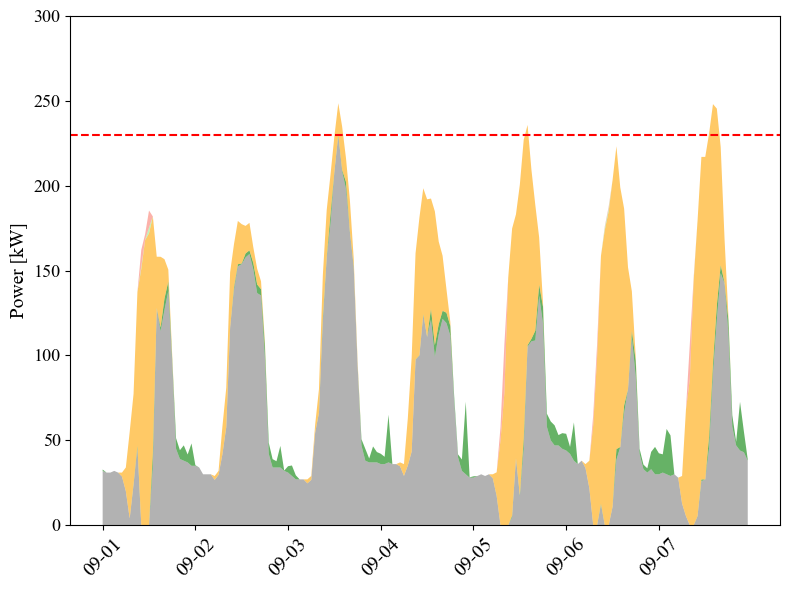

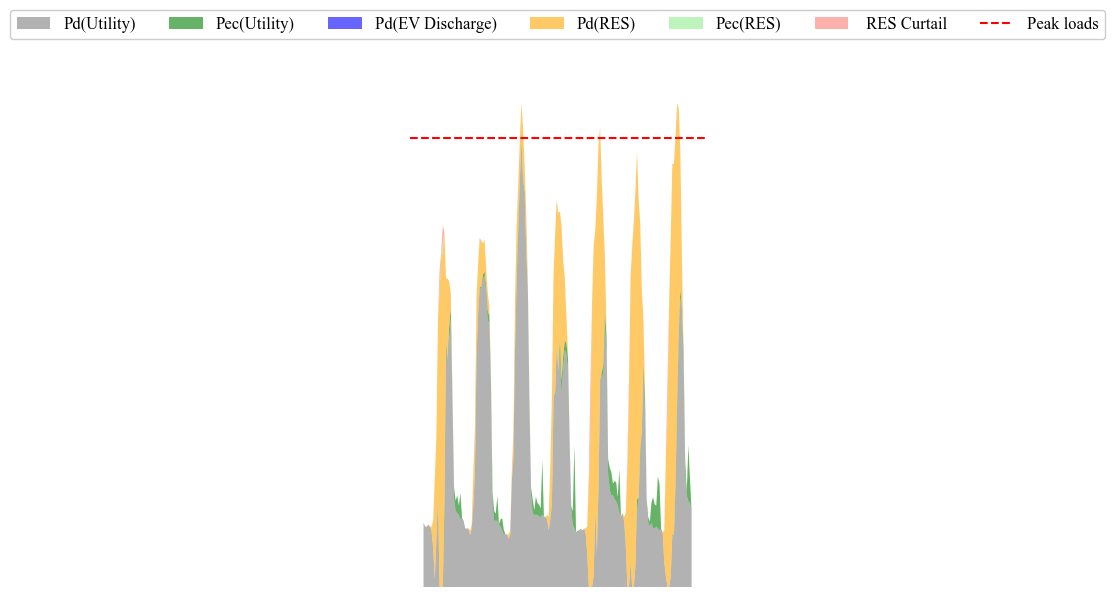

5 6217.746029047903


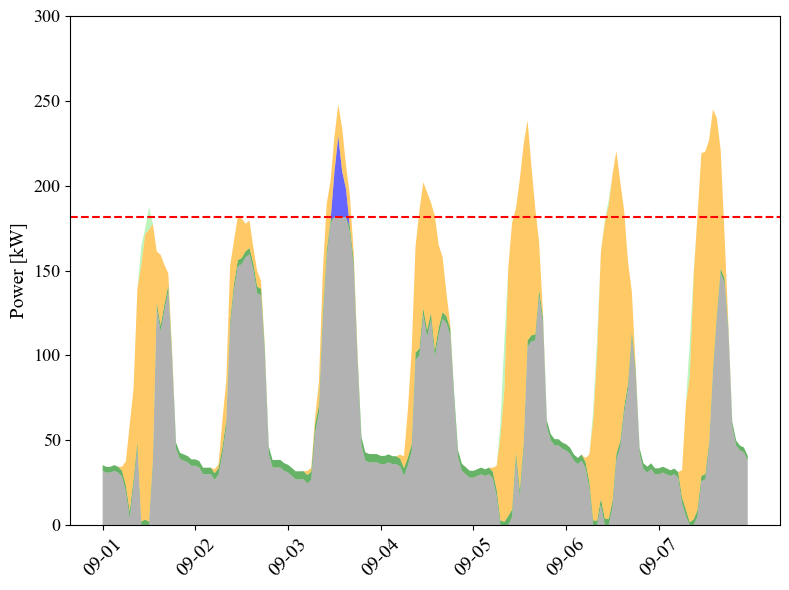

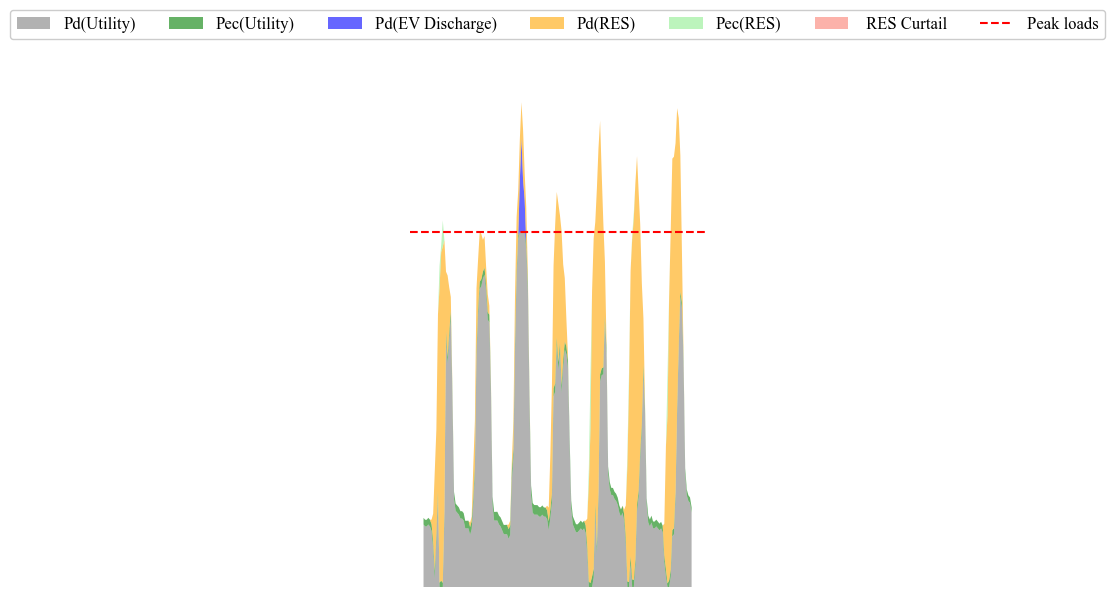

6 8209.179170550678


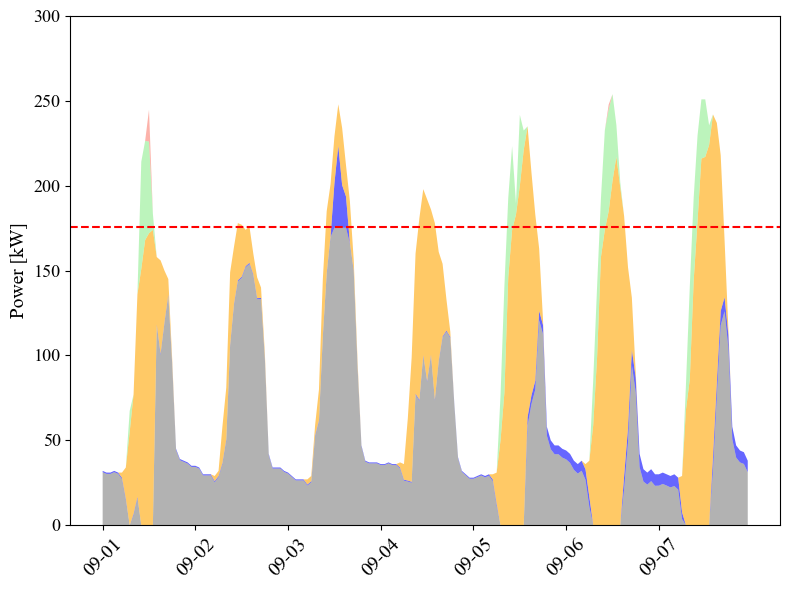

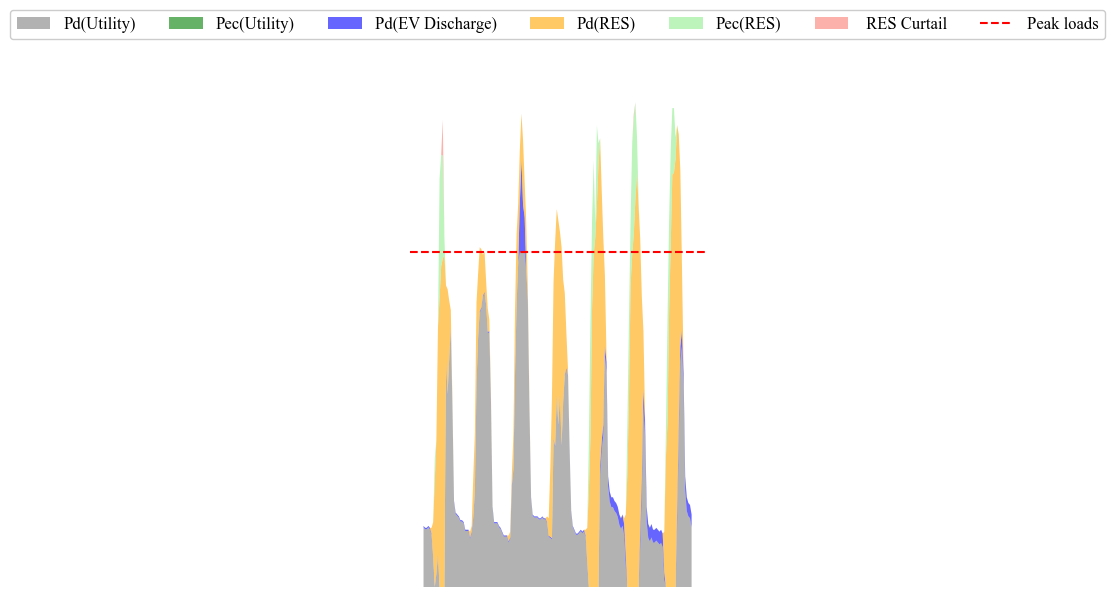

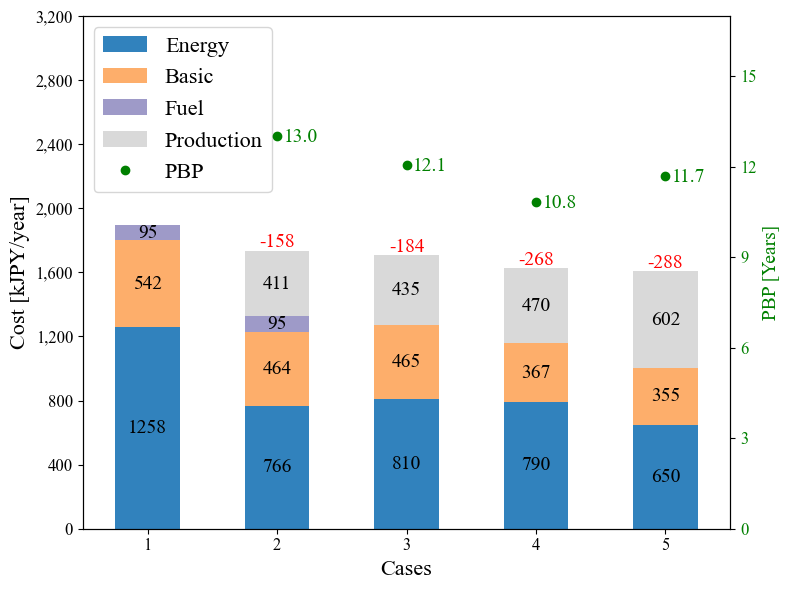

IMG2/B11005006_GHG_CPBP.png


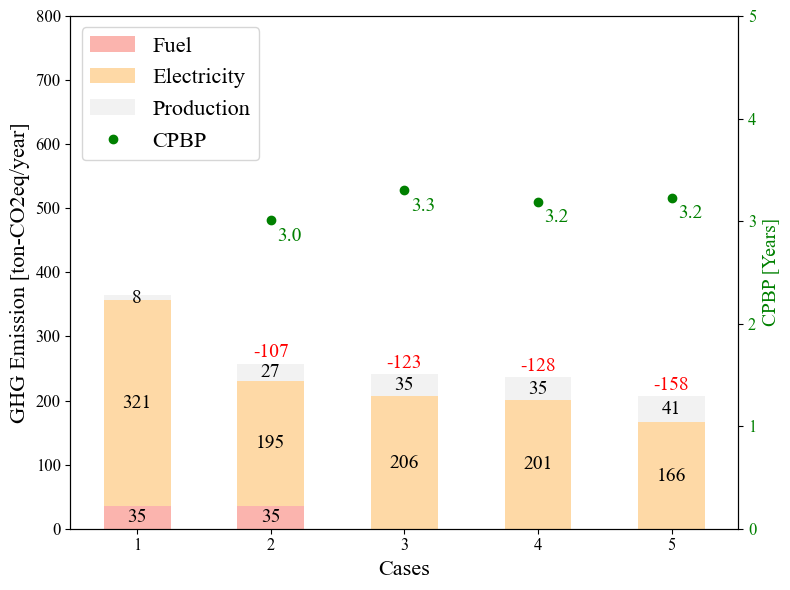

C:\Users\kiuch\AppData\Local\Temp\ipykernel_26552\1435798864.py:372: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  daily_avg = ts.resample('H').mean()


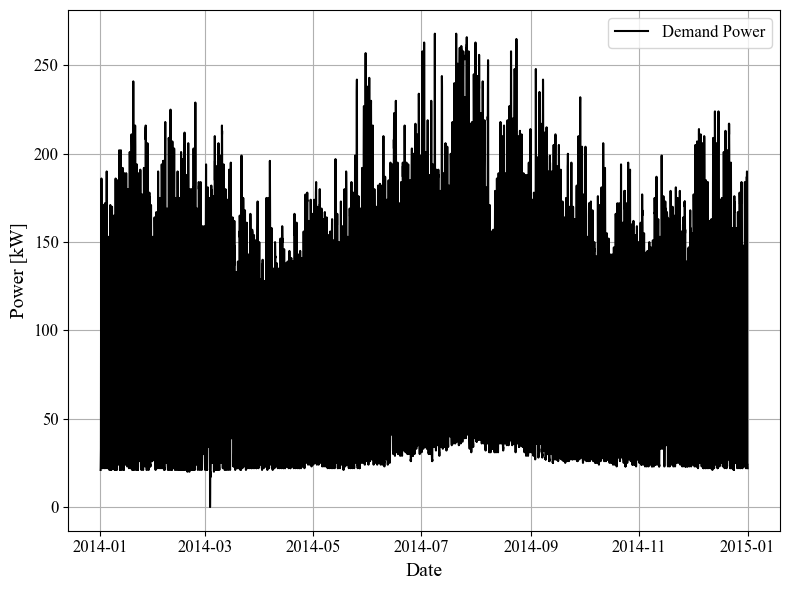

IMG2/B11005006_3_typical_week_demand.png


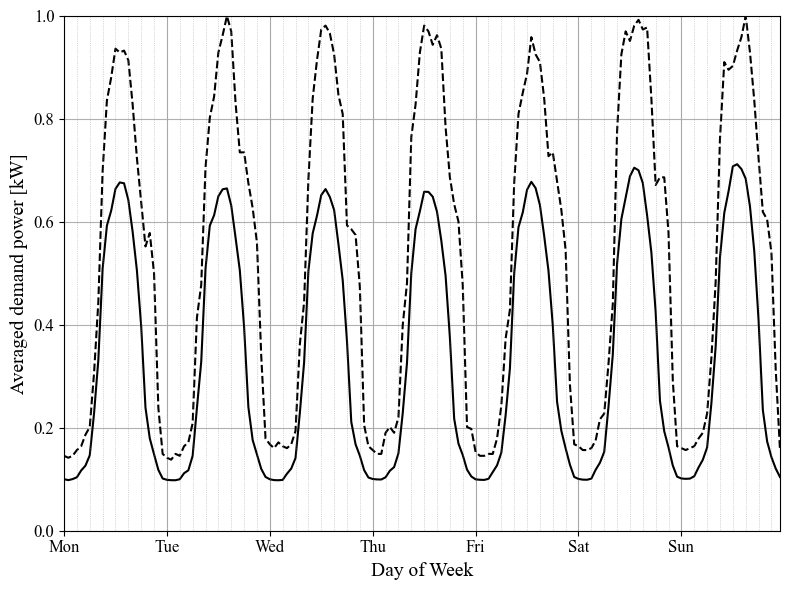

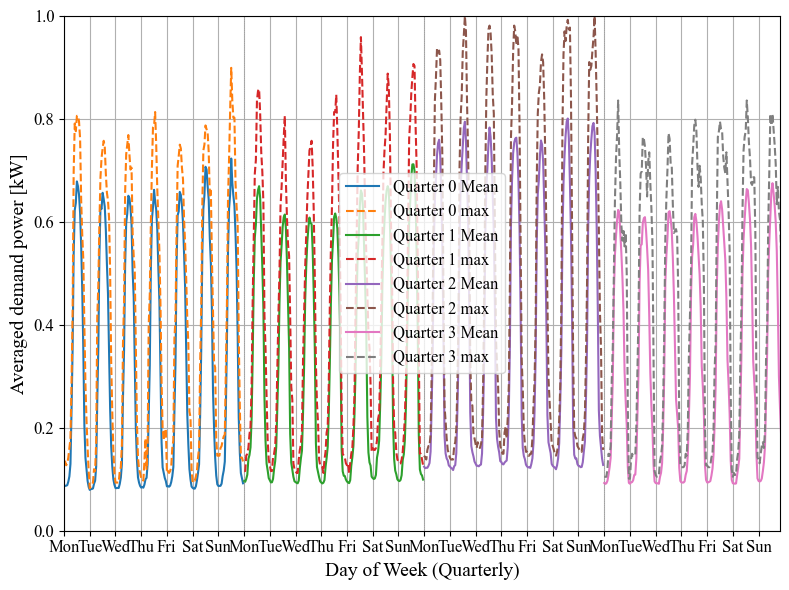

   AnnualCost    PBP  TotalGHG  CPBP  SolarCapacity  EnergyCost  ContractCost  \
1     1894.13   0.00    356.20  0.00           0.00     1257.93        541.57   
2     1735.95  13.03    230.82  3.01         231.75      766.27        463.69   
4     1709.83  12.07    206.43  3.30         231.75      809.52        464.96   
5     1626.19  10.82    201.36  3.19         231.75      789.64        366.70   
6     1606.38  11.69    165.77  3.23         305.97      650.09        354.70   

    SSR   SCR  Cost_trvl  Prod_cost  OM_cost  Annual_Prod_cost  GHG_trvl  \
1  0.00  0.00      94.63       0.00     0.00              0.00  35424.54   
2  0.39  0.95      94.63    5909.52   115.87            411.35  35424.54   
4  0.38  0.96       0.00    6134.52   117.37            435.35      0.00   
5  0.39  1.00       0.00    6404.52   124.87            469.85      0.00   
6  0.50  0.97       0.00    8297.24   161.99            601.60      0.00   

   GHG_Comsumption  GHG_Annual_Production  GHG_prod_ev  

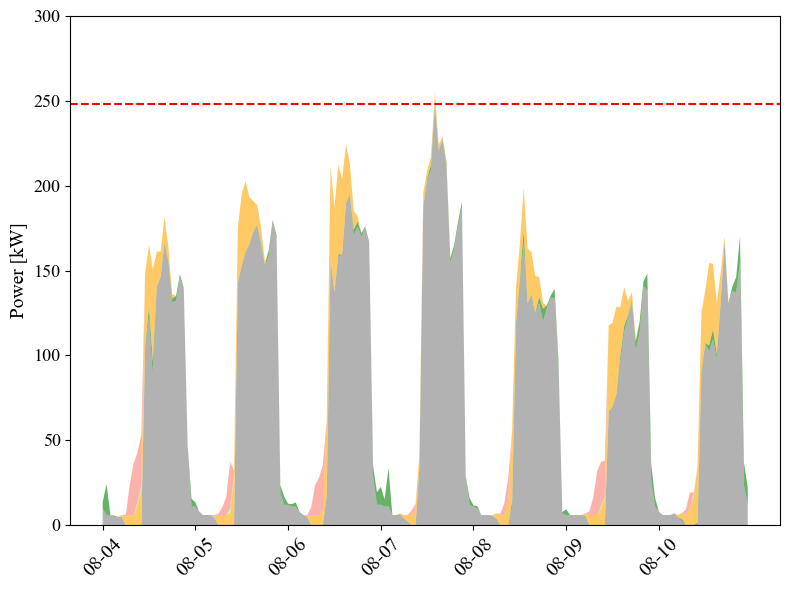

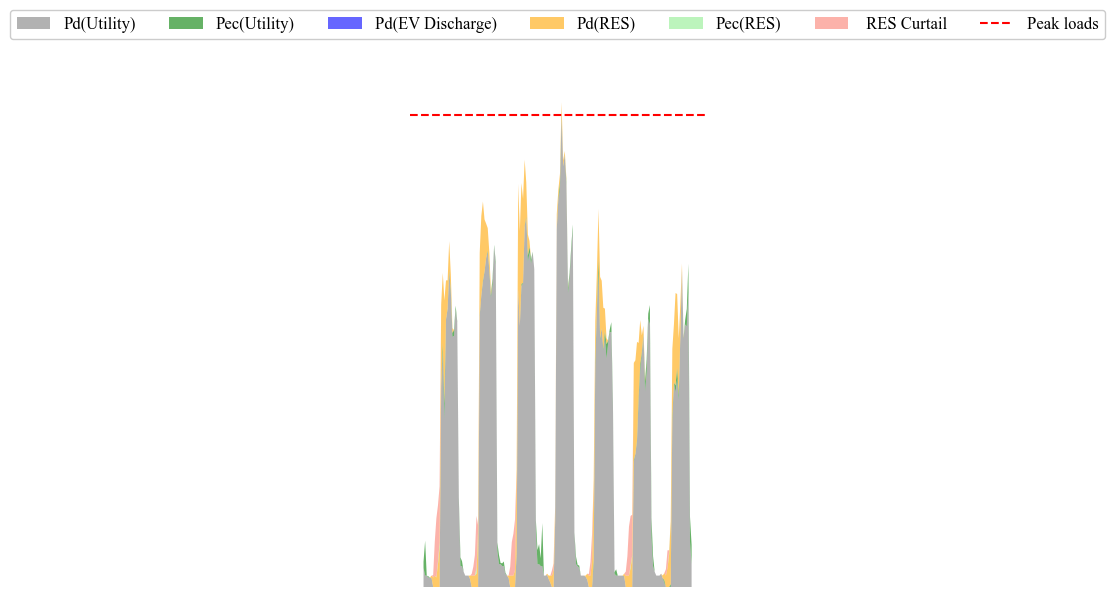

5 2024.8301886569648


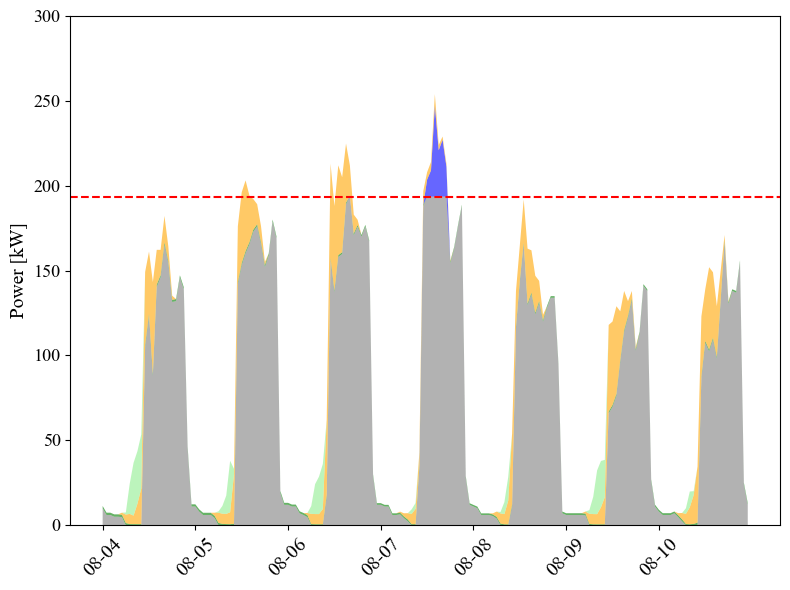

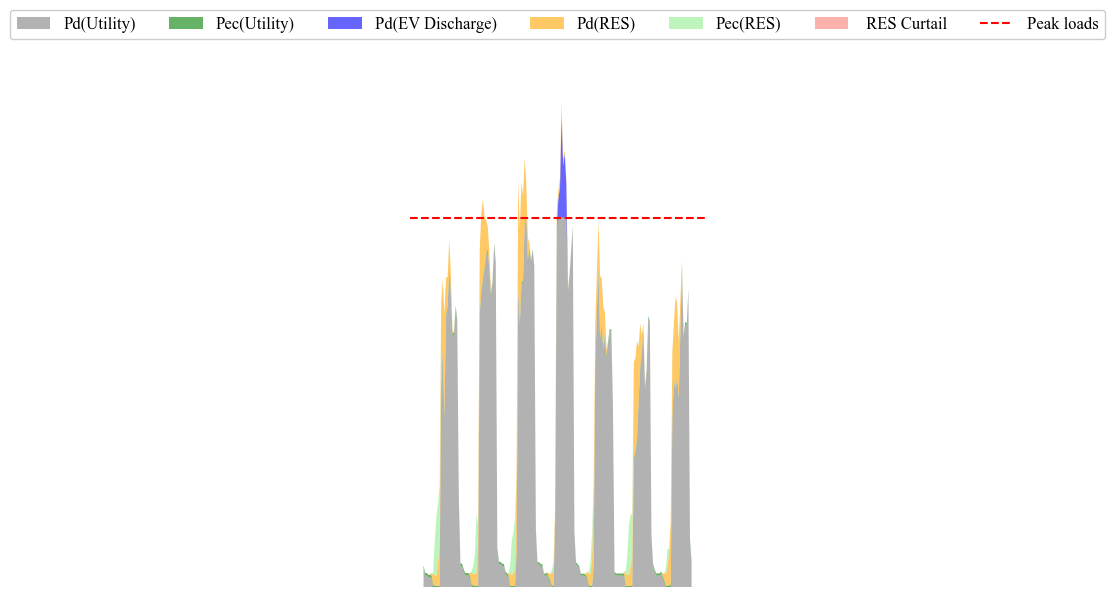

6 6245.318230231591


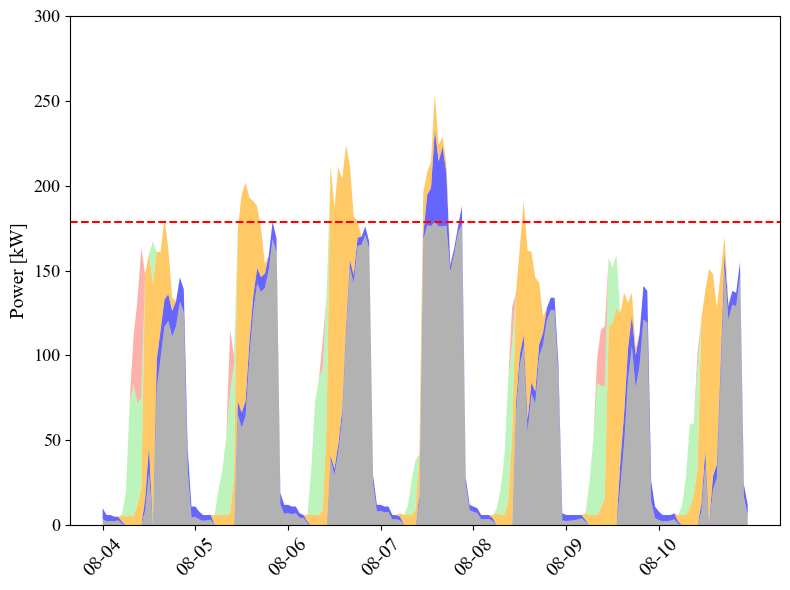

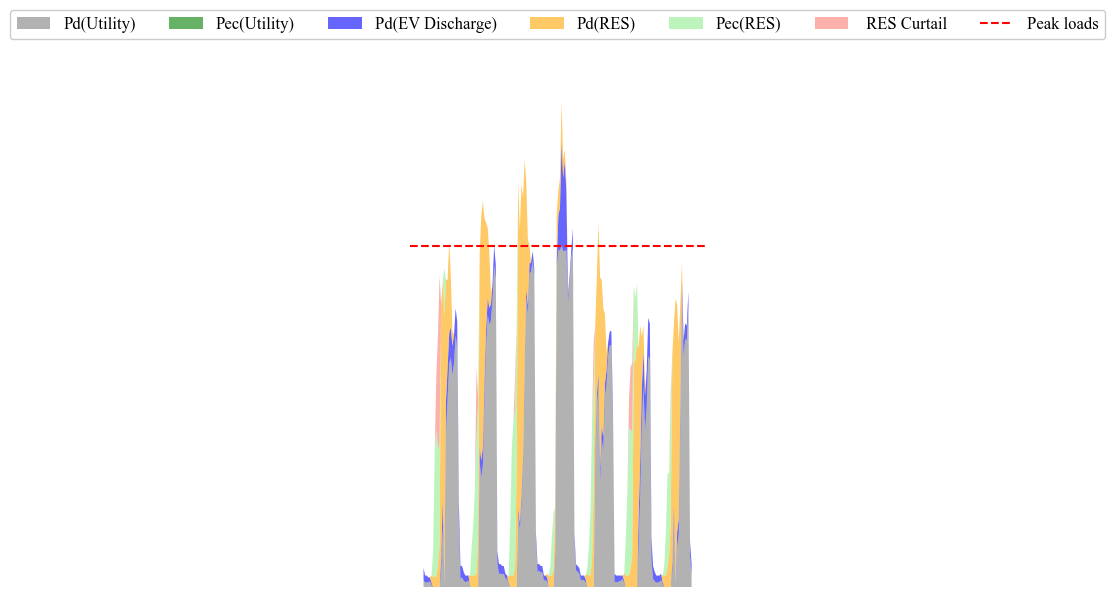

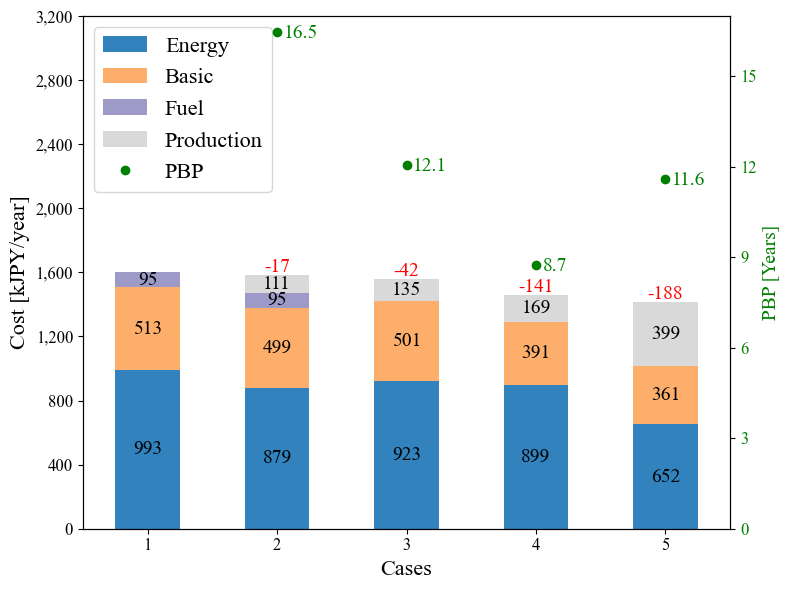

IMG2/B11002460_GHG_CPBP.png


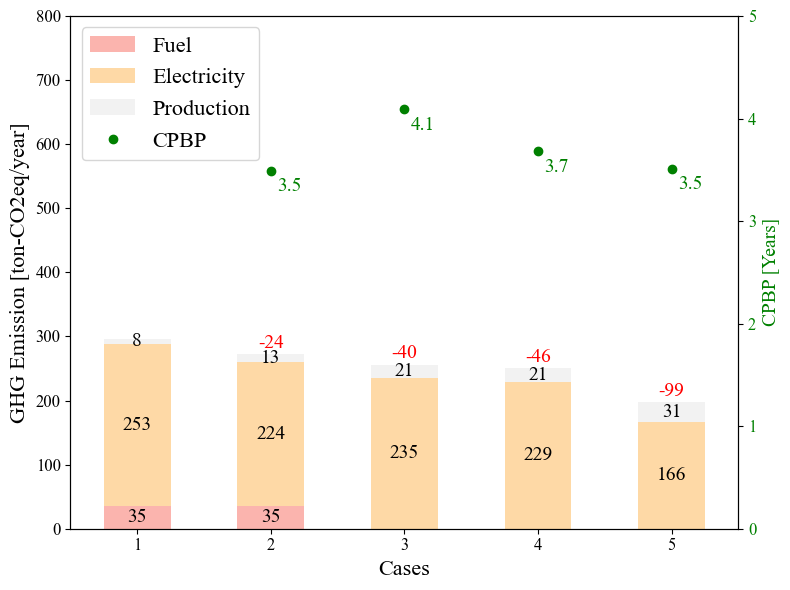

C:\Users\kiuch\AppData\Local\Temp\ipykernel_26552\1435798864.py:372: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  daily_avg = ts.resample('H').mean()


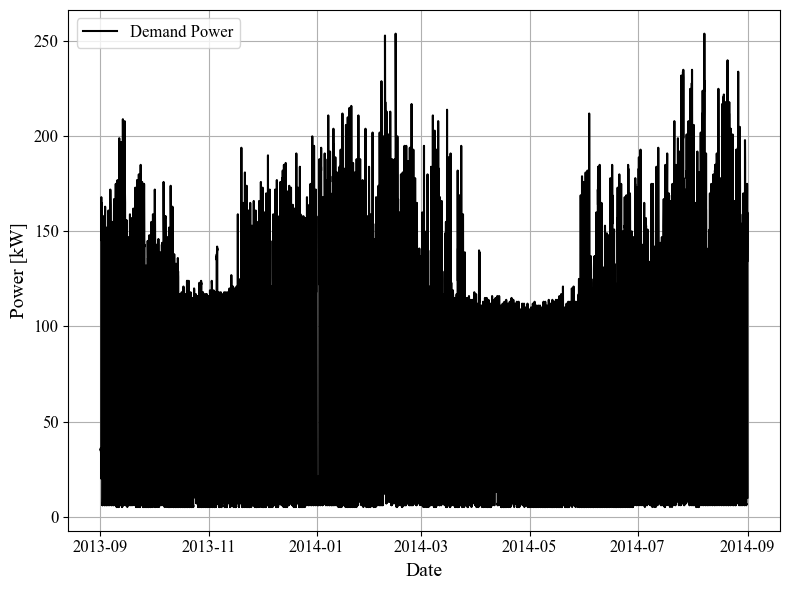

IMG2/B11002460_3_typical_week_demand.png


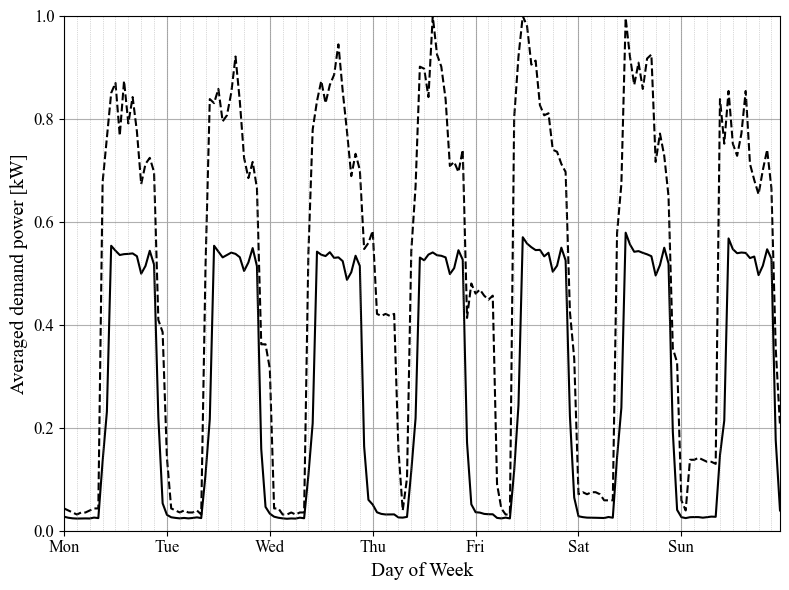

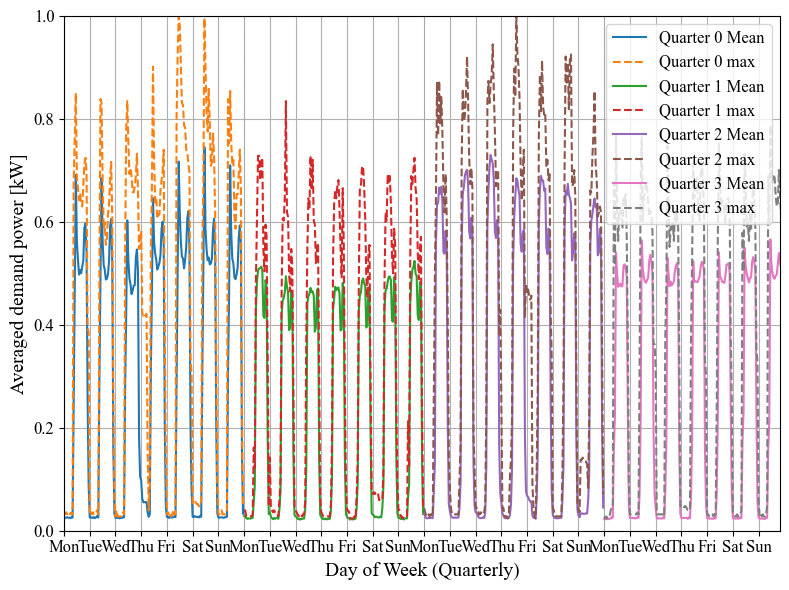

   AnnualCost    PBP  TotalGHG  CPBP  SolarCapacity  EnergyCost  ContractCost  \
1     1600.76   0.00    288.60  0.00           0.00      992.84        513.28   
2     1583.68  16.46    259.59  3.49          62.26      879.09        499.44   
4     1558.40  12.06    235.32  4.09          62.26      922.81        501.07   
5     1459.38   8.74    229.30  3.68          62.26      899.21        391.16   
6     1412.56  11.61    166.19  3.51         192.05      651.71        361.47   

    SSR   SCR  Cost_trvl  Prod_cost  OM_cost  Annual_Prod_cost  GHG_trvl  \
1  0.00  0.00      94.63       0.00     0.00              0.00  35424.54   
2  0.11  0.82      94.63    1587.74    31.13            110.52  35424.54   
4  0.11  0.83       0.00    1812.74    32.63            134.52      0.00   
5  0.13  1.00       0.00    2082.74    40.13            169.02      0.00   
6  0.38  0.93       0.00    5392.16   105.02            399.38      0.00   

   GHG_Comsumption  GHG_Annual_Production  GHG_prod_ev  

In [45]:
# ▼ データ読み込み
df = pd.read_csv(data_path)
print(sum(df['name'].isin(excluded_name)))
df = df[
   ~df['name'].isin(excluded_name)
]
df['CPBP_months'] = df['CPBP'] * 12


# =========================
# 関数定義
# =========================

def get_name_metrics(name,df):
    """指定された name の各シナリオにおける指標値を取得"""
    metrics = {
        s: df[(df['Scinario'] == s) & (df['name'] == name)].iloc[0][[
            'AnnualCost', 'PBP', 'GHG_Total', 'CPBP', 'SolarCapacity',
            'EnergyCost', 'ContractCost', 'SSR[-]', 'SCR[-]', 
            'Cost_trvl', 'Prod_cost', 'OM_cost', 'Annual_Prod_cost',"GHG_trvl","GHG_Comsumption","GHG_Annual_Production","GHG_prod_ev"
        ]] for s in scenarios_to_compare
    }
    df_metrics = pd.DataFrame(metrics).T.rename(columns={
        'GHG_Total': 'TotalGHG',
        'SSR[-]': 'SSR',
        'SCR[-]': 'SCR'
    })
    return df_metrics.apply(pd.to_numeric, errors='coerce').round(2)

#names = ["B11005006", "B11005226"]
names = ["B11005006", "B11002460"]
#demand_name = {"B11005006": "DemandA", "B11005226": "DemandB"}
demand_name = {"B11005006": "DemandA", "B11002460": "DemandB"}

for name in names:
    print(demand_name[name])
    DF = get_name_metrics(name,df)

    process_name(name)
    plot_cost_and_pbp(name, DF, title=f"{name} TAC and PBP")
    plot_ghg_and_cpBP(name, DF, title=f"{name} AGHG and CPBP")

    plot_annual_demand_re(name, 3)
    plot_typical_week_profile(name, 3)
    plot_quarterly_week_profile(name, 3)
    print(DF)

36
DemandA

🔺 Top 3 Peaks for B11005006 - Scenario 1
  1位 Peak @ 2014-07-08 14:00:00 → Total_Power: 268.00 kW | Demand: 268.00 kW | RE: 0.00 kW | EV: 0.00 kW
  2位 Peak @ 2014-07-20 15:00:00 → Total_Power: 268.00 kW | Demand: 268.00 kW | RE: 0.00 kW | EV: 0.00 kW
  3位 Peak @ 2014-07-26 14:00:00 → Total_Power: 266.00 kW | Demand: 266.00 kW | RE: 0.00 kW | EV: 0.00 kW

🔺 Top 3 Peaks for B11005006 - Scenario 2
  1位 Peak @ 2014-09-03 13:00:00 → Total_Power: 229.46 kW | Demand: 248.00 kW | RE: 18.54 kW | EV: 0.00 kW
  2位 Peak @ 2014-07-26 16:00:00 → Total_Power: 224.92 kW | Demand: 262.00 kW | RE: 37.08 kW | EV: 0.00 kW
  3位 Peak @ 2014-01-19 12:00:00 → Total_Power: 222.46 kW | Demand: 241.00 kW | RE: 18.54 kW | EV: 0.00 kW

🔺 Top 3 Peaks for B11005006 - Scenario 4
  1位 Peak @ 2014-09-03 13:00:00 → Total_Power: 230.09 kW | Demand: 248.00 kW | RE: 18.54 kW | EV: 0.63 kW
  2位 Peak @ 2014-07-26 16:00:00 → Total_Power: 225.10 kW | Demand: 262.00 kW | RE: 37.08 kW | EV: 0.18 kW
  3位 Peak @ 2014-0

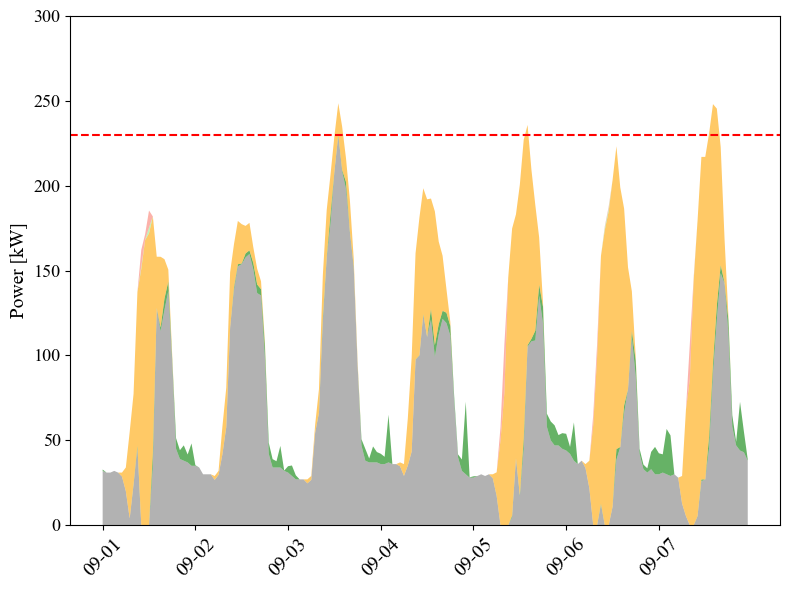

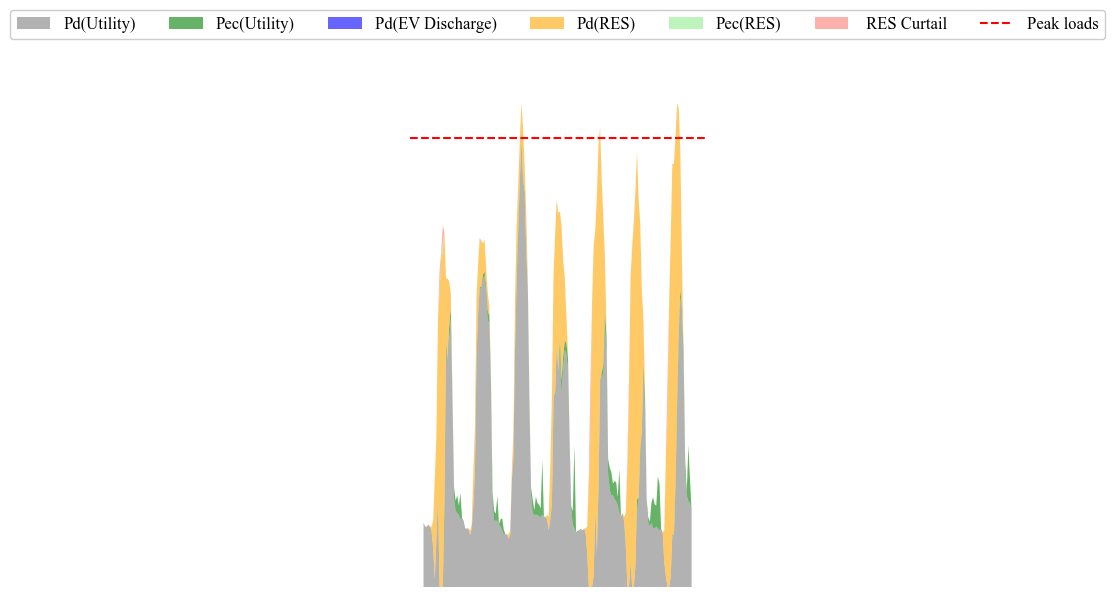

5 6217.746029047903


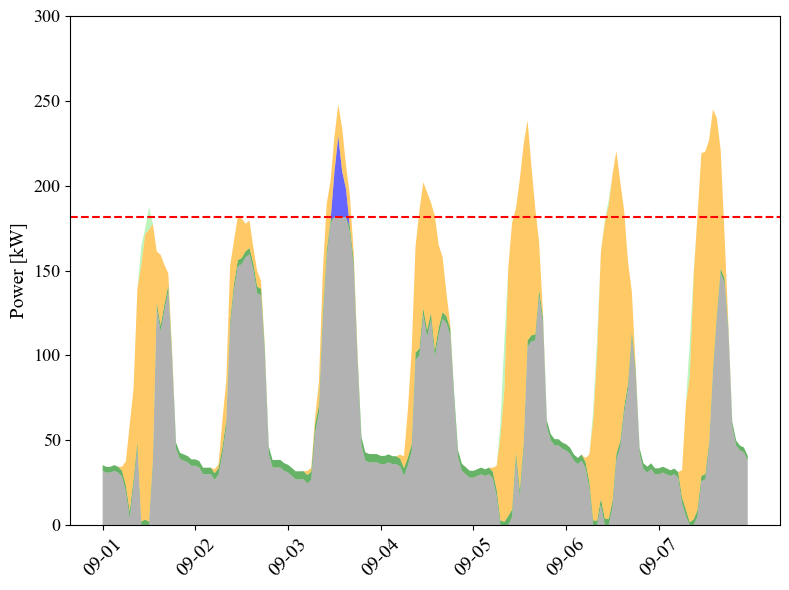

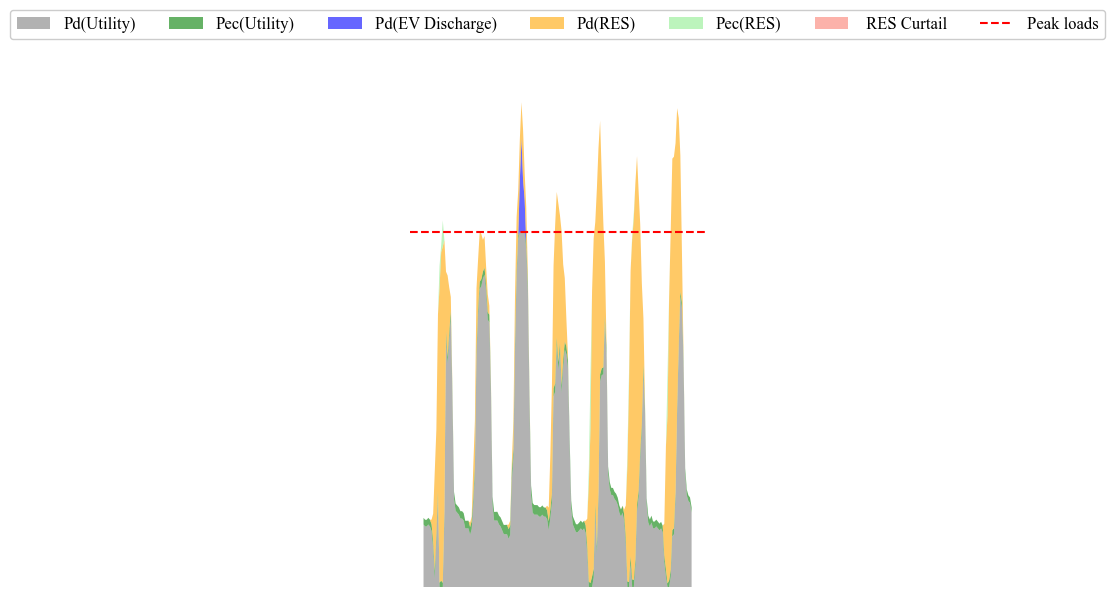

6 8209.179170550678


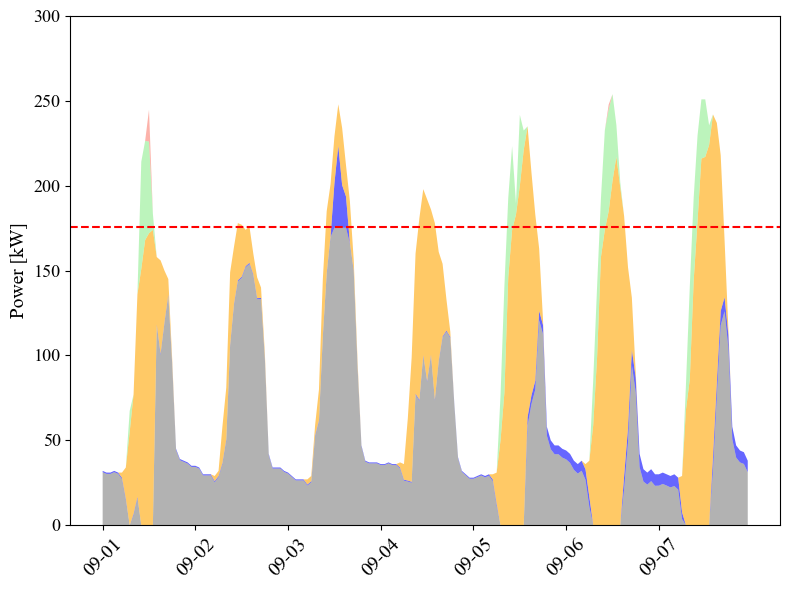

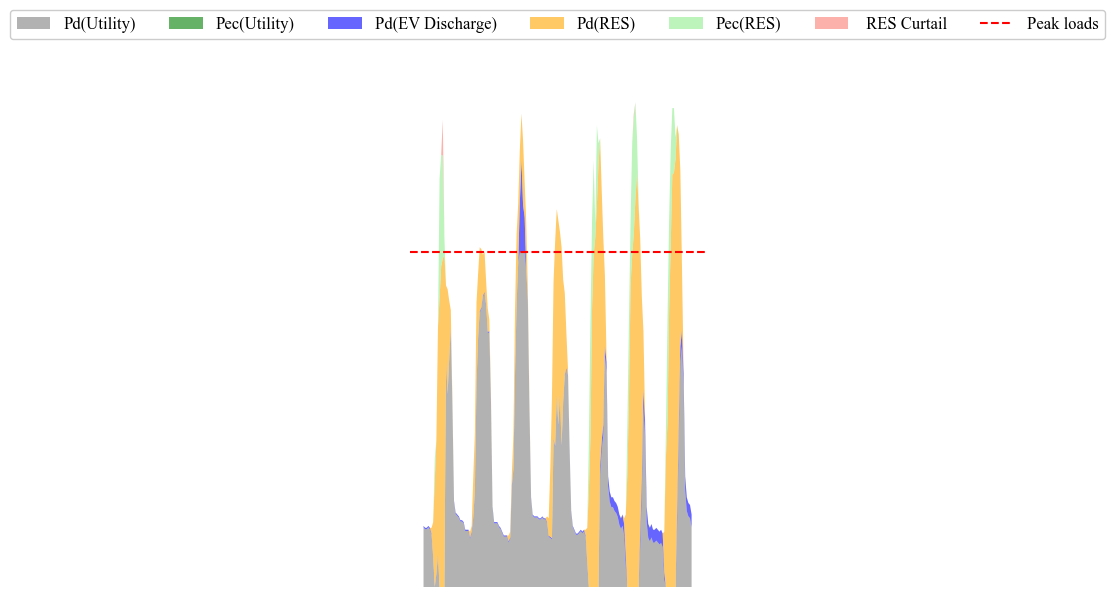

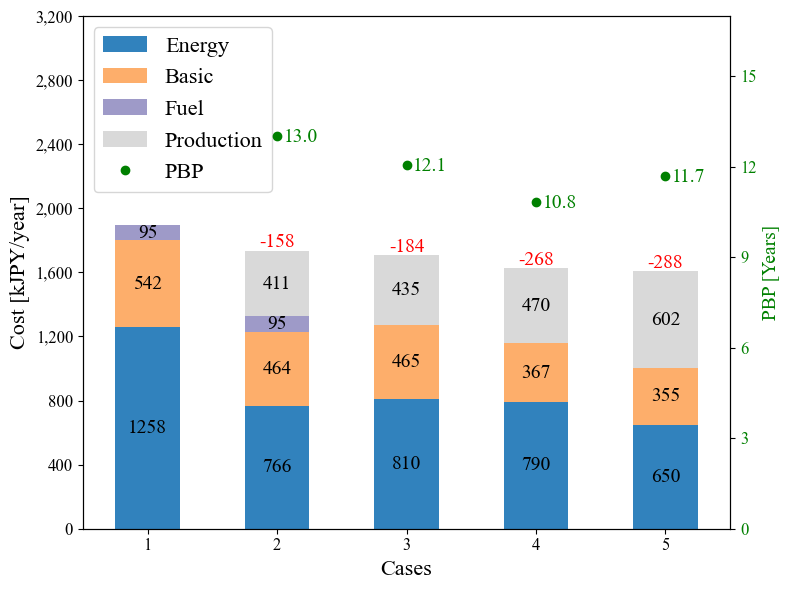

IMG2/B11005006_GHG_CPBP.png


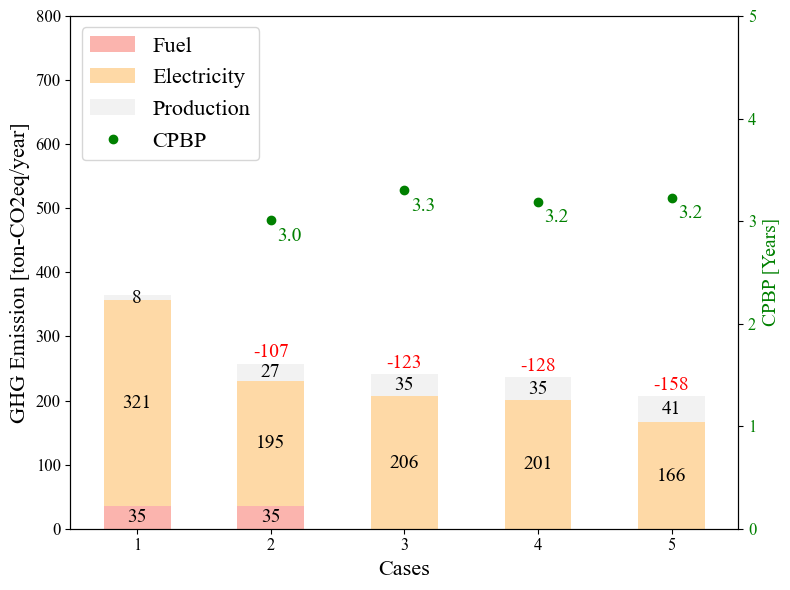

C:\Users\kiuch\AppData\Local\Temp\ipykernel_26552\1435798864.py:372: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  daily_avg = ts.resample('H').mean()


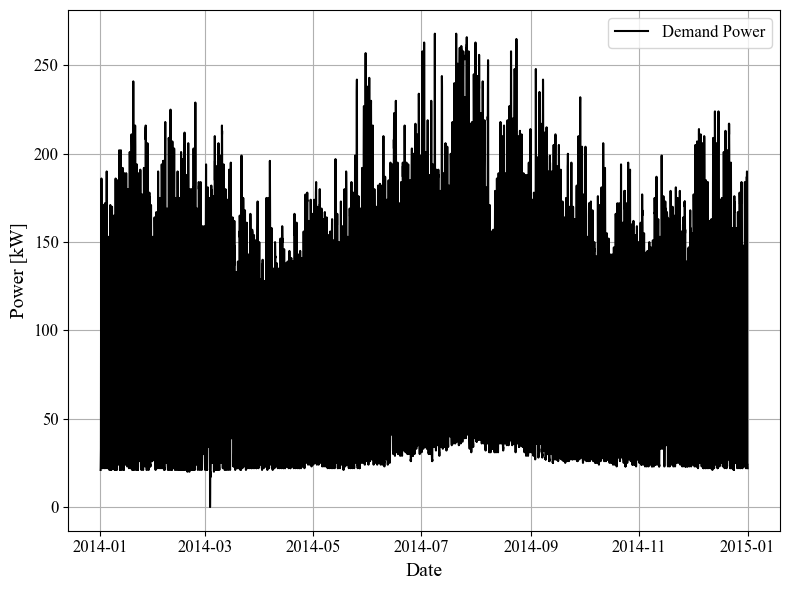

IMG2/B11005006_3_typical_week_demand.png


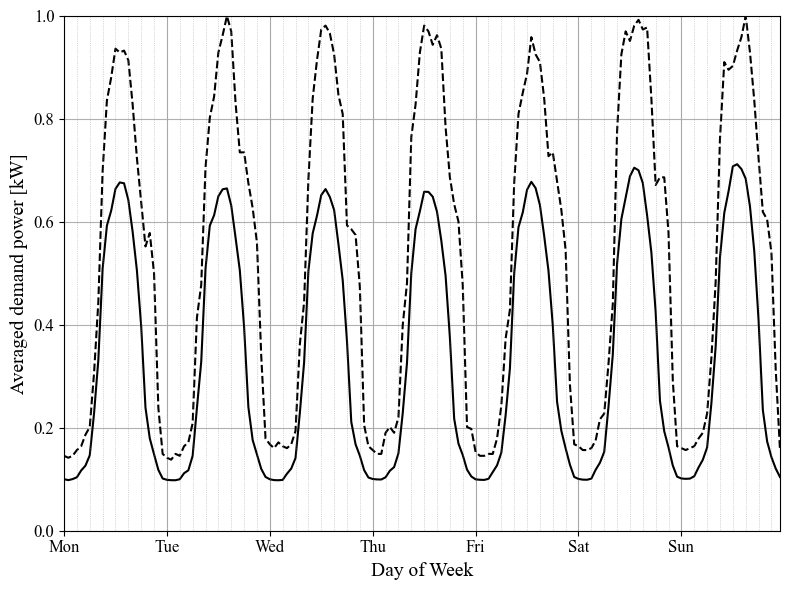

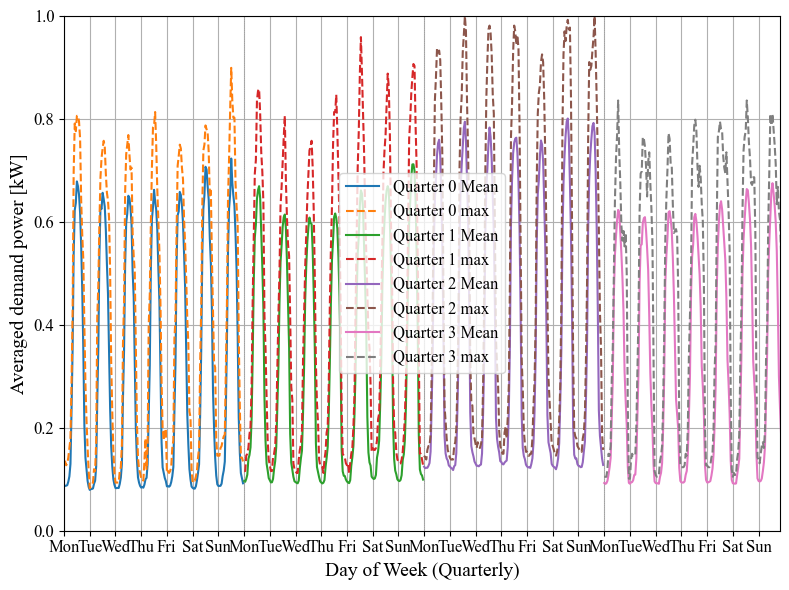

   AnnualCost    PBP  TotalGHG  CPBP  SolarCapacity  EnergyCost  ContractCost  \
1     1894.13   0.00    356.20  0.00           0.00     1257.93        541.57   
2     1735.95  13.03    230.82  3.01         231.75      766.27        463.69   
4     1709.83  12.07    206.43  3.30         231.75      809.52        464.96   
5     1626.19  10.82    201.36  3.19         231.75      789.64        366.70   
6     1606.38  11.69    165.77  3.23         305.97      650.09        354.70   

    SSR   SCR  Cost_trvl  Prod_cost  OM_cost  Annual_Prod_cost  GHG_trvl  \
1  0.00  0.00      94.63       0.00     0.00              0.00  35424.54   
2  0.39  0.95      94.63    5909.52   115.87            411.35  35424.54   
4  0.38  0.96       0.00    6134.52   117.37            435.35      0.00   
5  0.39  1.00       0.00    6404.52   124.87            469.85      0.00   
6  0.50  0.97       0.00    8297.24   161.99            601.60      0.00   

   GHG_Comsumption  GHG_Annual_Production  GHG_prod_ev  

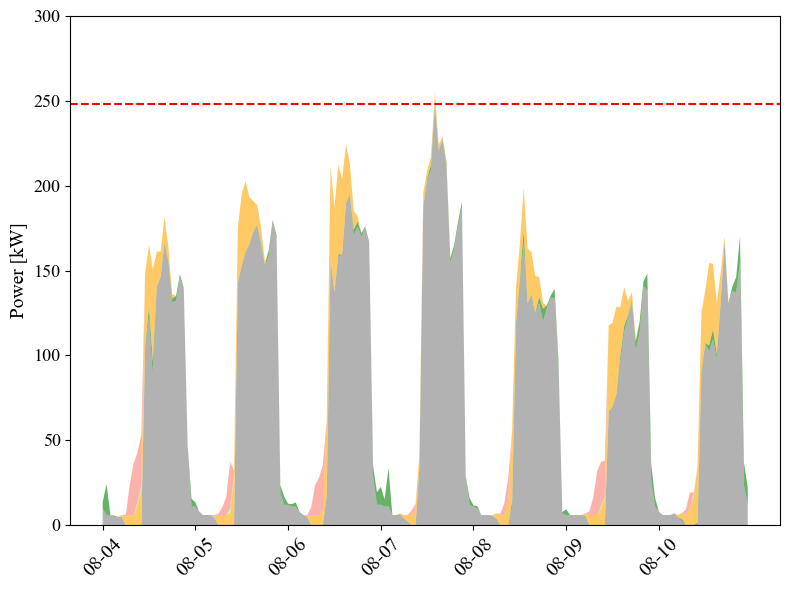

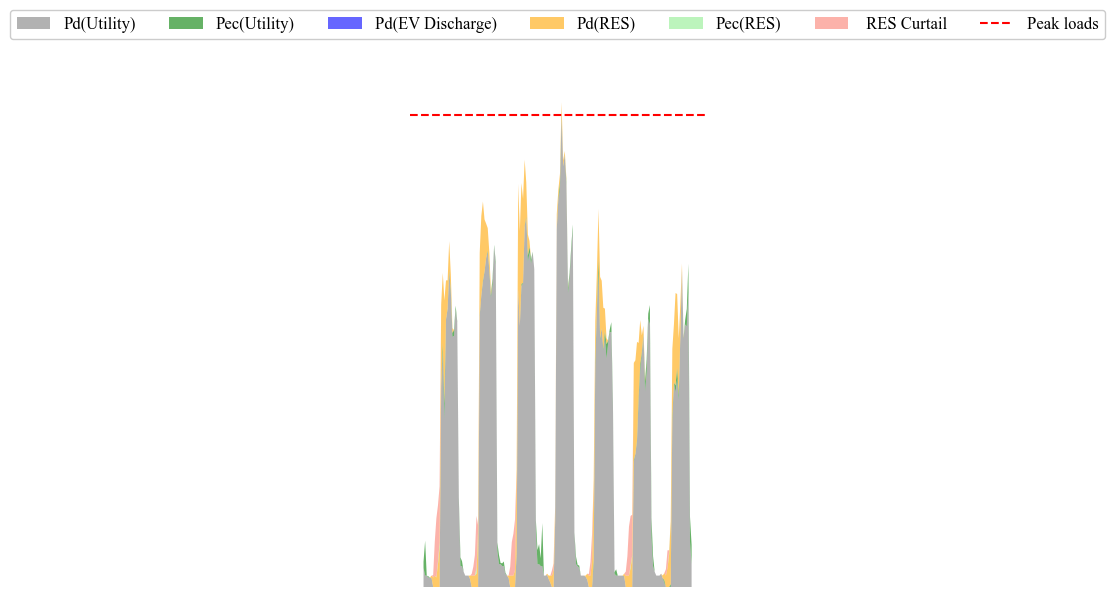

5 2024.8301886569648


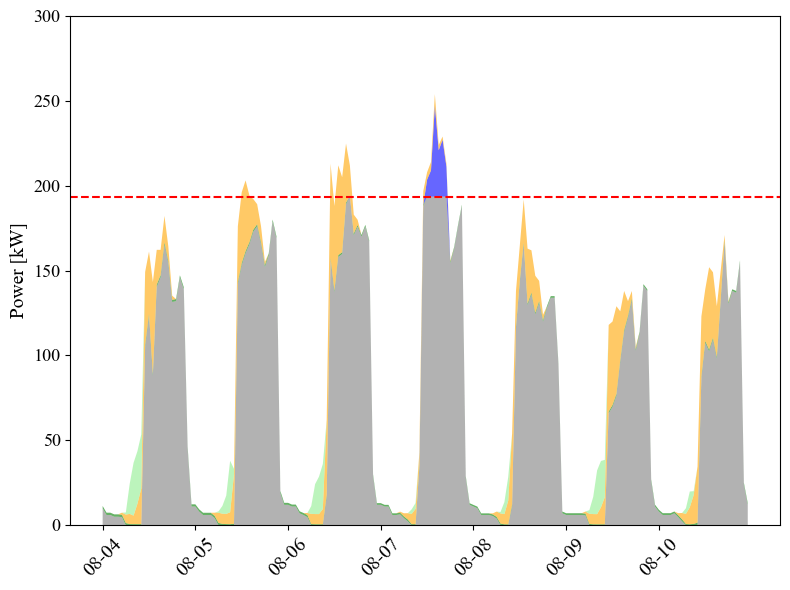

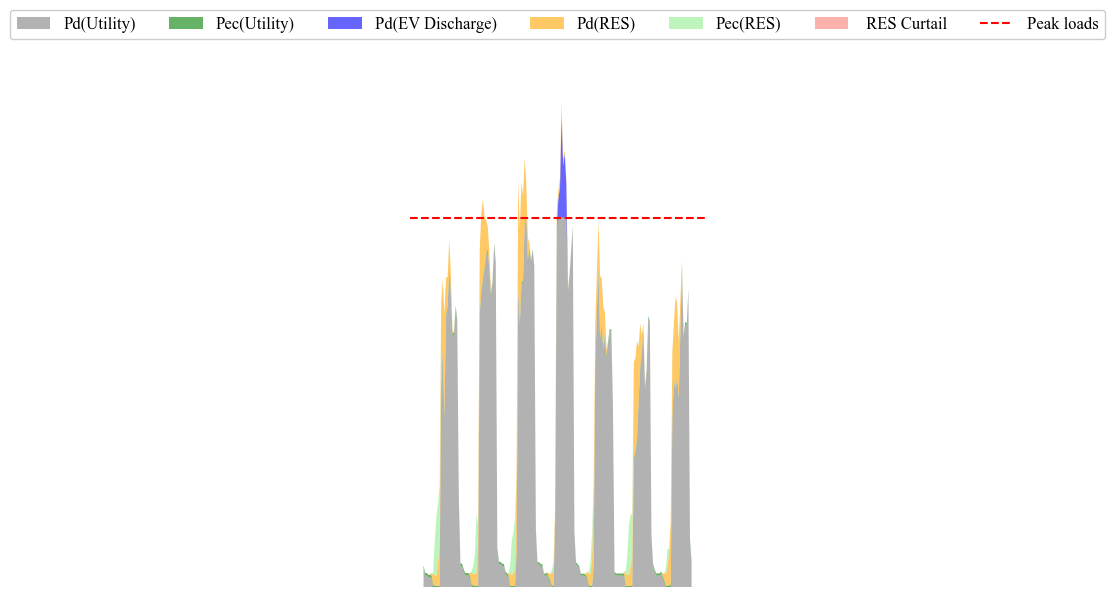

6 6245.318230231591


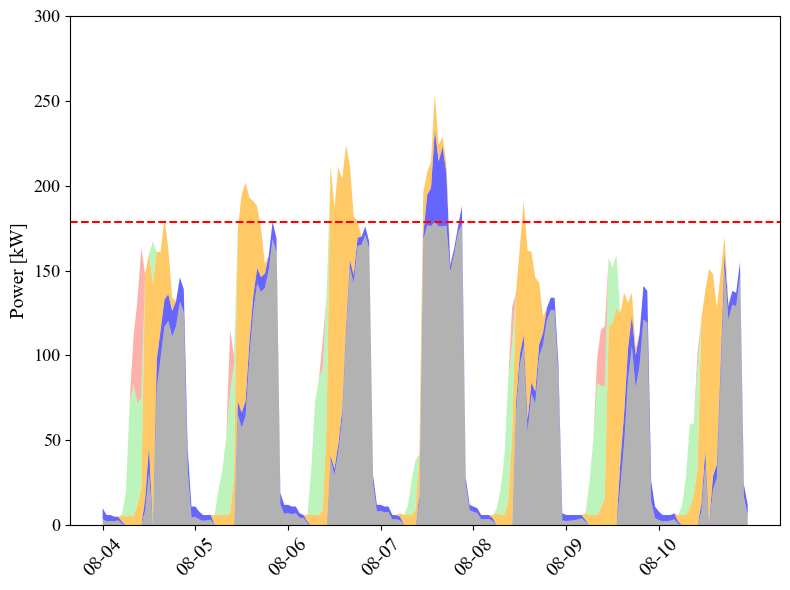

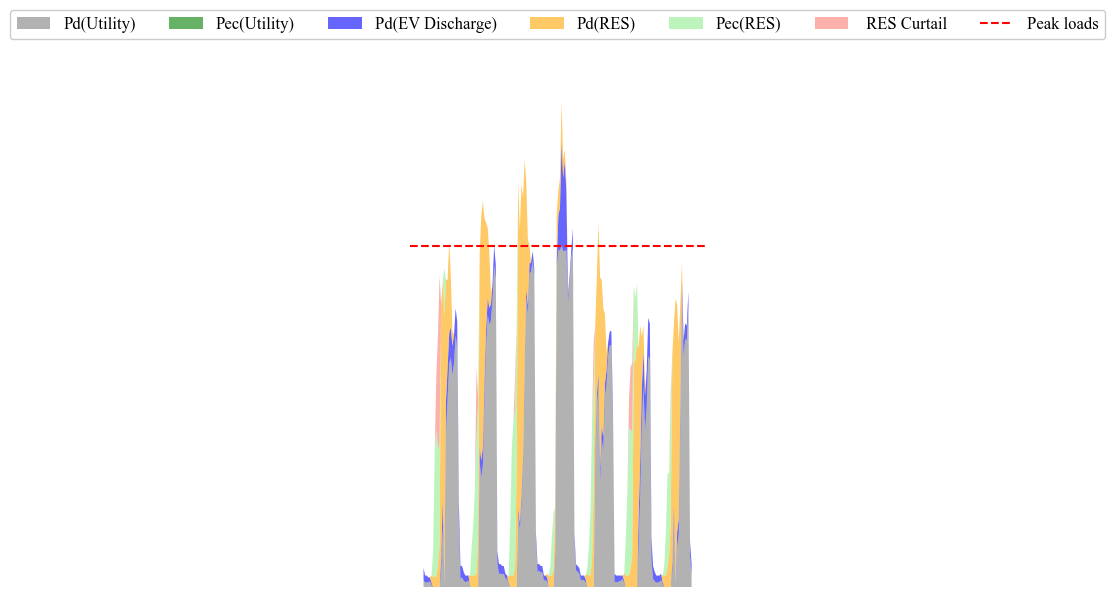

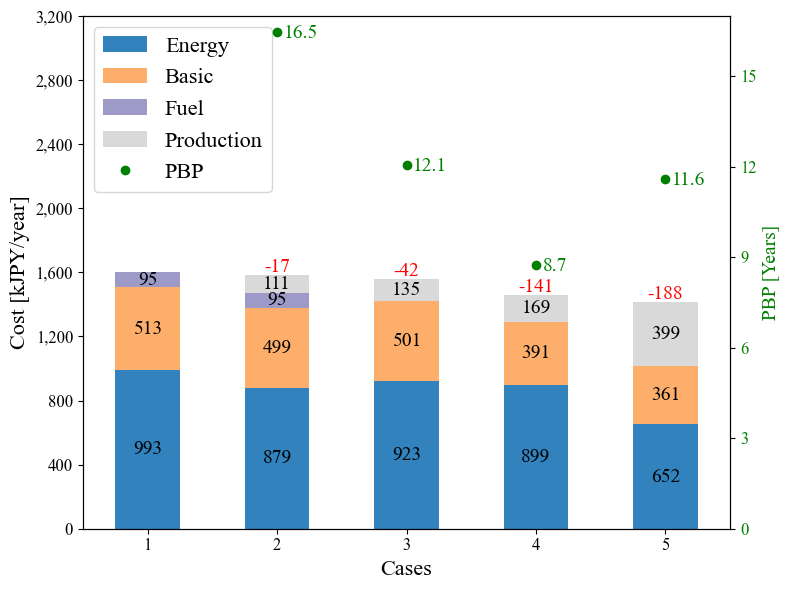

IMG2/B11002460_GHG_CPBP.png


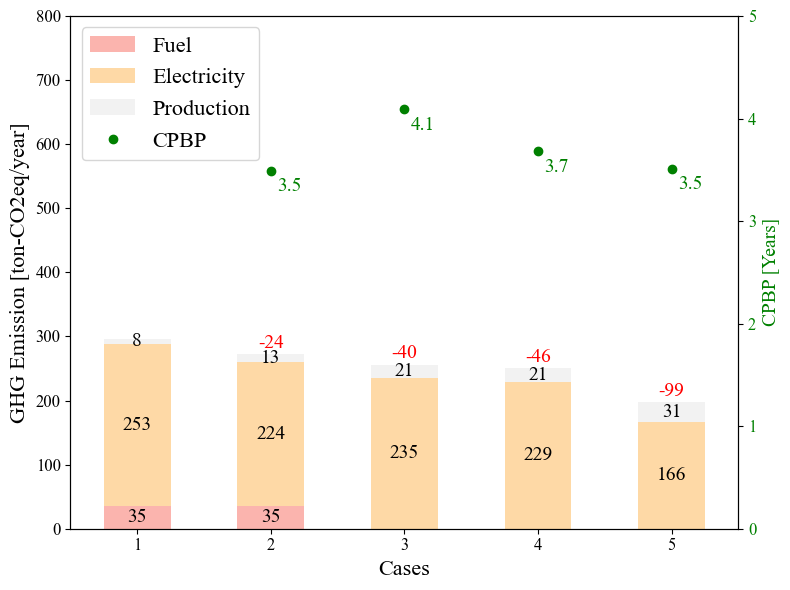

C:\Users\kiuch\AppData\Local\Temp\ipykernel_26552\1435798864.py:372: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  daily_avg = ts.resample('H').mean()


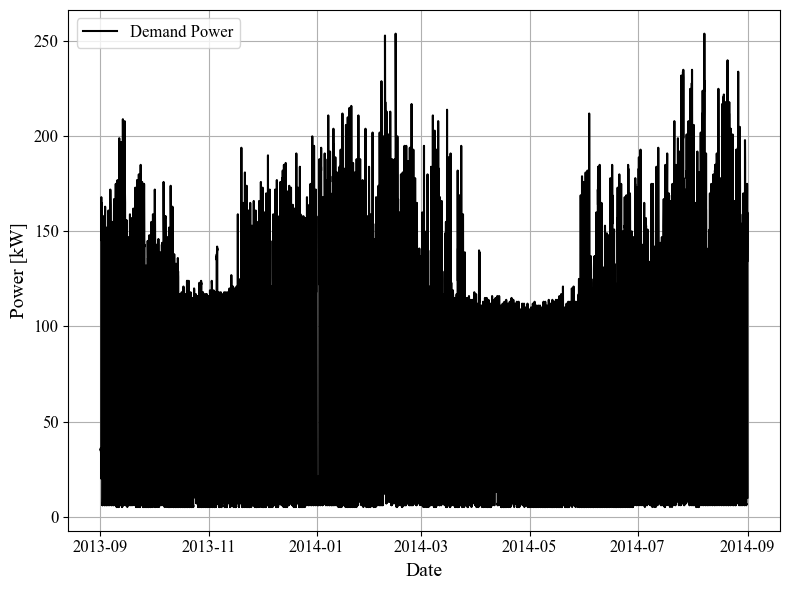

IMG2/B11002460_3_typical_week_demand.png


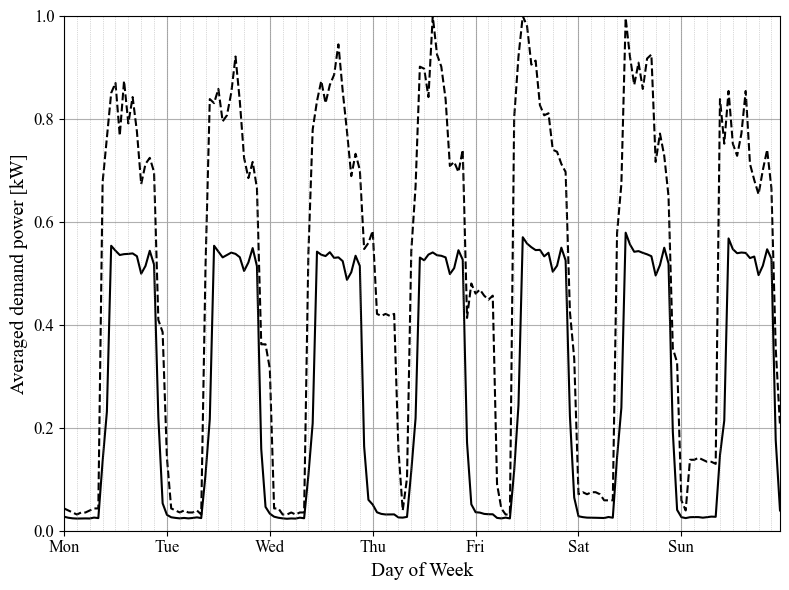

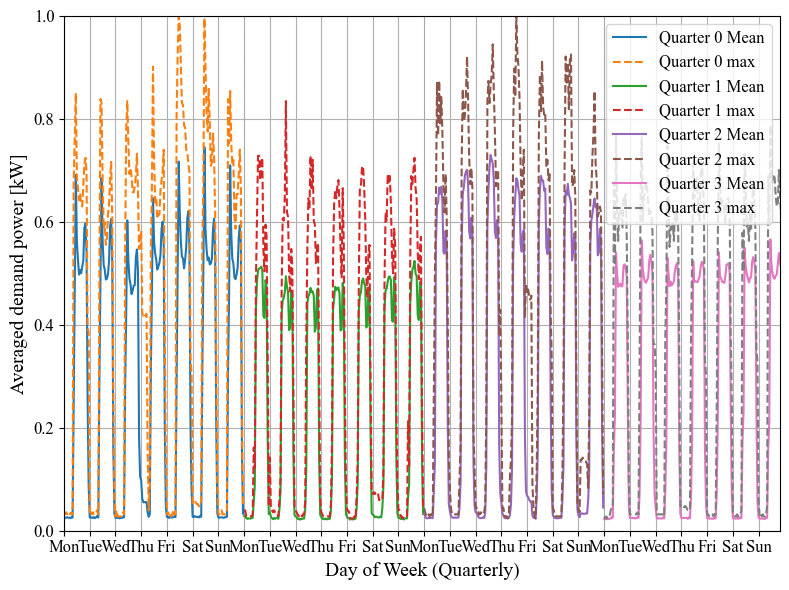

   AnnualCost    PBP  TotalGHG  CPBP  SolarCapacity  EnergyCost  ContractCost  \
1     1600.76   0.00    288.60  0.00           0.00      992.84        513.28   
2     1583.68  16.46    259.59  3.49          62.26      879.09        499.44   
4     1558.40  12.06    235.32  4.09          62.26      922.81        501.07   
5     1459.38   8.74    229.30  3.68          62.26      899.21        391.16   
6     1412.56  11.61    166.19  3.51         192.05      651.71        361.47   

    SSR   SCR  Cost_trvl  Prod_cost  OM_cost  Annual_Prod_cost  GHG_trvl  \
1  0.00  0.00      94.63       0.00     0.00              0.00  35424.54   
2  0.11  0.82      94.63    1587.74    31.13            110.52  35424.54   
4  0.11  0.83       0.00    1812.74    32.63            134.52      0.00   
5  0.13  1.00       0.00    2082.74    40.13            169.02      0.00   
6  0.38  0.93       0.00    5392.16   105.02            399.38      0.00   

   GHG_Comsumption  GHG_Annual_Production  GHG_prod_ev  

In [46]:
# ▼ データ読み込み
df = pd.read_csv(data_path)
print(sum(df['name'].isin(excluded_name)))
df = df[
   ~df['name'].isin(excluded_name)
]
df['CPBP_months'] = df['CPBP'] * 12


# =========================
# 関数定義
# =========================

def get_name_metrics(name,df):
    """指定された name の各シナリオにおける指標値を取得"""
    metrics = {
        s: df[(df['Scinario'] == s) & (df['name'] == name)].iloc[0][[
            'AnnualCost', 'PBP', 'GHG_Total', 'CPBP', 'SolarCapacity',
            'EnergyCost', 'ContractCost', 'SSR[-]', 'SCR[-]', 
            'Cost_trvl', 'Prod_cost', 'OM_cost', 'Annual_Prod_cost',"GHG_trvl","GHG_Comsumption","GHG_Annual_Production","GHG_prod_ev"
        ]] for s in scenarios_to_compare
    }
    df_metrics = pd.DataFrame(metrics).T.rename(columns={
        'GHG_Total': 'TotalGHG',
        'SSR[-]': 'SSR',
        'SCR[-]': 'SCR'
    })
    return df_metrics.apply(pd.to_numeric, errors='coerce').round(2)

#names = ["B11005006", "B11005226"]
names = ["B11005006", "B11002460"]
#demand_name = {"B11005006": "DemandA", "B11005226": "DemandB"}
demand_name = {"B11005006": "DemandA", "B11002460": "DemandB"}

for name in names:
    print(demand_name[name])
    DF = get_name_metrics(name,df)

    process_name(name)
    plot_cost_and_pbp(name, DF, title=f"{name} TAC and PBP")
    plot_ghg_and_cpBP(name, DF, title=f"{name} AGHG and CPBP")

    plot_annual_demand_re(name, 3)
    plot_typical_week_profile(name, 3)
    plot_quarterly_week_profile(name, 3)
    print(DF)

In [47]:
min_change_df = get_name_metrics(min_change_name)

print(f"\n🔍 SolarCapacity変化が最小の name: {min_change_name}")
process_name(min_change_name)
plot_cost_and_pbp(min_change_name, min_change_df, title=f"{min_change_name} TAC and PBP")
plot_ghg_and_cpBP(min_change_name, min_change_df, title=f"{min_change_name} AGHG and CPBP")

plot_annual_demand_re(min_change_name, 3)
plot_typical_week_profile(min_change_name, 3)
plot_quarterly_week_profile(min_change_name, 3)
print(min_change_df)

TypeError: get_name_metrics() missing 1 required positional argument: 'df'

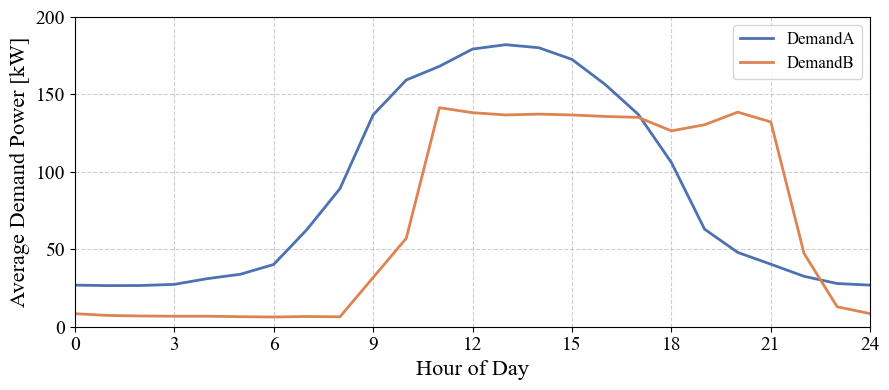

In [48]:
import matplotlib.pyplot as plt
import pandas as pd
import os

#names = ["B11005006", "B11005226"]
names = ["B11005006", "B11002460"]
#demand_name = {"B11005006": "DemandA", "B11005226": "DemandB"}
demand_name = {"B11005006": "DemandA", "B11002460": "DemandB"}
scenario = 1
fig, ax = plt.subplots(figsize=(9, 4))

# 論文調のカラー（少しくっきりめ）
colors = ["#4C72B0", "#DD8452"]

for i, name in enumerate(names):
    file_path = os.path.join(folder_path, f"{name}_{scenario}.csv")

    # ▼ データ読み込み
    ts = pd.read_csv(file_path, index_col=0, parse_dates=True)
    ts.index = pd.to_datetime(ts.index, format='%Y-%m-%d %H:%M:%S', errors='raise')

    # ▼ 時間列追加
    ts['Hour'] = ts.index.hour

    # ▼ Groupby → 平均, 最大, 最小
    agg_df = ts.groupby(['Hour'])['Demand_Power'].agg(['mean', 'max', 'min', "sum"]).reset_index()
    agg_df = agg_df.sort_values('Hour')

    # ▼ 24時（=0時）を追加して周期を閉じる
    first_row = agg_df.iloc[0].copy()
    first_row['Hour'] = 24
    agg_df = pd.concat([agg_df, first_row.to_frame().T], ignore_index=True)

    # ▼ プロット
    ax.plot(agg_df['Hour'], agg_df['mean'],
            label=demand_name[name],
            color=colors[i],
            linewidth=2)

# ▼ 軸・フォントサイズ設定
ax.set_xticks(range(0, 25, 3))
ax.set_xlim(0, 24)
ax.set_ylim(0, 200)
ax.set_xlabel("Hour of Day", fontsize=16)
ax.set_ylabel("Average Demand Power [kW]", fontsize=16)
ax.tick_params(axis='both', labelsize=14)

# ▼ 凡例（透明度なし）
ax.legend(fontsize=12, title_fontsize=16, frameon=True)

# ▼ グリッド
ax.grid(True, linestyle='--', alpha=0.6)

# ▼ 保存・表示
plt.tight_layout()
plt.savefig("IMG/two_demand.png", bbox_inches='tight', dpi=300)
plt.show()


In [ ]:
ts["WeekHour"]=ts.index.weekday*24+ts.index.hour
ts

,Demand_Power,RE_Power,EV_Charge,EV_Energy,BESS_Charge,BESS_Energy,BuyPower,Trip,Hour,WeekHour
2013-09-01 02:00:00,35,0.0,0.0,0.0,0.0,0.0,NaN,0.0,2,146
2013-09-01 03:00:00,35,0.0,0.0,0.0,0.0,0.0,NaN,0.0,3,147
2013-09-01 04:00:00,36,0.0,0.0,0.0,0.0,0.0,NaN,0.0,4,148
2013-09-01 05:00:00,35,0.0,0.0,0.0,0.0,0.0,NaN,0.0,5,149
2013-09-01 06:00:00,34,0.0,0.0,0.0,0.0,0.0,NaN,0.0,6,150
...,...,...,...,...,...,...,...,...,...,...
2014-08-31 20:00:00,160,0.0,0.0,0.0,0.0,0.0,NaN,0.0,20,164
2014-08-31 21:00:00,129,0.0,0.0,0.0,0.0,0.0,NaN,0.0,21,165
2014-08-31 22:00:00,70,0.0,0.0,0.0,0.0,0.0,NaN,0.0,22,166
2014-08-31 23:00:00,18,0.0,0.0,0.0,0.0,0.0,NaN,0.0,23,167


In [ ]:
agg_week = ts.groupby(['WeekHour'])['Demand_Power'].agg(['mean', 'max', 'min']).reset_index()
agg_week = agg_week.sort_values('WeekHour')

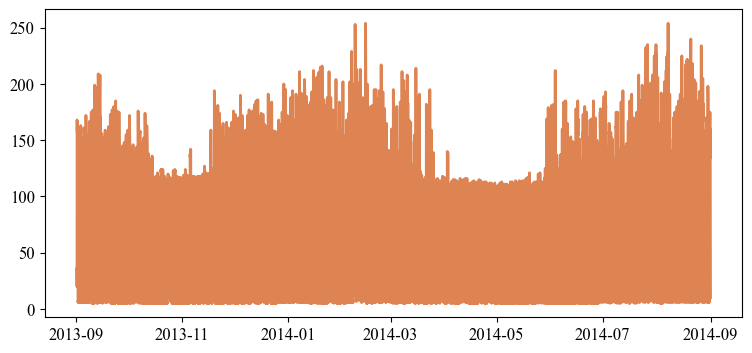

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ts.index, ts['Demand_Power'],
            label=demand_name[name],
            color=colors[i],
            linewidth=2)


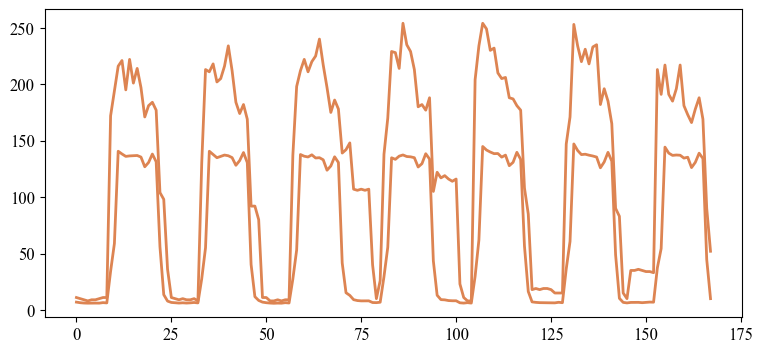

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(agg_week['WeekHour'], agg_week['mean'],
            label=demand_name[name],
            color=colors[i],
            linewidth=2)
ax.plot(agg_week['WeekHour'], agg_week['max'],
            label=demand_name[name],
            color=colors[i],
            linewidth=2)

⚠️ PV容量が減少したケースはありません

📊 base_load（月別最小の平均）と SolarCapacity変化の相関: -0.450


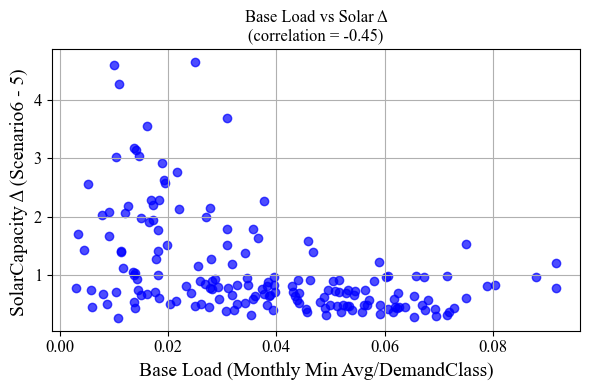


⏰ peak_hour（0–23）と SolarCapacity変化の相関: 0.103


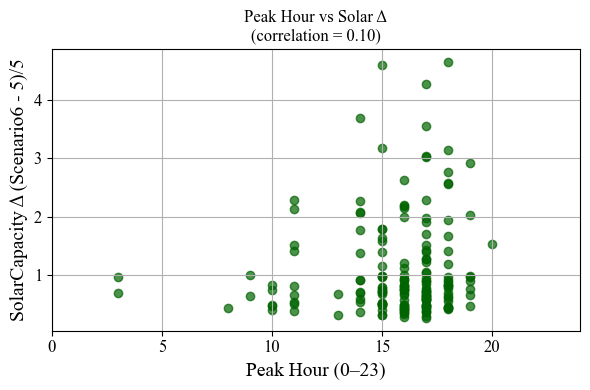

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv(data_path)

# ========== パラメータ ==========
folder_path = "EnergyManagement_Output_15"

# ========== データフィルタリング ==========
# ピーク時刻が一致する name 抽出
peak_pivot = peak_df_[peak_df_["scenario"].isin([4, 6])].pivot(index="name", columns="scenario", values="peak_time")
matching_peak_names = peak_pivot[peak_pivot[4] == peak_pivot[6]].index.tolist()

# 条件に合う name のみ抽出
df = df[df["name"].isin(matching_peak_names)]
#df = df[df["DemandClass"] == 300]

# ========== SolarCapacity 変化量の計算 ==========
df_5_6 = df[df['Scinario'].isin([5, 6])]
delta_df = df_5_6.pivot_table(index='name', columns='Scinario', values='SolarCapacity')
delta_df['delta'] = (delta_df[6] - delta_df[5]) /delta_df[5]
demand_class_map = df.drop_duplicates('name').set_index('name')['DemandClass']
delta_df['DemandClass'] = delta_df.index.map(demand_class_map)

if delta_df['delta'].min() > 0:
    print("⚠️ PV容量が減少したケースはありません")

# ========== base_load 抽出関数 ==========
def get_base_load_from_file(name, scenario, folder_path):
    file_path = os.path.join(folder_path, f"{name}_{scenario}.csv")
    if not os.path.exists(file_path):
        print(f"⚠️ ファイルが見つかりません: {file_path}")
        return None
    ts = pd.read_csv(file_path, index_col=0, parse_dates=True)
    ts.index = pd.to_datetime(ts.index, format='%Y-%m-%d %H:%M:%S', errors='raise')
    if 'Demand_Power' not in ts.columns:
        print(f"⚠️ Demand_Power 列がありません: {file_path}")
        return None
    return ts['Demand_Power'].resample("ME").min().mean()

def get_peak_hour_series(peak_df_, scenario=6):
    """
    指定されたシナリオのピーク時刻から hour（0–23）を抽出し、name を index にした Series を返す

    Parameters:
        peak_df_ (DataFrame): 全ピーク情報を含む DataFrame（列: name, scenario, peak_time）
        scenario (int): 対象とするシナリオ（例: 6）

    Returns:
        Series: index=name, values=hour（0〜23）
    """
    peak_hour_series = peak_df_[peak_df_["scenario"] == scenario].set_index("name")["peak_time"]
    peak_hour_series = pd.to_datetime(peak_hour_series, errors='coerce').dt.hour
    peak_hour_series.name = 'peak_hour'
    return peak_hour_series


# ========== base_load を計算して delta_df に追加 ==========
base_load_dict = {}
for name in delta_df.index:
    base = get_base_load_from_file(name, scenario=3, folder_path=folder_path)
    if base is not None:
        base_load_dict[name] = base

delta_df['base_load'] = pd.Series(base_load_dict)/delta_df["DemandClass"]

# ========== 相関分析 ==========
corr = delta_df[['delta', 'base_load']].corr().iloc[0, 1]
print(f"\n📊 base_load（月別最小の平均）と SolarCapacity変化の相関: {corr:.3f}")

# ========== 可視化 ==========
plt.figure(figsize=(6, 4))
plt.scatter(delta_df['base_load'], delta_df['delta'], alpha=0.7, color='blue')
plt.xlabel("Base Load (Monthly Min Avg/DemandClass)")
plt.ylabel("SolarCapacity Δ (Scenario6 - 5) ")
plt.title(f"Base Load vs Solar Δ\n(correlation = {corr:.2f})")
plt.grid(True)
plt.tight_layout()
plt.savefig("IMG/base_vs_solar_delta.png", bbox_inches="tight")
plt.show()

# ピーク時刻（hour）の Series を取得して delta_df に追加
delta_df['peak_hour'] = get_peak_hour_series(peak_df_, scenario=4)

# 欠損除外（念のため）
delta_df = delta_df.dropna(subset=['peak_hour'])

# 相関
corr_peak_hour = delta_df[['delta', 'peak_hour']].corr().iloc[0, 1]
print(f"\n⏰ peak_hour（0–23）と SolarCapacity変化の相関: {corr_peak_hour:.3f}")

# プロット
plt.figure(figsize=(6, 4))
plt.scatter(delta_df['peak_hour'], delta_df['delta'], alpha=0.7, color='darkgreen')
plt.xlim(0, 24) 
plt.xlabel("Peak Hour (0–23)")
plt.ylabel("SolarCapacity Δ (Scenario6 - 5)/5")
plt.title(f"Peak Hour vs Solar Δ\n(correlation = {corr_peak_hour:.2f})")
plt.grid(True)
plt.tight_layout()
plt.savefig("IMG/peak_hour_vs_solar_delta.png", bbox_inches="tight")
plt.show()


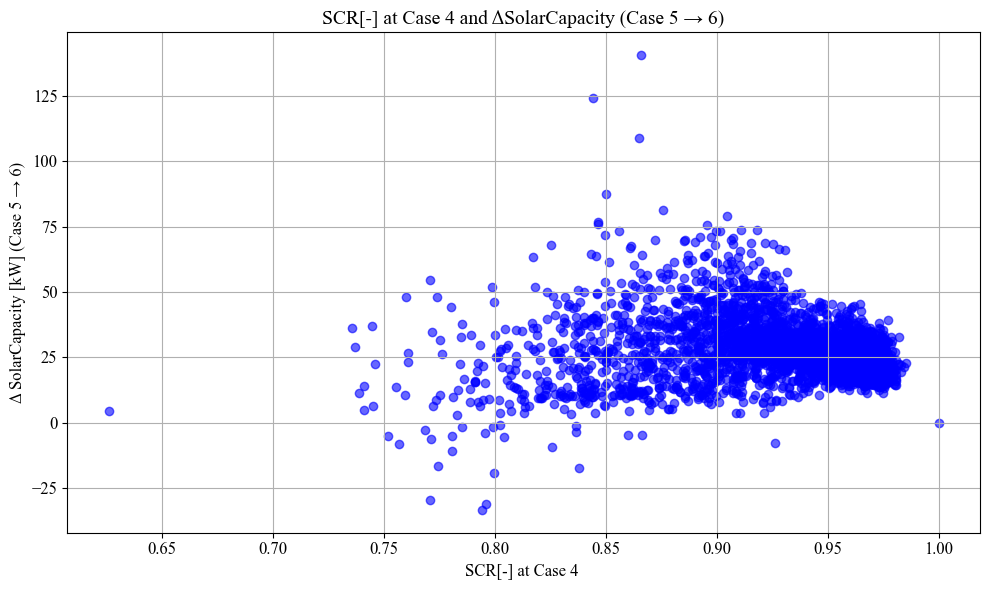

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# データ読み込み
df = pd.read_csv("TEEA_EV5.csv")

# シナリオ4, 5, 6のデータを抽出
df_scenario_4_5_6 = df[df['Scinario'].isin([4, 5, 6])]

# シナリオ4のSCR[-]とシナリオ5と6のSolarCapacityの変化量を計算
df_scenario_4_5_6_pivot = df_scenario_4_5_6.pivot_table(index='name', columns='Scinario', values='SolarCapacity')

# 変化量の計算 (シナリオ5からシナリオ6への変化量)
df_scenario_4_5_6_pivot['change_in_solar_capacity'] = df_scenario_4_5_6_pivot[6] - df_scenario_4_5_6_pivot[5]

# シナリオ4のSCR[-]を取得
df_scr = df_scenario_4_5_6[df_scenario_4_5_6['Scinario'] == 4].set_index('name')['SCR[-]']

# SCR[-]とSolarCapacityの変化量の関係を結合
df_scenario_4_5_6_pivot['SCR[-]'] = df_scr

# グラフ化
plt.figure(figsize=(10, 6))
plt.scatter(df_scenario_4_5_6_pivot['SCR[-]'], df_scenario_4_5_6_pivot['change_in_solar_capacity'], color='blue', alpha=0.6)
plt.title('SCR[-] at Case 4 and ΔSolarCapacity (Case 5 → 6)', fontsize=14)
plt.xlabel('SCR[-] at Case 4 ', fontsize=12)
plt.ylabel('Δ SolarCapacity [kW] (Case 5 → 6)', fontsize=12)
plt.grid(True)
plt.tight_layout()

# グラフの表示
plt.show()


C:\Users\kiuch\AppData\Local\Temp\ipykernel_46868\4277764586.py:35: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from current font.
  plt.tight_layout()
C:\Users\kiuch\AppData\Local\Temp\ipykernel_46868\4277764586.py:35: UserWarning: Glyph 22793 (\N{CJK UNIFIED IDEOGRAPH-5909}) missing from current font.
  plt.tight_layout()
C:\Users\kiuch\AppData\Local\Temp\ipykernel_46868\4277764586.py:35: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from current font.
  plt.tight_layout()
C:\Users\kiuch\AppData\Local\Temp\ipykernel_46868\4277764586.py:35: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from current font.
  plt.tight_layout()
C:\Users\kiuch\AppData\Local\Temp\ipykernel_46868\4277764586.py:35: UserWarning: Glyph 12471 (\N{KATAKANA LETTER SI}) missing from current font.
  plt.tight_layout()
C:\Users\kiuch\AppData\Local\Temp\ipykernel_46868\4277764586.py:35: UserWarning: Glyph 12490 (\N{KATAKANA LETTER NA}) missing from current font.
 

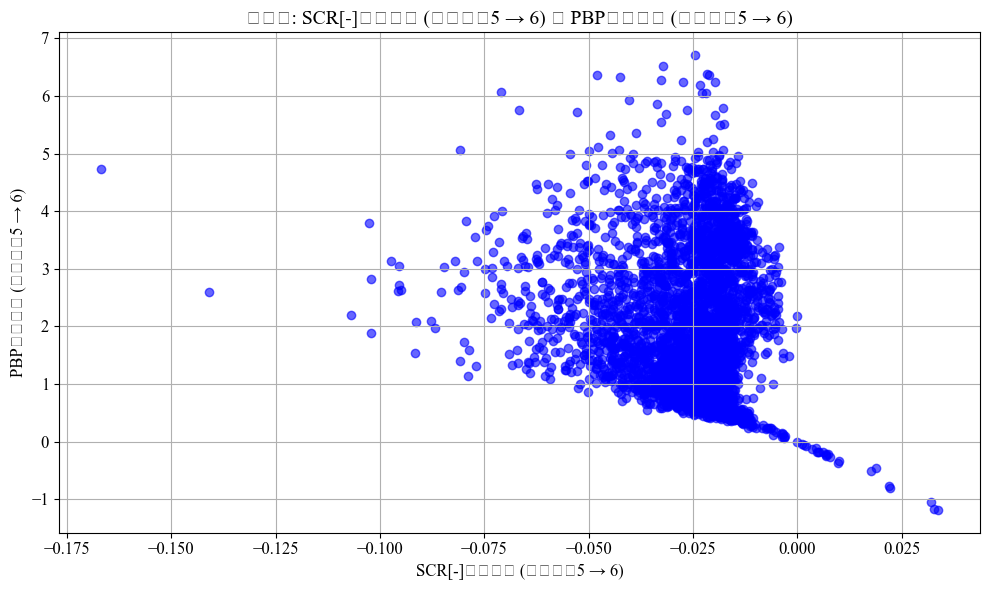

In [ ]:


import pandas as pd
import matplotlib.pyplot as plt

# データ読み込み
df = pd.read_csv("TEEA_EV5.csv")

# シナリオ4, 5, 6のデータを抽出
df_scenario_4_5_6 = df[df['Scinario'].isin([4, 5, 6])]

# SCR[-]がシナリオ5でマイナスのものを除外
df_scenario_4_5_6 = df_scenario_4_5_6[df_scenario_4_5_6['SCR[-]'] >= 0]

# シナリオ5とシナリオ6のSCRの変化量を計算
df_scenario_4_5_6_pivot = df_scenario_4_5_6.pivot_table(index='name', columns='Scinario', values='SCR[-]')

# 変化量の計算 (シナリオ5からシナリオ6へのSCRの変化量)
df_scenario_4_5_6_pivot['change_in_scr'] = df_scenario_4_5_6_pivot[6] - df_scenario_4_5_6_pivot[5]

# シナリオ5とシナリオ6のPBPの変化量を計算
df_scenario_4_5_6_pivot['change_in_pbp'] = df_scenario_4_5_6.pivot_table(index='name', columns='Scinario', values='PBP')[6] - df_scenario_4_5_6.pivot_table(index='name', columns='Scinario', values='PBP')[5]

# シナリオ5のPBPを取得
df_pbp_scenario_5 = df_scenario_4_5_6[df_scenario_4_5_6['Scinario'] == 5].set_index('name')['PBP']

# PBPの変化量とSCR[-]の変化量を結合
df_scenario_4_5_6_pivot['PBP'] = df_pbp_scenario_5

# グラフ化
plt.figure(figsize=(10, 6))
plt.scatter(df_scenario_4_5_6_pivot['change_in_scr'], df_scenario_4_5_6_pivot['change_in_pbp'], color='blue', alpha=0.6)
plt.title('関係性: SCR[-]の変化量 (シナリオ5 → 6) と PBPの変化量 (シナリオ5 → 6)', fontsize=14)
plt.xlabel('SCR[-]の変化量 (シナリオ5 → 6)', fontsize=12)
plt.ylabel('PBPの変化量 (シナリオ5 → 6)', fontsize=12)
plt.grid(True)
plt.tight_layout()

# グラフの表示
plt.show()


In [ ]:
df_scenario_4_5_6_pivot

Scinario,4,5,6,change_in_scr,change_in_pbp,PBP
name,,,,,,
B11000005,0.956960,0.994704,0.971368,-0.023336,0.796162,14.862844
B11000008,0.972093,0.996120,0.976173,-0.019946,0.644112,14.443259
B11000010,0.973000,0.996055,0.977652,-0.018403,0.553619,14.916886
B11000012,0.894544,0.999869,0.942519,-0.057350,3.685923,13.058798
B11000021,0.905328,0.978257,0.927389,-0.050868,1.432805,15.225152
...,...,...,...,...,...,...
B11006523,0.908762,1.000000,0.980727,-0.019273,2.677437,12.120709
B11006524,0.955309,0.992821,0.969868,-0.022953,0.741469,14.702014
B11006530,0.975169,0.994537,0.979404,-0.015134,0.384488,16.143803


In [ ]:
import pandas as pd

# データ読み込み
df = pd.read_csv("TEEA_EV5.csv")

# シナリオ4, 5, 6のデータを抽出
df_scenario_4_5_6 = df[df['Scinario'].isin([4, 5, 6])]

# SCR[-]がシナリオ5でマイナスのものを除外
df_scenario_4_5_6 = df_scenario_4_5_6[df_scenario_4_5_6['SCR[-]'] >= 0]

# シナリオ5とシナリオ6のSolarCapacityとSCR[-]の変化量を計算
df_scenario_4_5_6_pivot = df_scenario_4_5_6.pivot_table(index='name', columns='Scinario', values=['SCR[-]', 'SolarCapacity'])

# SolarCapacityの変化量を計算 (シナリオ6 - シナリオ5)
df_scenario_4_5_6_pivot['change_in_solar_capacity'] = df_scenario_4_5_6_pivot[('SolarCapacity', 6)] - df_scenario_4_5_6_pivot[('SolarCapacity', 5)]

# SCR[-]の変化量を計算 (シナリオ6 - シナリオ5)
df_scenario_4_5_6_pivot['change_in_scr'] = df_scenario_4_5_6_pivot[('SCR[-]', 6)] - df_scenario_4_5_6_pivot[('SCR[-]', 5)]

# SolarCapacityが増加し、SCR[-]も増加したNameを抽出
df_filtered = df_scenario_4_5_6_pivot[
    (df_scenario_4_5_6_pivot['change_in_solar_capacity'] > 0) & 
    (df_scenario_4_5_6_pivot['change_in_scr'] > 0)
]

# 結果の表示
print(df_filtered)


Empty DataFrame
Columns: [(SCR[-], 4), (SCR[-], 5), (SCR[-], 6), (SolarCapacity, 4), (SolarCapacity, 5), (SolarCapacity, 6), (change_in_solar_capacity, ), (change_in_scr, )]
Index: []
